Considere uma cadeia circular (primeira massa liga a última) composta por N átomos conectados por molas idênticas de constante elástica. O sistema pode ser de dois tipos:
• Cadeia Aleatória: Cada átomo possui uma massa mi escolhida aleatoriamente entre m e 5m , com  assumindo apenas valores inteiros (mi=m, 2m, 3m, 4m e 5m).
• Cadeia Homogênea: Todas as massas são iguais a m

Parâmetros
- Massa base:  m = 1kg
- Constante elástica: k=1 N/m
- Tamanhos da cadeia: 100, 1000 e 10.000

1. Cálculo das Frequências de Vibração
- Para cada valor de N, calcule as frequências naturais de vibração para:
- Cadeia com massas aleatórias (cada mi sorteado entre m e 5m )
- Cadeia homogênea (todas as massas )
- Considere sempre as pontas livres (não vale)

2. Densidade de Estados
• Construa histogramas (densidade de estados) para os valores de frequência em cada caso.
• Compare os histogramas entre a cadeia aleatória e a homogênea, para cada tamanho de N 

NOTA: Considere o git do dia 18/07/2025, o professor não havia avisado que iria extender a entrega, por isso, entrguei antes.

# Introdução

Neste trabalho, desejamos compreender o comportamento de um sistema de massas acoplados por molas (sistema massa-mola) com muitos corpos, para isso, vamos utilizar o sistema de equações diferenciais 

$$m_i \ddot{x}_i = -k\left(x_{i}-x_{i-1} \right) +k \left(x_{i+1} - x_{i}\right) \, ,$$

onde $m_i$ é a massa do $i$-ésimo corpo, $x_{i}$ é a posição relativa do $i$-ésimo corpo e $k$ é a constante elástica das molas, os pontos indicam a derivada com relação ao tempo. Nosso sistema será circular. Para tal modelo, suponha que o sistema tem $N$ corpos e assim,

$$m_i \ddot{x}_{i} =-kx_{\left[i-1\right]}+ 2k x_{\left[i\right]} +k x_{\left[i+1\right]} \, ,$$

onde $\left[\cdot\right]$ representa a classe de equivalências das congruências modulo $N$, ou seja

$$ i \in \left[k\right] \iff i \equiv k \; \text{mod}(N) \iff N|i-k \; .$$

Repare que com isso, durante o programa $-1 \equiv N-1 \; \text{mod}(N)$ e $N+1 \equiv 1 \; \text{mod}(N)$ assim, a matriz que representa a dinâmica do problema será descrita por,

$$ \mathcal{D} = 
\left[ \begin{matrix} 

\frac{2k}{m_1} & \frac{-k}{m_1} & 0 & 0 & 0 & \dots & \frac{-k}{m_1} \\[3pt]
\frac{-k}{m_2} & \frac{2k}{m_2} & \frac{-k}{m_1} & 0 & 0 &\dots & 0 \\[3pt]
0 & \frac{-k}{m_3} & \frac{2k}{m_3} & \frac{-k}{m_3} & 0 & \dots & 0 \\[3pt]
 \vdots  &   \vdots & \vdots  & \vdots   & \ddots &  \vdots  & \vdots    \\[3pt]
\frac{-k}{m_N} & 0 & 0 & 0 & \dots  &  \frac{-k}{m_N} & \frac{2k}{m_N} \\[3pt]

\end{matrix} \right]\, .$$

E nosso sistema será reduzido ao seguinte problema de valor inícial,

$$ \ddot{\mathbf{x}} = \mathcal{D} \mathbf{x} \, .$$ 

Tal sistema, para $N$ muito grande deve simular o comportamento de uma onda. Tal comportamento será observado com uma coletividade entre as partículas.

Se todas as massas forem escolhidas aleatóriamente o vetor $\mathbf{m} = \left(m_1,m_2,m_3,...,m_N\right)$, tal que, $m_i \in \left\{1,2,3,4,5\right\}$. Nessa configuração espara-se observar um comportamento singular das partículas sem a presença de ondas.

# Metodologia

Para resolver o sistema massa-mola de muitas partículas, as equações de movimento serão substituídas por uma equação de autovalores, com a seguinte transformação:

$$ x(t) = C_1 \cos (\omega t) + C_2 \sin(\omega t) $$

Com isso, as equações do problema massa-mola serão dadas da seguinte maneira,

$$ -k x_{n-1} + k x_{n+1} - \omega^2 x_{n} = 0 $$

Para solucionar tal sistema de equações será escrito uma matriz dinâmica. E assim, será solucionado o problema de autovalores $\omega^2$ com a função "eng" da biblioteca numpy. Após isso, uma análise da distribuíção de frequências e das frequencias principais são as de menor energia.

# Resultados e Discussão

![Fluxoautovalores](ATV5valores.png)

<>:80: SyntaxWarning: invalid escape sequence '\o'
<>:80: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\4194276381.py:80: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)


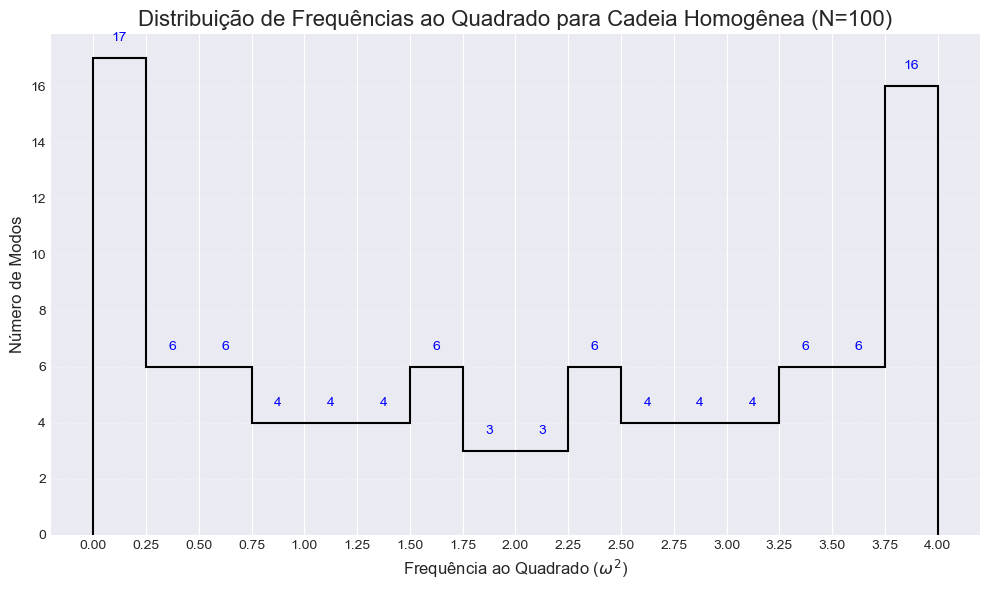

Contagem de modos para Cadeia Homogênea:
  [0-0.25): 23
  [0.25-0.5): 6
  [0.5-0.75): 6
  [0.75-1): 4
  [1-1.25): 8
  [1.25-1.5): 10
  [1.5-1.75): 9
  [1.75-2): 6
  [2-2.25): 9
  [2.25-2.5): 10
  [2.5-2.75): 8
  [2.75-3): 4
  [3-3.25): 4
  [3.25-3.5): 6
  [3.5-3.75): 6
  [3.75-4): 16


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                          Pode ser um único float (homogênea)
                                          ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- Parâmetros Definidos pelo Usuário ---
N_particles = 100 # Um número maior de partículas para uma melhor distribuição no histograma
k_spring = 1     # Constante elástica da mola

# --- Escolha o tipo de cadeia para analisar no histograma ---
# Opção 1: Cadeia Homogênea (descomente para usar)
chain_type = "Homogênea"
mass_value_for_chain = 1 # Todas as massas são 'm'


# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# Calcula autovalores
autovalores, _ = eig(B_matrix)

# Os autovalores podem ser complexos devido a pequenas imprecisões numéricas.
# Para frequências, esperamos valores reais e não-negativos.
frequencias_quadrado = np.real(autovalores)
frequencias_quadrado = frequencias_quadrado[frequencias_quadrado >= 0] # Garante que sejam não-negativos

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(10, 6))

# Definindo os "bins" (intervalos) para o histograma
bins = [0, 0.25,0.5,0.75,1, 1.25,1.5,1.75, 2, 2.25,2.5,2.75, 3, 3.25,3.5,3.75,4]  # Intervalos

# Plotando o histograma com as modificações:
# rwidth=1.0 para barras coladas (sem espaço entre elas)
# histtype='step' para apenas o contorno, sem preenchimento
n, bins, patches = plt.hist(frequencias_quadrado, bins=bins,
                            edgecolor='black', # Cor do contorno
                            histtype='step',   # Tipo de histograma: apenas contorno
                            rwidth=1.0,        # Barras coladas
                            linewidth=1.5)     # Espessura da linha do contorno

plt.title(f'Distribuição de Frequências ao Quadrado para Cadeia {chain_type} (N={N_particles})', fontsize=16)
plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)
plt.ylabel('Número de Modos', fontsize=12)
plt.xticks(bins) # Garante que os ticks do eixo X estejam nos limites dos bins
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adiciona o número de modos em cada barra do histograma
# O posicionamento 'x' precisará de um pequeno ajuste para ficar no centro do bin
for i in range(len(n)):
    x_pos = bins[i] + 0.5 * (bins[i+1] - bins[i]) # Centro do bin
    plt.text(x_pos, n[i] + 0.5,
             f'{int(n[i])}', ha='center', va='bottom', fontsize=10, color='blue')


plt.tight_layout()
plt.show()

# Opcional: Imprimir a contagem exata para cada bin
print(f"Contagem de modos para Cadeia {chain_type}:")
print(f"  [0-0.25): {np.sum((frequencias_quadrado >= 0) & (frequencias_quadrado < 0.5))}")
print(f"  [0.25-0.5): {np.sum((frequencias_quadrado >= 0.25) & (frequencias_quadrado < 0.5))}")
print(f"  [0.5-0.75): {np.sum((frequencias_quadrado >= 0.5) & (frequencias_quadrado < 0.75))}")
print(f"  [0.75-1): {np.sum((frequencias_quadrado >= 0.75) & (frequencias_quadrado < 1))}")
print(f"  [1-1.25): {np.sum((frequencias_quadrado >= 1) & (frequencias_quadrado < 1.5))}")
print(f"  [1.25-1.5): {np.sum((frequencias_quadrado >= 1.25) & (frequencias_quadrado < 1.75))}")
print(f"  [1.5-1.75): {np.sum((frequencias_quadrado >= 1.5) & (frequencias_quadrado < 2))}")
print(f"  [1.75-2): {np.sum((frequencias_quadrado >= 1.75) & (frequencias_quadrado < 2.25))}")
print(f"  [2-2.25): {np.sum((frequencias_quadrado >= 2) & (frequencias_quadrado < 2.5))}")
print(f"  [2.25-2.5): {np.sum((frequencias_quadrado >= 2.25) & (frequencias_quadrado < 2.75))}")
print(f"  [2.5-2.75): {np.sum((frequencias_quadrado >= 2.5) & (frequencias_quadrado < 3))}")
print(f"  [2.75-3): {np.sum((frequencias_quadrado >= 2.75) & (frequencias_quadrado < 3))}")
print(f"  [3-3.25): {np.sum((frequencias_quadrado >= 3) & (frequencias_quadrado < 3.25))}")
print(f"  [3.25-3.5): {np.sum((frequencias_quadrado >= 3.25) & (frequencias_quadrado < 3.5))}")
print(f"  [3.5-3.75): {np.sum((frequencias_quadrado >= 3.5) & (frequencias_quadrado < 3.75))}")
print(f"  [3.75-4): {np.sum((frequencias_quadrado >= 3.75) & (frequencias_quadrado < 4))}")

<>:80: SyntaxWarning: invalid escape sequence '\o'
<>:80: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\1909418643.py:80: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)


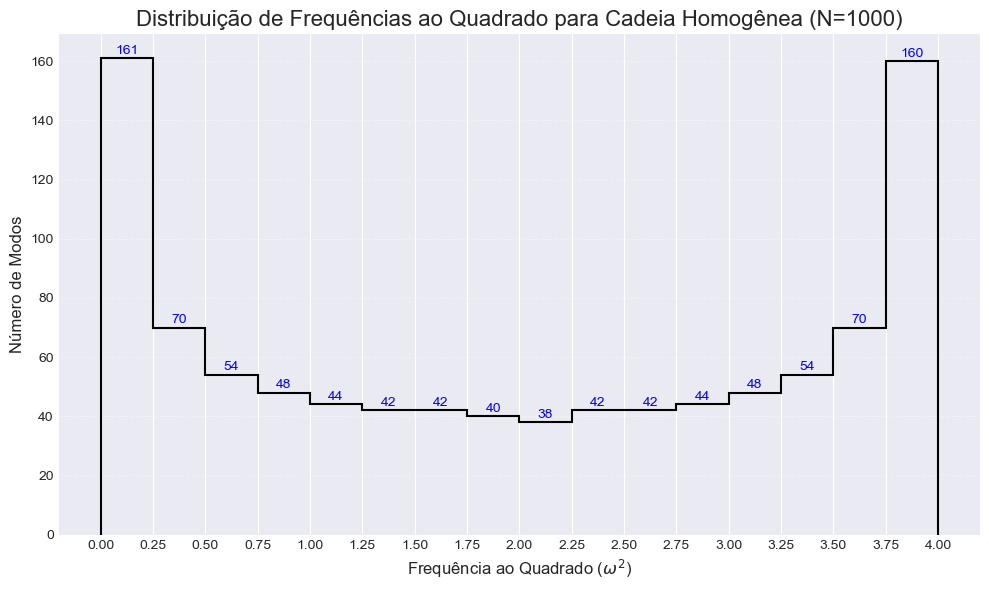

Contagem de modos para Cadeia Homogênea:
  [0-0.25): 231
  [0.25-0.5): 70
  [0.5-0.75): 54
  [0.75-1): 48
  [1-1.25): 86
  [1.25-1.5): 84
  [1.5-1.75): 82
  [1.75-2): 78
  [2-2.25): 80
  [2.25-2.5): 84
  [2.5-2.75): 86
  [2.75-3): 44
  [3-3.25): 48
  [3.25-3.5): 54
  [3.5-3.75): 70
  [3.75-4): 160


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                          Pode ser um único float (homogênea)
                                          ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- Parâmetros Definidos pelo Usuário ---
N_particles = 1000 # Um número maior de partículas para uma melhor distribuição no histograma
k_spring = 1     # Constante elástica da mola

# --- Escolha o tipo de cadeia para analisar no histograma ---
# Opção 1: Cadeia Homogênea (descomente para usar)
chain_type = "Homogênea"
mass_value_for_chain = 1 # Todas as massas são 'm'


# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# Calcula autovalores
autovalores, _ = eig(B_matrix)

# Os autovalores podem ser complexos devido a pequenas imprecisões numéricas.
# Para frequências, esperamos valores reais e não-negativos.
frequencias_quadrado = np.real(autovalores)
frequencias_quadrado = frequencias_quadrado[frequencias_quadrado >= 0] # Garante que sejam não-negativos

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(10, 6))

# Definindo os "bins" (intervalos) para o histograma
bins = [0, 0.25,0.5,0.75,1, 1.25,1.5,1.75, 2, 2.25,2.5,2.75, 3, 3.25,3.5,3.75,4] # Intervalos

# Plotando o histograma com as modificações:
# rwidth=1.0 para barras coladas (sem espaço entre elas)
# histtype='step' para apenas o contorno, sem preenchimento
n, bins, patches = plt.hist(frequencias_quadrado, bins=bins,
                            edgecolor='black', # Cor do contorno
                            histtype='step',   # Tipo de histograma: apenas contorno
                            rwidth=1.0,        # Barras coladas
                            linewidth=1.5)     # Espessura da linha do contorno

plt.title(f'Distribuição de Frequências ao Quadrado para Cadeia {chain_type} (N={N_particles})', fontsize=16)
plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)
plt.ylabel('Número de Modos', fontsize=12)
plt.xticks(bins) # Garante que os ticks do eixo X estejam nos limites dos bins
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adiciona o número de modos em cada barra do histograma
# O posicionamento 'x' precisará de um pequeno ajuste para ficar no centro do bin
for i in range(len(n)):
    x_pos = bins[i] + 0.5 * (bins[i+1] - bins[i]) # Centro do bin
    plt.text(x_pos, n[i] + 0.5,
             f'{int(n[i])}', ha='center', va='bottom', fontsize=10, color='blue')


plt.tight_layout()
plt.show()

# Opcional: Imprimir a contagem exata para cada bin
print(f"Contagem de modos para Cadeia {chain_type}:")
print(f"  [0-0.25): {np.sum((frequencias_quadrado >= 0) & (frequencias_quadrado < 0.5))}")
print(f"  [0.25-0.5): {np.sum((frequencias_quadrado >= 0.25) & (frequencias_quadrado < 0.5))}")
print(f"  [0.5-0.75): {np.sum((frequencias_quadrado >= 0.5) & (frequencias_quadrado < 0.75))}")
print(f"  [0.75-1): {np.sum((frequencias_quadrado >= 0.75) & (frequencias_quadrado < 1))}")
print(f"  [1-1.25): {np.sum((frequencias_quadrado >= 1) & (frequencias_quadrado < 1.5))}")
print(f"  [1.25-1.5): {np.sum((frequencias_quadrado >= 1.25) & (frequencias_quadrado < 1.75))}")
print(f"  [1.5-1.75): {np.sum((frequencias_quadrado >= 1.5) & (frequencias_quadrado < 2))}")
print(f"  [1.75-2): {np.sum((frequencias_quadrado >= 1.75) & (frequencias_quadrado < 2.25))}")
print(f"  [2-2.25): {np.sum((frequencias_quadrado >= 2) & (frequencias_quadrado < 2.5))}")
print(f"  [2.25-2.5): {np.sum((frequencias_quadrado >= 2.25) & (frequencias_quadrado < 2.75))}")
print(f"  [2.5-2.75): {np.sum((frequencias_quadrado >= 2.5) & (frequencias_quadrado < 3))}")
print(f"  [2.75-3): {np.sum((frequencias_quadrado >= 2.75) & (frequencias_quadrado < 3))}")
print(f"  [3-3.25): {np.sum((frequencias_quadrado >= 3) & (frequencias_quadrado < 3.25))}")
print(f"  [3.25-3.5): {np.sum((frequencias_quadrado >= 3.25) & (frequencias_quadrado < 3.5))}")
print(f"  [3.5-3.75): {np.sum((frequencias_quadrado >= 3.5) & (frequencias_quadrado < 3.75))}")
print(f"  [3.75-4): {np.sum((frequencias_quadrado >= 3.75) & (frequencias_quadrado < 4))}")

<>:80: SyntaxWarning: invalid escape sequence '\o'
<>:80: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\1634179074.py:80: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)


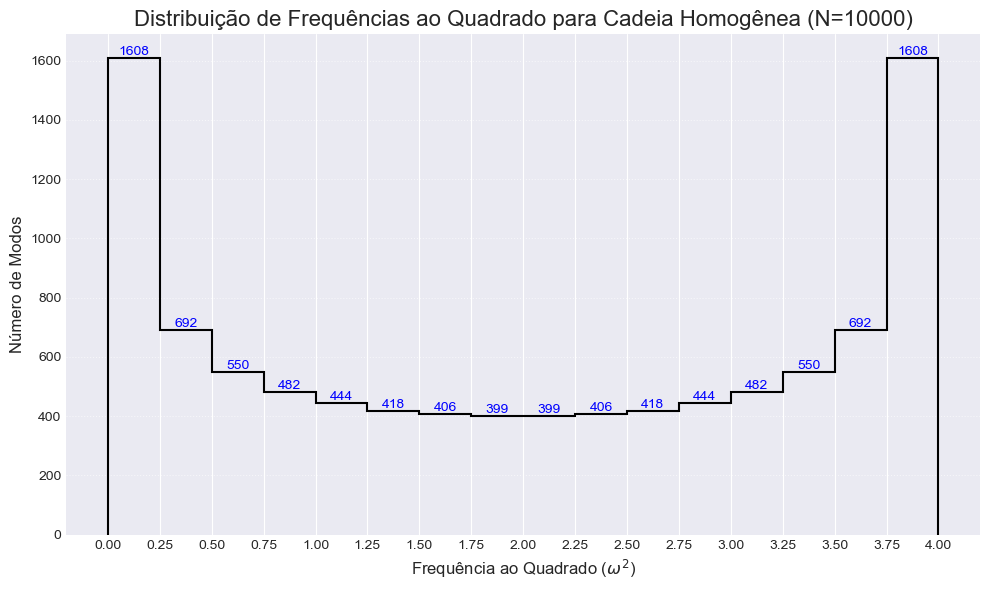

Contagem de modos para Cadeia Homogênea:
  [0-0.25): 2300
  [0.25-0.5): 692
  [0.5-0.75): 550
  [0.75-1): 482
  [1-1.25): 862
  [1.25-1.5): 824
  [1.5-1.75): 805
  [1.75-2): 798
  [2-2.25): 805
  [2.25-2.5): 824
  [2.5-2.75): 862
  [2.75-3): 444
  [3-3.25): 482
  [3.25-3.5): 550
  [3.5-3.75): 692
  [3.75-4): 1608


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                          Pode ser um único float (homogênea)
                                          ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- Parâmetros Definidos pelo Usuário ---
N_particles = 10000 # Um número maior de partículas para uma melhor distribuição no histograma
k_spring = 1     # Constante elástica da mola

# --- Escolha o tipo de cadeia para analisar no histograma ---
# Opção 1: Cadeia Homogênea (descomente para usar)
chain_type = "Homogênea"
mass_value_for_chain = 1 # Todas as massas são 'm'


# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# Calcula autovalores
autovalores, _ = eig(B_matrix)

# Os autovalores podem ser complexos devido a pequenas imprecisões numéricas.
# Para frequências, esperamos valores reais e não-negativos.
frequencias_quadrado = np.real(autovalores)
frequencias_quadrado = frequencias_quadrado[frequencias_quadrado >= 0] # Garante que sejam não-negativos

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(10, 6))

# Definindo os "bins" (intervalos) para o histograma
bins = [0, 0.25,0.5,0.75,1, 1.25,1.5,1.75, 2, 2.25,2.5,2.75, 3, 3.25,3.5,3.75,4] # Intervalos 

# Plotando o histograma com as modificações:
# rwidth=1.0 para barras coladas (sem espaço entre elas)
# histtype='step' para apenas o contorno, sem preenchimento
n, bins, patches = plt.hist(frequencias_quadrado, bins=bins,
                            edgecolor='black', # Cor do contorno
                            histtype='step',   # Tipo de histograma: apenas contorno
                            rwidth=1.0,        # Barras coladas
                            linewidth=1.5)     # Espessura da linha do contorno

plt.title(f'Distribuição de Frequências ao Quadrado para Cadeia {chain_type} (N={N_particles})', fontsize=16)
plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)
plt.ylabel('Número de Modos', fontsize=12)
plt.xticks(bins) # Garante que os ticks do eixo X estejam nos limites dos bins
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adiciona o número de modos em cada barra do histograma
# O posicionamento 'x' precisará de um pequeno ajuste para ficar no centro do bin
for i in range(len(n)):
    x_pos = bins[i] + 0.5 * (bins[i+1] - bins[i]) # Centro do bin
    plt.text(x_pos, n[i] + 0.5,
             f'{int(n[i])}', ha='center', va='bottom', fontsize=10, color='blue')


plt.tight_layout()
plt.show()

# Opcional: Imprimir a contagem exata para cada bin
print(f"Contagem de modos para Cadeia {chain_type}:")
print(f"  [0-0.25): {np.sum((frequencias_quadrado >= 0) & (frequencias_quadrado < 0.5))}")
print(f"  [0.25-0.5): {np.sum((frequencias_quadrado >= 0.25) & (frequencias_quadrado < 0.5))}")
print(f"  [0.5-0.75): {np.sum((frequencias_quadrado >= 0.5) & (frequencias_quadrado < 0.75))}")
print(f"  [0.75-1): {np.sum((frequencias_quadrado >= 0.75) & (frequencias_quadrado < 1))}")
print(f"  [1-1.25): {np.sum((frequencias_quadrado >= 1) & (frequencias_quadrado < 1.5))}")
print(f"  [1.25-1.5): {np.sum((frequencias_quadrado >= 1.25) & (frequencias_quadrado < 1.75))}")
print(f"  [1.5-1.75): {np.sum((frequencias_quadrado >= 1.5) & (frequencias_quadrado < 2))}")
print(f"  [1.75-2): {np.sum((frequencias_quadrado >= 1.75) & (frequencias_quadrado < 2.25))}")
print(f"  [2-2.25): {np.sum((frequencias_quadrado >= 2) & (frequencias_quadrado < 2.5))}")
print(f"  [2.25-2.5): {np.sum((frequencias_quadrado >= 2.25) & (frequencias_quadrado < 2.75))}")
print(f"  [2.5-2.75): {np.sum((frequencias_quadrado >= 2.5) & (frequencias_quadrado < 3))}")
print(f"  [2.75-3): {np.sum((frequencias_quadrado >= 2.75) & (frequencias_quadrado < 3))}")
print(f"  [3-3.25): {np.sum((frequencias_quadrado >= 3) & (frequencias_quadrado < 3.25))}")
print(f"  [3.25-3.5): {np.sum((frequencias_quadrado >= 3.25) & (frequencias_quadrado < 3.5))}")
print(f"  [3.5-3.75): {np.sum((frequencias_quadrado >= 3.5) & (frequencias_quadrado < 3.75))}")
print(f"  [3.75-4): {np.sum((frequencias_quadrado >= 3.75) & (frequencias_quadrado < 4))}")

### Análise

Como esperado de uma distribuíção de uma cadeia homogênea, temos algo que "parece" uma parábola. Isso é esperado, como explicado em aula, a "densidade de frequências" deve ser uma função simétrica. Se interpretarmos físicamente, o acoplamento das massas deve se comportar como uma onda. Logo, estados de energia (frequência) extremas são mais prováveis que estados de energias intermediários, no ponto de vista da mecância quântica, estados intermediários são improváveis.

<>:83: SyntaxWarning: invalid escape sequence '\o'
<>:83: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\1917876206.py:83: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)


Massas Aleatórias para o Histograma: [3 4 1 3 3 4 1 1 3 2 3 3 3 3 4 1 4 4 4 3 2 1 2 4 4 2 2 2 4 4 1 1 4 2 2 1 4
 1 1 3 3 3 2 4 4 4 4 3 2 2 3 2 3 4 3 4 4 1 3 1 3 3 1 1 3 2 4 1 4 2 2 2 1 2
 1 2 4 4 3 4 3 4 1 4 3 3 2 1 4 2 4 4 2 2 2 2 2 4 2 1]



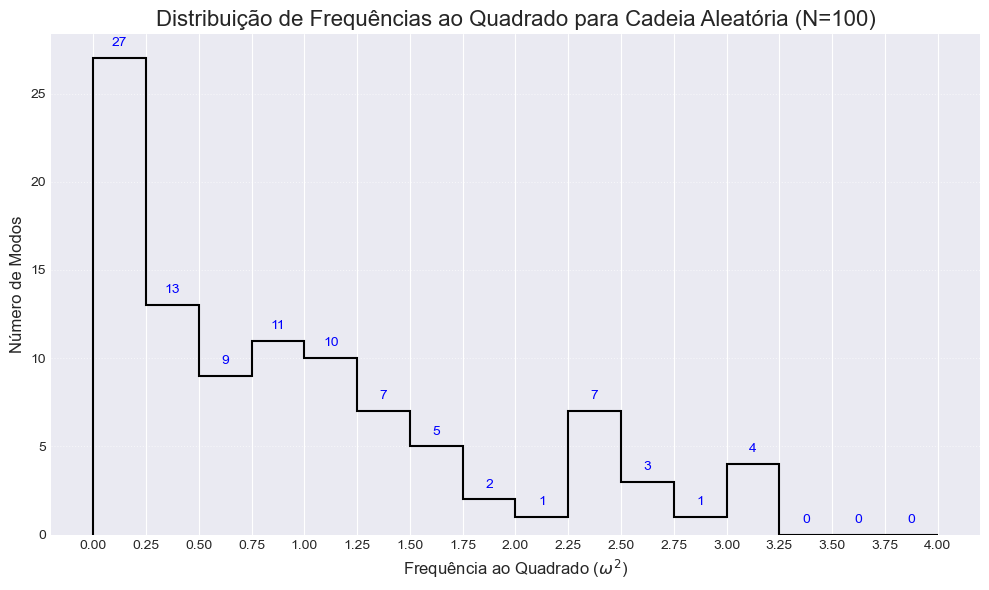

Contagem de modos para Cadeia Aleatória:
  [0-0.25): 40
  [0.25-0.5): 13
  [0.5-0.75): 9
  [0.75-1): 11
  [1-1.25): 17
  [1.25-1.5): 12
  [1.5-1.75): 7
  [1.75-2): 3
  [2-2.25): 8
  [2.25-2.5): 10
  [2.5-2.75): 4
  [2.75-3): 1
  [3-3.25): 4
  [3.25-3.5): 0
  [3.5-3.75): 0
  [3.75-4): 0


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                          Pode ser um único float (homogênea)
                                          ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- Parâmetros Definidos pelo Usuário ---
N_particles = 100 # Um número maior de partículas para uma melhor distribuição no histograma
k_spring = 1     # Constante elástica da mola

# --- Escolha o tipo de cadeia para analisar no histograma ---
# Cadeia Aleatória
chain_type = "Aleatória"
m_base = 1
np.random.seed(42) # Para reprodutibilidade
mass_value_for_chain = np.random.randint(1, 5, N_particles) * m_base
print(f"Massas Aleatórias para o Histograma: {mass_value_for_chain}\n")
# -----------------------------------------------------------

# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# Calcula autovalores
autovalores, _ = eig(B_matrix)

# Os autovalores podem ser complexos devido a pequenas imprecisões numéricas.
# Para frequências, esperamos valores reais e não-negativos.
frequencias_quadrado = np.real(autovalores)
frequencias_quadrado = frequencias_quadrado[frequencias_quadrado >= 0] # Garante que sejam não-negativos

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(10, 6))

# Definindo os "bins" (intervalos) para o histograma
bins = [0, 0.25,0.5,0.75,1, 1.25,1.5,1.75, 2, 2.25,2.5,2.75, 3, 3.25,3.5,3.75,4] # Intervalos

# Plotando o histograma com as modificações:
# rwidth=1.0 para barras coladas (sem espaço entre elas)
# histtype='step' para apenas o contorno, sem preenchimento
n, bins, patches = plt.hist(frequencias_quadrado, bins=bins,
                            edgecolor='black', # Cor do contorno
                            histtype='step',   # Tipo de histograma: apenas contorno
                            rwidth=1.0,        # Barras coladas
                            linewidth=1.5)     # Espessura da linha do contorno

plt.title(f'Distribuição de Frequências ao Quadrado para Cadeia {chain_type} (N={N_particles})', fontsize=16)
plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)
plt.ylabel('Número de Modos', fontsize=12)
plt.xticks(bins) # Garante que os ticks do eixo X estejam nos limites dos bins
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adiciona o número de modos em cada barra do histograma
# O posicionamento 'x' precisará de um pequeno ajuste para ficar no centro do bin
for i in range(len(n)):
    x_pos = bins[i] + 0.5 * (bins[i+1] - bins[i]) # Centro do bin
    plt.text(x_pos, n[i] + 0.5,
             f'{int(n[i])}', ha='center', va='bottom', fontsize=10, color='blue')


plt.tight_layout()
plt.show()
print(f"Contagem de modos para Cadeia {chain_type}:")
print(f"  [0-0.25): {np.sum((frequencias_quadrado >= 0) & (frequencias_quadrado < 0.5))}")
print(f"  [0.25-0.5): {np.sum((frequencias_quadrado >= 0.25) & (frequencias_quadrado < 0.5))}")
print(f"  [0.5-0.75): {np.sum((frequencias_quadrado >= 0.5) & (frequencias_quadrado < 0.75))}")
print(f"  [0.75-1): {np.sum((frequencias_quadrado >= 0.75) & (frequencias_quadrado < 1))}")
print(f"  [1-1.25): {np.sum((frequencias_quadrado >= 1) & (frequencias_quadrado < 1.5))}")
print(f"  [1.25-1.5): {np.sum((frequencias_quadrado >= 1.25) & (frequencias_quadrado < 1.75))}")
print(f"  [1.5-1.75): {np.sum((frequencias_quadrado >= 1.5) & (frequencias_quadrado < 2))}")
print(f"  [1.75-2): {np.sum((frequencias_quadrado >= 1.75) & (frequencias_quadrado < 2.25))}")
print(f"  [2-2.25): {np.sum((frequencias_quadrado >= 2) & (frequencias_quadrado < 2.5))}")
print(f"  [2.25-2.5): {np.sum((frequencias_quadrado >= 2.25) & (frequencias_quadrado < 2.75))}")
print(f"  [2.5-2.75): {np.sum((frequencias_quadrado >= 2.5) & (frequencias_quadrado < 3))}")
print(f"  [2.75-3): {np.sum((frequencias_quadrado >= 2.75) & (frequencias_quadrado < 3))}")
print(f"  [3-3.25): {np.sum((frequencias_quadrado >= 3) & (frequencias_quadrado < 3.25))}")
print(f"  [3.25-3.5): {np.sum((frequencias_quadrado >= 3.25) & (frequencias_quadrado < 3.5))}")
print(f"  [3.5-3.75): {np.sum((frequencias_quadrado >= 3.5) & (frequencias_quadrado < 3.75))}")
print(f"  [3.75-4): {np.sum((frequencias_quadrado >= 3.75) & (frequencias_quadrado < 4))}")

<>:83: SyntaxWarning: invalid escape sequence '\o'
<>:83: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\146860730.py:83: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)


Massas Aleatórias para o Histograma: [3 4 1 3 3 4 1 1 3 2 3 3 3 3 4 1 4 4 4 3 2 1 2 4 4 2 2 2 4 4 1 1 4 2 2 1 4
 1 1 3 3 3 2 4 4 4 4 3 2 2 3 2 3 4 3 4 4 1 3 1 3 3 1 1 3 2 4 1 4 2 2 2 1 2
 1 2 4 4 3 4 3 4 1 4 3 3 2 1 4 2 4 4 2 2 2 2 2 4 2 1 3 2 2 4 2 2 2 4 2 3 4
 3 4 2 3 4 1 2 4 1 4 1 2 3 1 4 2 1 4 4 4 1 1 1 3 1 1 1 3 1 4 1 4 4 4 3 3 3
 1 4 3 3 1 3 1 2 3 2 1 4 3 1 4 4 2 1 4 3 3 2 4 1 3 4 4 2 3 3 1 3 1 3 2 3 1
 1 2 3 3 2 3 3 1 3 3 2 2 4 1 3 3 4 3 1 4 1 4 4 2 1 3 3 1 3 3 1 4 1 4 3 3 3
 2 4 2 2 1 2 1 1 2 4 4 4 4 4 2 2 3 4 2 3 4 1 3 2 1 1 1 3 2 1 4 1 1 3 3 2 4
 3 1 2 1 1 3 2 4 4 3 3 2 4 4 4 1 4 1 2 1 2 4 4 2 3 2 3 1 1 1 4 1 3 1 2 2 4
 2 3 1 4 1 1 3 2 2 1 4 2 4 2 4 3 4 3 3 4 3 1 3 2 4 1 4 2 2 2 3 3 4 4 1 1 4
 3 2 4 1 3 4 4 3 4 3 2 3 3 3 4 4 3 4 1 1 4 4 3 2 4 1 3 4 1 1 2 3 3 2 2 3 3
 4 4 2 4 1 4 4 1 2 1 4 2 4 1 1 4 3 3 1 1 3 3 4 4 3 4 4 2 4 1 4 4 3 1 4 4 2
 4 4 2 3 4 2 1 3 1 1 2 4 2 2 2 2 3 4 1 1 4 1 4 1 2 1 4 4 4 4 4 3 3 1 4 1 4
 4 3 3 2 3 2 2 2 2 2 1 3 2 4 3 3 2 1 2 1 4 3 4 1 1 4 1 4 3 4 3 

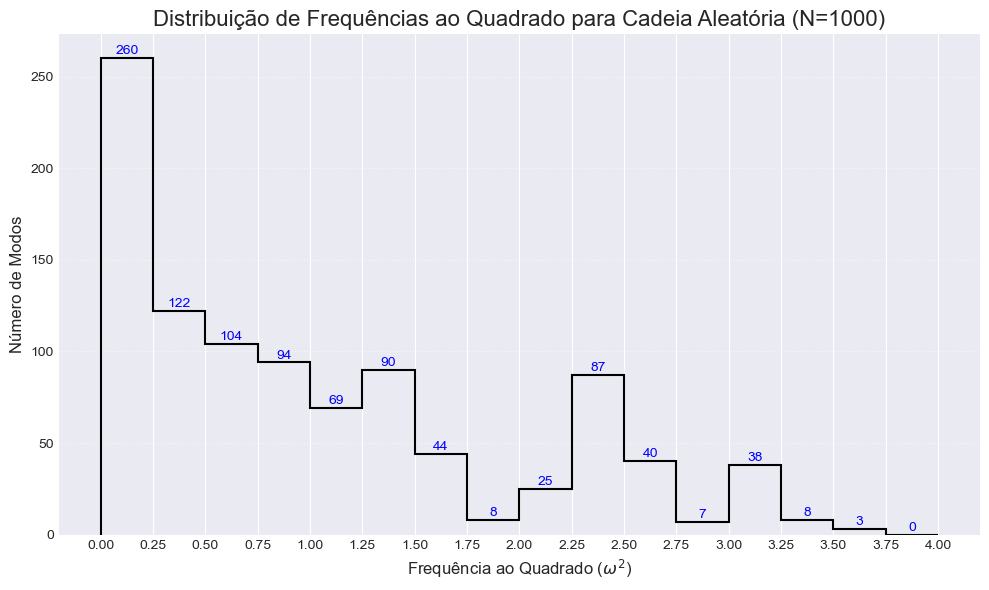

Contagem de modos para Cadeia Aleatória:
  [0-0.25): 382
  [0.25-0.5): 122
  [0.5-0.75): 104
  [0.75-1): 94
  [1-1.25): 159
  [1.25-1.5): 134
  [1.5-1.75): 52
  [1.75-2): 33
  [2-2.25): 112
  [2.25-2.5): 127
  [2.5-2.75): 47
  [2.75-3): 7
  [3-3.25): 38
  [3.25-3.5): 8
  [3.5-3.75): 3
  [3.75-4): 0


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                          Pode ser um único float (homogênea)
                                          ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- Parâmetros Definidos pelo Usuário ---
N_particles = 1000 # Um número maior de partículas para uma melhor distribuição no histograma
k_spring = 1     # Constante elástica da mola

# --- Escolha o tipo de cadeia para analisar no histograma ---
# Cadeia Aleatória
chain_type = "Aleatória"
m_base = 1
np.random.seed(42) # Para reprodutibilidade
mass_value_for_chain = np.random.randint(1, 5, N_particles) * m_base
print(f"Massas Aleatórias para o Histograma: {mass_value_for_chain}\n")
# -----------------------------------------------------------

# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# Calcula autovalores
autovalores, _ = eig(B_matrix)

# Os autovalores podem ser complexos devido a pequenas imprecisões numéricas.
# Para frequências, esperamos valores reais e não-negativos.
frequencias_quadrado = np.real(autovalores)
frequencias_quadrado = frequencias_quadrado[frequencias_quadrado >= 0] # Garante que sejam não-negativos

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(10, 6))

# Definindo os "bins" (intervalos) para o histograma
bins = [0, 0.25,0.5,0.75,1, 1.25,1.5,1.75, 2, 2.25,2.5,2.75, 3, 3.25,3.5,3.75,4] # Intervalos

# Plotando o histograma com as modificações:
# rwidth=1.0 para barras coladas (sem espaço entre elas)
# histtype='step' para apenas o contorno, sem preenchimento
n, bins, patches = plt.hist(frequencias_quadrado, bins=bins,
                            edgecolor='black', # Cor do contorno
                            histtype='step',   # Tipo de histograma: apenas contorno
                            rwidth=1.0,        # Barras coladas
                            linewidth=1.5)     # Espessura da linha do contorno

plt.title(f'Distribuição de Frequências ao Quadrado para Cadeia {chain_type} (N={N_particles})', fontsize=16)
plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)
plt.ylabel('Número de Modos', fontsize=12)
plt.xticks(bins) # Garante que os ticks do eixo X estejam nos limites dos bins
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adiciona o número de modos em cada barra do histograma
# O posicionamento 'x' precisará de um pequeno ajuste para ficar no centro do bin
for i in range(len(n)):
    x_pos = bins[i] + 0.5 * (bins[i+1] - bins[i]) # Centro do bin
    plt.text(x_pos, n[i] + 0.5,
             f'{int(n[i])}', ha='center', va='bottom', fontsize=10, color='blue')


plt.tight_layout()
plt.show()
print(f"Contagem de modos para Cadeia {chain_type}:")
print(f"  [0-0.25): {np.sum((frequencias_quadrado >= 0) & (frequencias_quadrado < 0.5))}")
print(f"  [0.25-0.5): {np.sum((frequencias_quadrado >= 0.25) & (frequencias_quadrado < 0.5))}")
print(f"  [0.5-0.75): {np.sum((frequencias_quadrado >= 0.5) & (frequencias_quadrado < 0.75))}")
print(f"  [0.75-1): {np.sum((frequencias_quadrado >= 0.75) & (frequencias_quadrado < 1))}")
print(f"  [1-1.25): {np.sum((frequencias_quadrado >= 1) & (frequencias_quadrado < 1.5))}")
print(f"  [1.25-1.5): {np.sum((frequencias_quadrado >= 1.25) & (frequencias_quadrado < 1.75))}")
print(f"  [1.5-1.75): {np.sum((frequencias_quadrado >= 1.5) & (frequencias_quadrado < 2))}")
print(f"  [1.75-2): {np.sum((frequencias_quadrado >= 1.75) & (frequencias_quadrado < 2.25))}")
print(f"  [2-2.25): {np.sum((frequencias_quadrado >= 2) & (frequencias_quadrado < 2.5))}")
print(f"  [2.25-2.5): {np.sum((frequencias_quadrado >= 2.25) & (frequencias_quadrado < 2.75))}")
print(f"  [2.5-2.75): {np.sum((frequencias_quadrado >= 2.5) & (frequencias_quadrado < 3))}")
print(f"  [2.75-3): {np.sum((frequencias_quadrado >= 2.75) & (frequencias_quadrado < 3))}")
print(f"  [3-3.25): {np.sum((frequencias_quadrado >= 3) & (frequencias_quadrado < 3.25))}")
print(f"  [3.25-3.5): {np.sum((frequencias_quadrado >= 3.25) & (frequencias_quadrado < 3.5))}")
print(f"  [3.5-3.75): {np.sum((frequencias_quadrado >= 3.5) & (frequencias_quadrado < 3.75))}")
print(f"  [3.75-4): {np.sum((frequencias_quadrado >= 3.75) & (frequencias_quadrado < 4))}")

Massas Aleatórias para o Histograma: [3 4 1 ... 2 2 1]



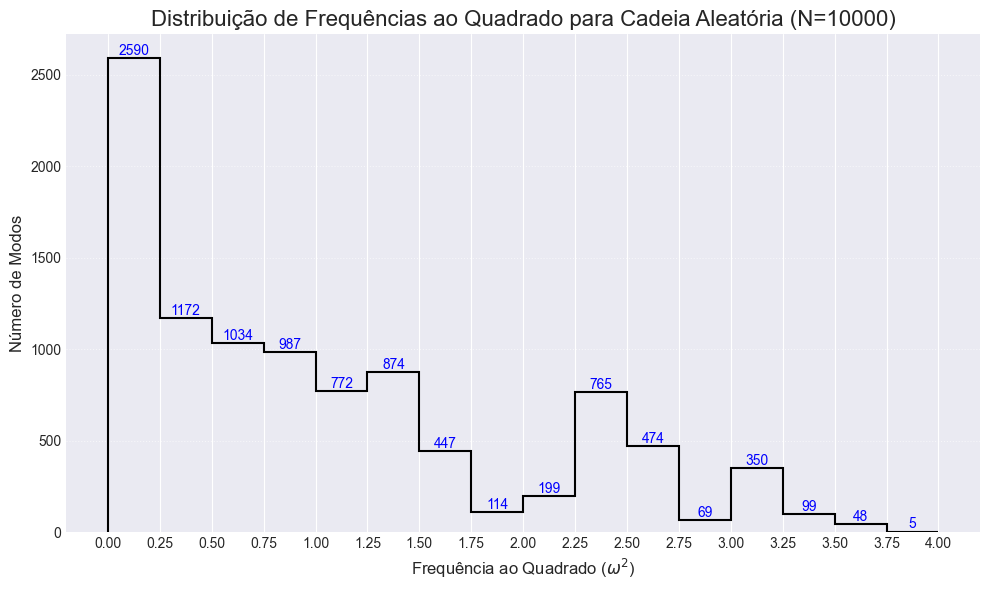

Contagem de modos para Cadeia Aleatória:
  [0-0.25): 3762
  [0.25-0.5): 1172
  [0.5-0.75): 1034
  [0.75-1): 987
  [1-1.25): 1646
  [1.25-1.5): 1321
  [1.5-1.75): 561
  [1.75-2): 313
  [2-2.25): 964
  [2.25-2.5): 1239
  [2.5-2.75): 543
  [2.75-3): 69
  [3-3.25): 350
  [3.25-3.5): 99
  [3.5-3.75): 48
  [3.75-4): 5

Número de modos com frequências ao quadrado >= 3: 502
Algumas dessas frequências: [3.03969533 3.05073821 3.05081955 3.05084612 3.05623726]...


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                          Pode ser um único float (homogênea)
                                          ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- Parâmetros Definidos pelo Usuário ---
N_particles = 10000 # Um número maior de partículas para uma melhor distribuição no histograma
k_spring = 1     # Constante elástica da mola

# --- Escolha o tipo de cadeia para analisar no histograma ---
# Cadeia Aleatória
chain_type = "Aleatória"
m_base = 1
np.random.seed(42) # Para reprodutibilidade
mass_value_for_chain = np.random.randint(1, 5, N_particles) * m_base
print(f"Massas Aleatórias para o Histograma: {mass_value_for_chain}\n")
# -----------------------------------------------------------

# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# Calcula autovalores
autovalores, _ = eig(B_matrix)

# Os autovalores podem ser complexos devido a pequenas imprecisões numéricas.
# Para frequências, esperamos valores reais e não-negativos.
frequencias_quadrado = np.real(autovalores)
frequencias_quadrado = frequencias_quadrado[frequencias_quadrado >= 0] # Garante que sejam não-negativos

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(10, 6))

# Definindo os "bins" (intervalos) para o histograma
bins = [0, 0.25,0.5,0.75,1, 1.25,1.5,1.75, 2, 2.25,2.5,2.75, 3, 3.25,3.5,3.75,4] # Intervalos # Intervalos

# Plotando o histograma com as modificações:
# rwidth=1.0 para barras coladas (sem espaço entre elas)
# histtype='step' para apenas o contorno, sem preenchimento
n, bins, patches = plt.hist(frequencias_quadrado, bins=bins,
                            edgecolor='black', # Cor do contorno
                            histtype='step',   # Tipo de histograma: apenas contorno
                            rwidth=1.0,        # Barras coladas
                            linewidth=1.5)     # Espessura da linha do contorno

plt.title(f'Distribuição de Frequências ao Quadrado para Cadeia {chain_type} (N={N_particles})', fontsize=16)
plt.xlabel('Frequência ao Quadrado ($\omega^2$)', fontsize=12)
plt.ylabel('Número de Modos', fontsize=12)
plt.xticks(bins) # Garante que os ticks do eixo X estejam nos limites dos bins
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adiciona o número de modos em cada barra do histograma
# O posicionamento 'x' precisará de um pequeno ajuste para ficar no centro do bin
for i in range(len(n)):
    x_pos = bins[i] + 0.5 * (bins[i+1] - bins[i]) # Centro do bin
    plt.text(x_pos, n[i] + 0.5,
             f'{int(n[i])}', ha='center', va='bottom', fontsize=10, color='blue')


plt.tight_layout()
plt.show()

# Opcional: Imprimir a contagem exata para cada bin
print(f"Contagem de modos para Cadeia {chain_type}:")
print(f"  [0-0.25): {np.sum((frequencias_quadrado >= 0) & (frequencias_quadrado < 0.5))}")
print(f"  [0.25-0.5): {np.sum((frequencias_quadrado >= 0.25) & (frequencias_quadrado < 0.5))}")
print(f"  [0.5-0.75): {np.sum((frequencias_quadrado >= 0.5) & (frequencias_quadrado < 0.75))}")
print(f"  [0.75-1): {np.sum((frequencias_quadrado >= 0.75) & (frequencias_quadrado < 1))}")
print(f"  [1-1.25): {np.sum((frequencias_quadrado >= 1) & (frequencias_quadrado < 1.5))}")
print(f"  [1.25-1.5): {np.sum((frequencias_quadrado >= 1.25) & (frequencias_quadrado < 1.75))}")
print(f"  [1.5-1.75): {np.sum((frequencias_quadrado >= 1.5) & (frequencias_quadrado < 2))}")
print(f"  [1.75-2): {np.sum((frequencias_quadrado >= 1.75) & (frequencias_quadrado < 2.25))}")
print(f"  [2-2.25): {np.sum((frequencias_quadrado >= 2) & (frequencias_quadrado < 2.5))}")
print(f"  [2.25-2.5): {np.sum((frequencias_quadrado >= 2.25) & (frequencias_quadrado < 2.75))}")
print(f"  [2.5-2.75): {np.sum((frequencias_quadrado >= 2.5) & (frequencias_quadrado < 3))}")
print(f"  [2.75-3): {np.sum((frequencias_quadrado >= 2.75) & (frequencias_quadrado < 3))}")
print(f"  [3-3.25): {np.sum((frequencias_quadrado >= 3) & (frequencias_quadrado < 3.25))}")
print(f"  [3.25-3.5): {np.sum((frequencias_quadrado >= 3.25) & (frequencias_quadrado < 3.5))}")
print(f"  [3.5-3.75): {np.sum((frequencias_quadrado >= 3.5) & (frequencias_quadrado < 3.75))}")
print(f"  [3.75-4): {np.sum((frequencias_quadrado >= 3.75) & (frequencias_quadrado < 4))}")

### Análise

Observe agora que ao obtermos uma cadeia amorfica os estados de maior frequência se tornam menos acessíveis. Isso pois o comportamento ondulatório se perde devido a má distribuíção das massas. Então apenas os modos normais de menor energia serão acessíveis e o comportamento ondulatório será observado.

3. Deslocamentos Relativos (Modos Normais)
- Para cada cadeia, obtenha os vetores de deslocamento (modos normais) correspondentes:
- Às cinco menores frequências (modos de baixa energia)
- Às cinco maiores frequências (modos de alta energia)
- Apresente gráficos dos deslocamentos relativos dos átomos para esses modos.

![Fluxovetores](ATV5vetores.png)

Analisando deslocamentos para uma cadeia 'Aleatória' com N=100 partículas.
Massas (primeiras 20): [3 4 1 3 3 4 1 1 3 2 3 3 3 3 4 1 4 4 4 3]...

--- Plotando os 5 modos de menor frequência (baixa energia) ---


<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_8512\2675193198.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_8512\2675193198.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')


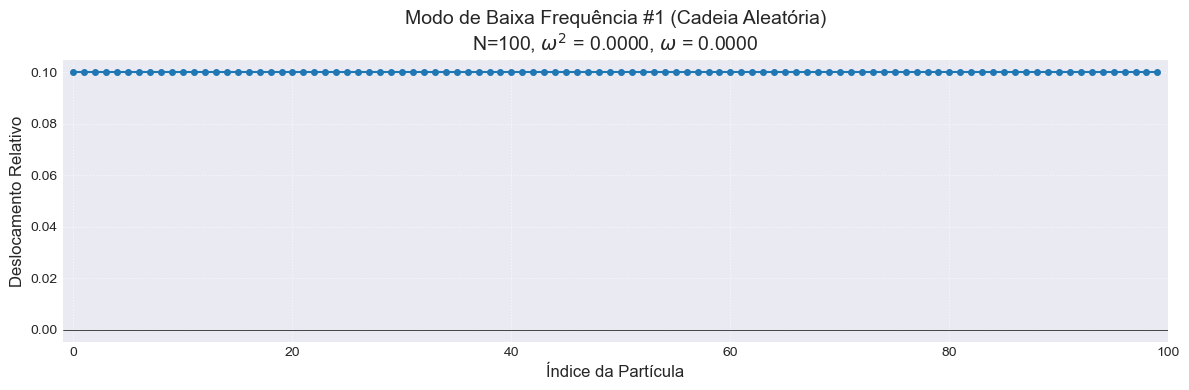

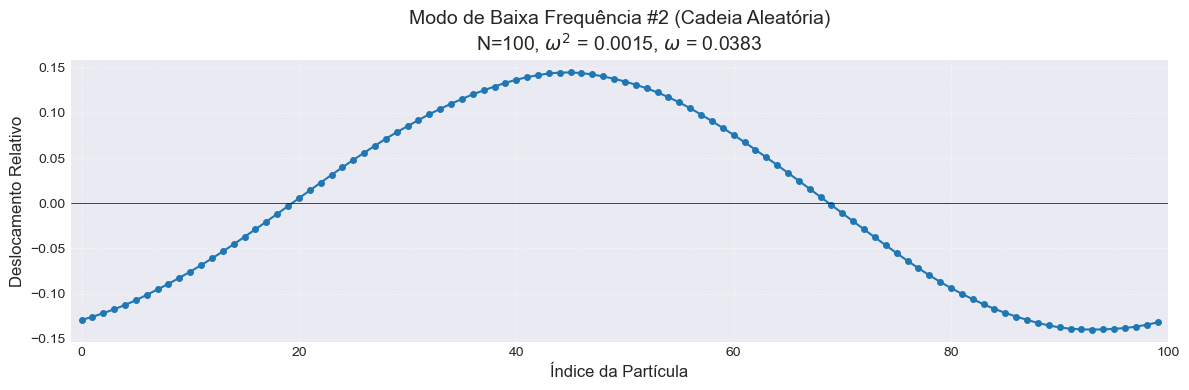

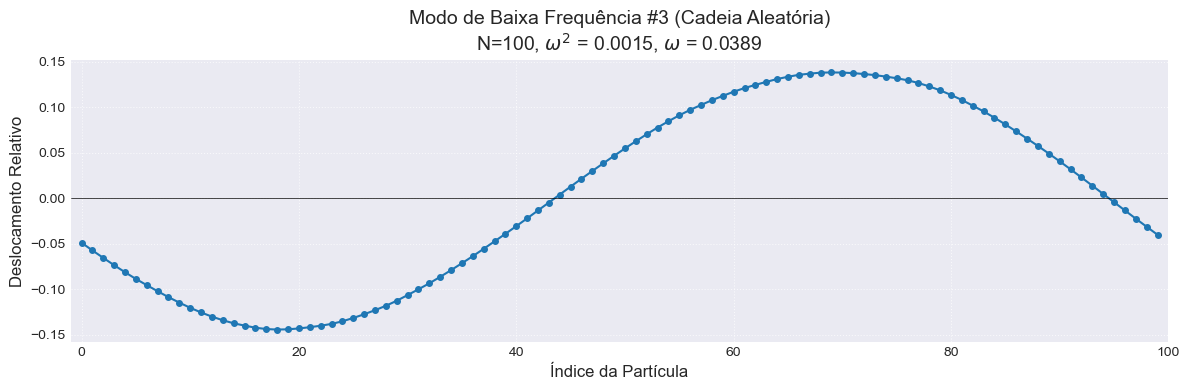

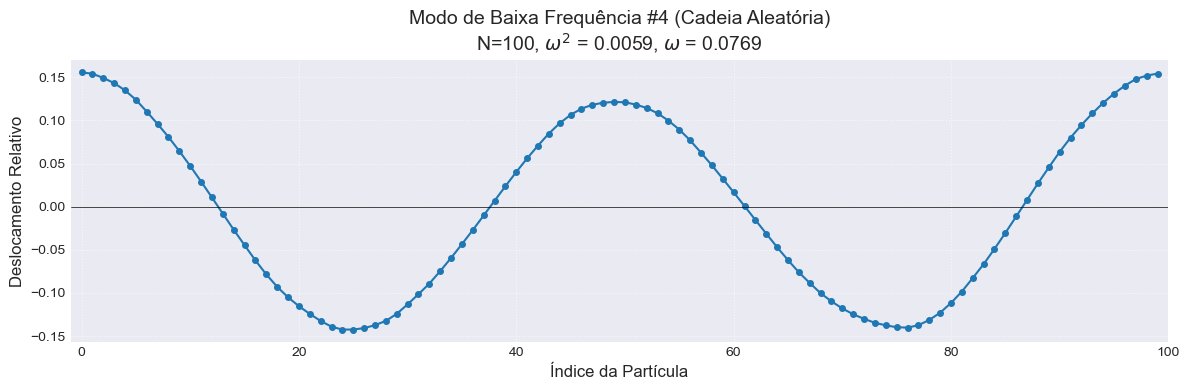

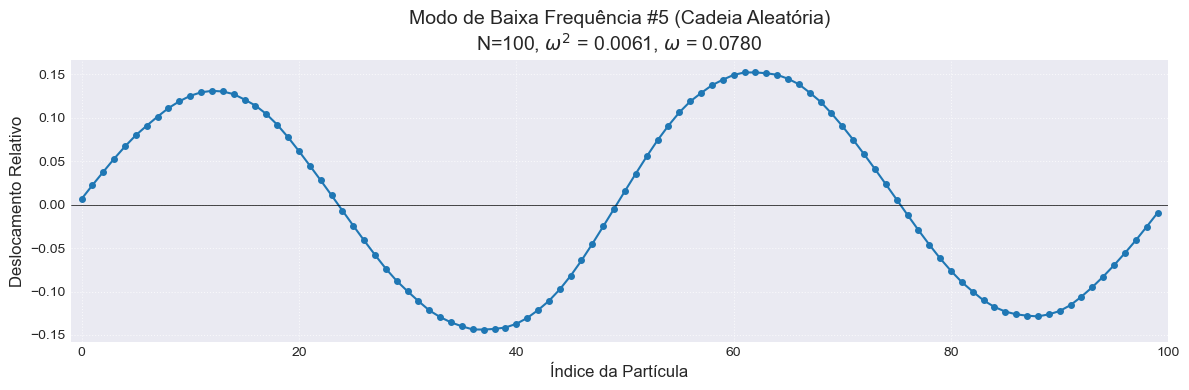


--- Plotando os 5 modos de maior frequência (alta energia) ---


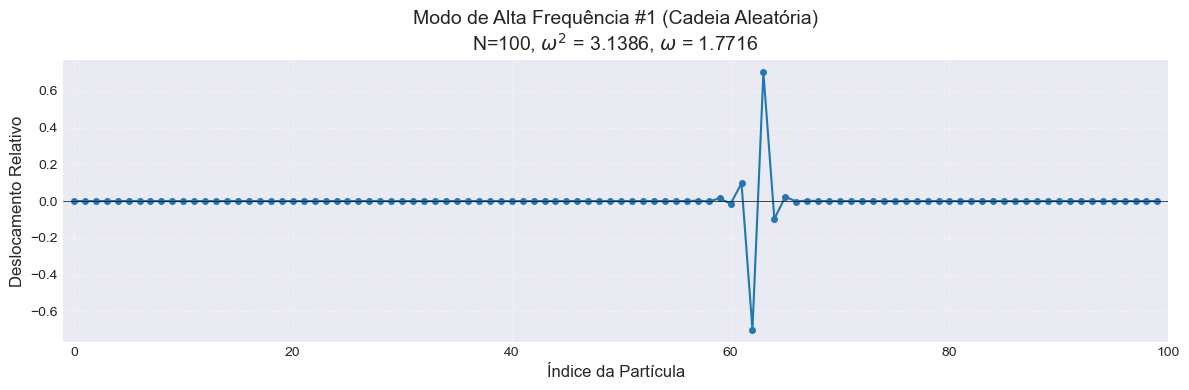

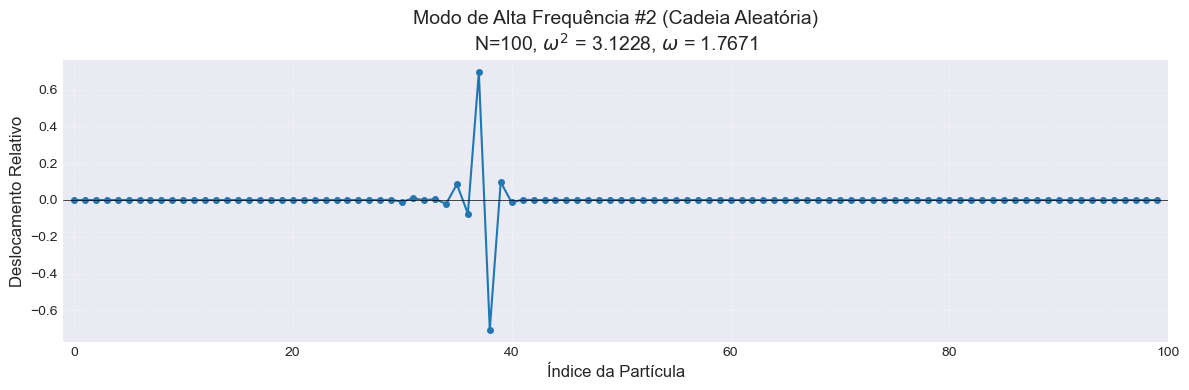

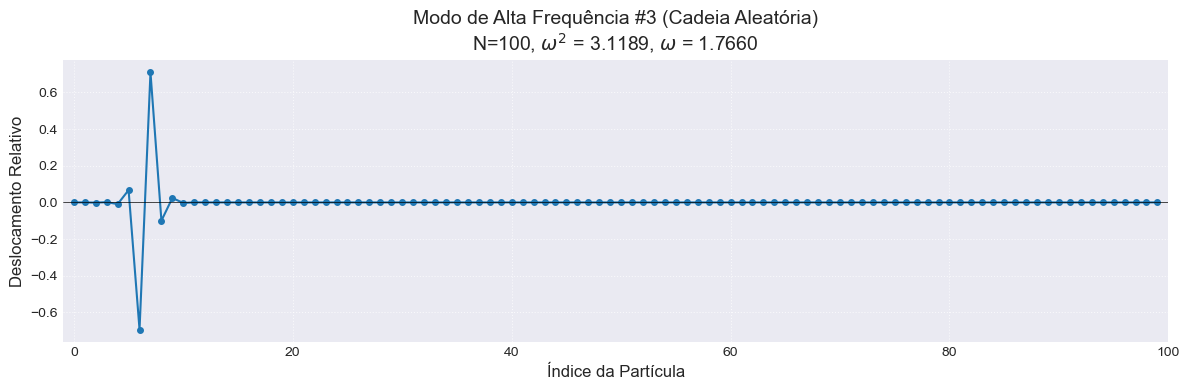

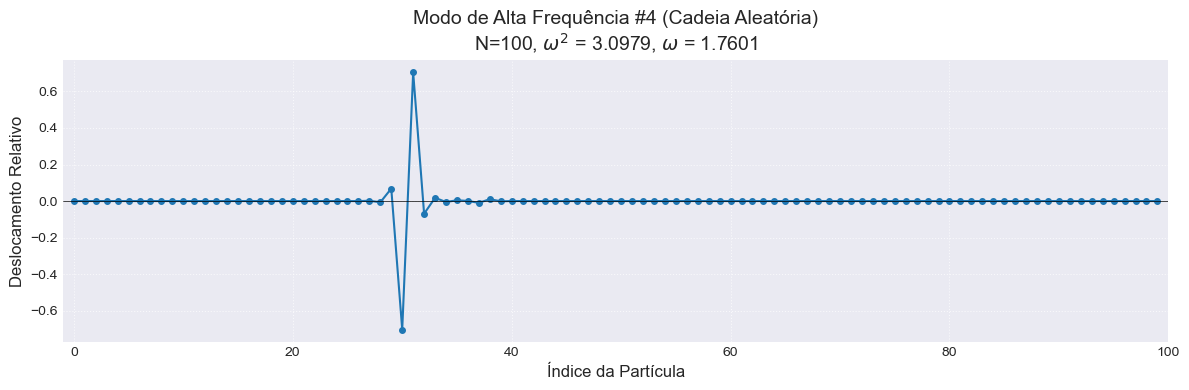

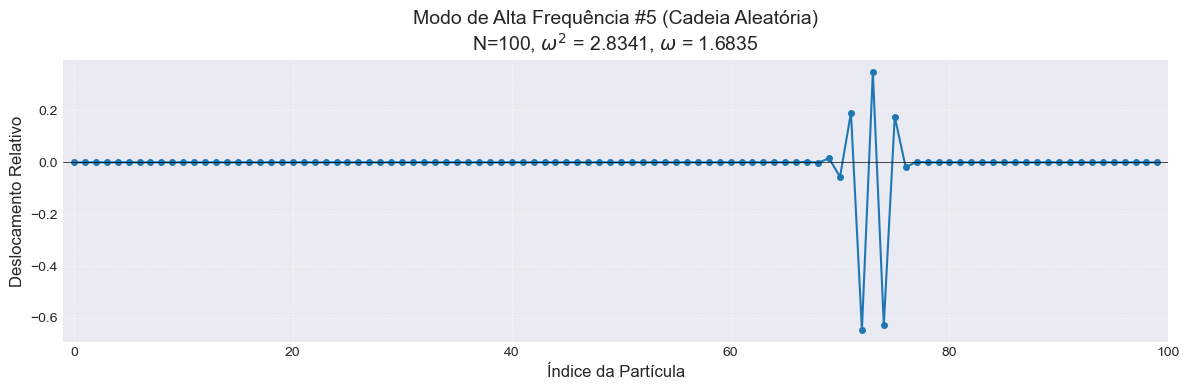

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                            Pode ser um único float (homogênea)
                                            ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- NOVA FUNÇÃO: Para plotar os deslocamentos ---
def plot_normal_mode(mode_vector, omega_squared, mode_rank, N, chain_type, mode_type):
    """
    Plota o deslocamento relativo dos átomos para um modo normal específico.

    Args:
        mode_vector (np.array): O autovetor (modo normal) a ser plotado.
        omega_squared (float): O autovalor (frequência ao quadrado) correspondente.
        mode_rank (int): A ordem do modo (1º, 2º, etc.) para o título.
        N (int): O número de partículas.
        chain_type (str): O tipo de cadeia (ex: 'Aleatória').
        mode_type (str): O tipo de modo (ex: 'Baixa Frequência', 'Alta Frequência').
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(12, 4))
    
    # Plota os deslocamentos usando marcadores e uma linha para conectar
    plt.plot(range(N), mode_vector, '-o', markersize=4, label='Deslocamento')
    
    # Adiciona uma linha horizontal em y=0 como referência
    plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    omega = np.sqrt(omega_squared) if omega_squared > 1e-9 else 0
    title = (f'Modo de {mode_type} #{mode_rank} (Cadeia {chain_type})\n'
             f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')
             
    plt.title(title, fontsize=14)
    plt.xlabel('Índice da Partícula', fontsize=12)
    plt.ylabel('Deslocamento Relativo', fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.xlim(-1, N) # Adiciona um pequeno espaço nas bordas do eixo x
    plt.tight_layout()
    plt.show()


# --- Parâmetros Definidos pelo Usuário ---
# N foi reduzido para uma visualização clara dos modos de deslocamento.
# Com 10.000 partículas, os padrões de onda seriam muito densos para serem vistos.
N_particles = 100 
k_spring = 1

# --- Escolha o tipo de cadeia para analisar ---
# Cadeia Aleatória
chain_type = "Aleatória"
m_base = 1
np.random.seed(42) # Para reprodutibilidade
mass_value_for_chain = np.random.randint(1, 5, N_particles) * m_base

print(f"Analisando deslocamentos para uma cadeia '{chain_type}' com N={N_particles} partículas.")
print(f"Massas (primeiras 20): {mass_value_for_chain[:20]}...\n")
# -----------------------------------------------------------

# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# --- MODIFICAÇÃO: Obter autovalores E autovetores ---
# A função `eig` retorna os autovalores e os autovetores correspondentes.
# Os autovetores são as colunas da matriz `autovetores`.
autovalores, autovetores = eig(B_matrix)

frequencias_quadrado = autovalores
modos_normais = autovetores

# --- NOVO: Ordenar frequências e modos ---
# `np.argsort` retorna os índices que ordenariam o array de frequências.
sorted_indices = np.argsort(frequencias_quadrado)

# Usa os índices ordenados para reorganizar tanto as frequências quanto os modos normais.
# Isso garante que cada frequência ainda corresponda ao seu modo correto.
sorted_frequencias_quadrado = frequencias_quadrado[sorted_indices]
# As colunas dos autovetores são reordenadas para corresponder às frequências ordenadas.
sorted_modos_normais = modos_normais[:, sorted_indices]

# --- Apresentação dos Gráficos de Deslocamento ---

# 1. Plota os 5 modos de MENOR frequência
print("--- Plotando os 5 modos de menor frequência (baixa energia) ---")
for i in range(5):
    # O modo i-ésimo menor corresponde à i-ésima coluna dos vetores ordenados
    mode_vector = sorted_modos_normais[:, i]
    omega_sq = sorted_frequencias_quadrado[i]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Baixa Frequência")

# 2. Plota os 5 modos de MAIOR frequência
print("\n--- Plotando os 5 modos de maior frequência (alta energia) ---")
for i in range(5):
    # O i-ésimo modo maior está no final do array ordenado.
    # Usamos indexação negativa: -1 para o último, -2 para o penúltimo, etc.
    mode_index_from_end = - (i + 1)
    mode_vector = sorted_modos_normais[:, mode_index_from_end]
    omega_sq = sorted_frequencias_quadrado[mode_index_from_end]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Alta Frequência")

<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_8512\3301238468.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_8512\3301238468.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')


Analisando deslocamentos para uma cadeia 'Aleatória' com N=1000 partículas.
Massas (primeiras 20): [3 4 1 3 3 4 1 1 3 2 3 3 3 3 4 1 4 4 4 3]...

--- Plotando os 5 modos de menor frequência (baixa energia) ---


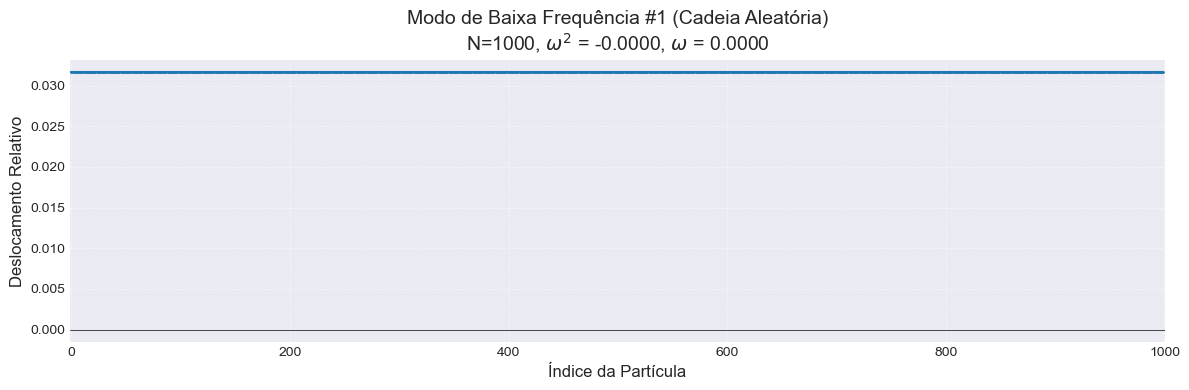

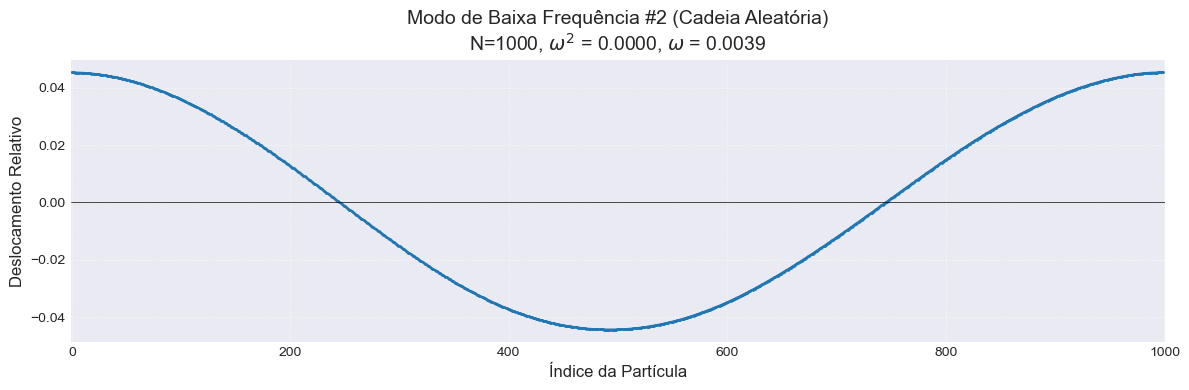

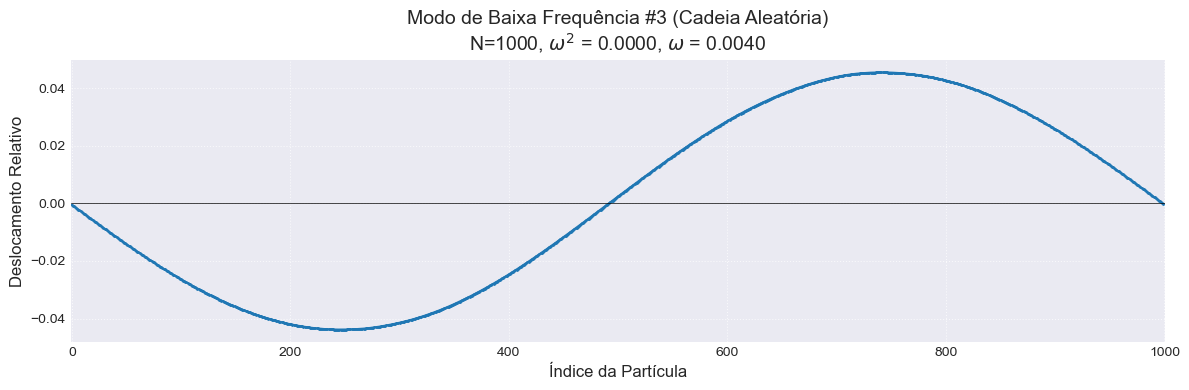

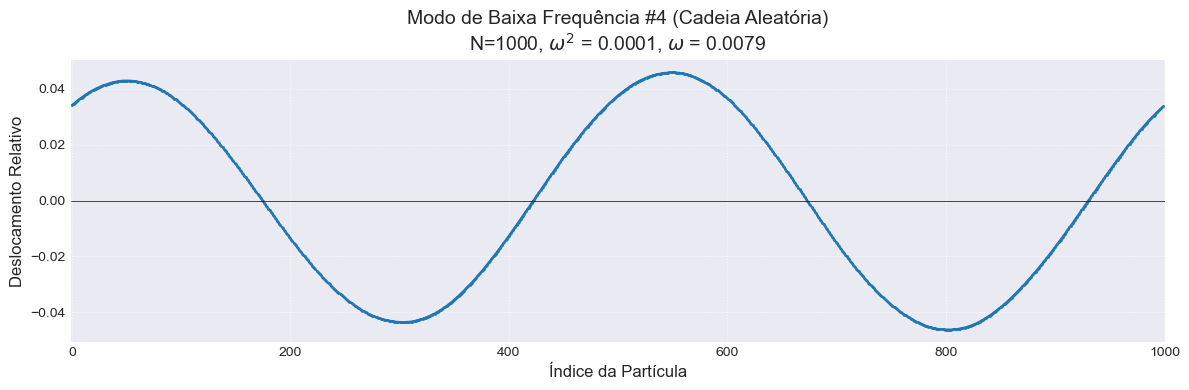

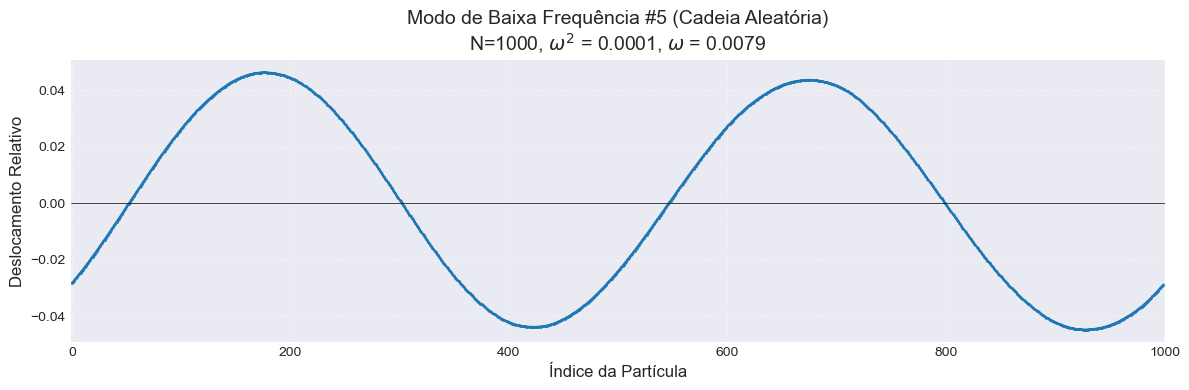


--- Plotando os 5 modos de maior frequência (alta energia) ---


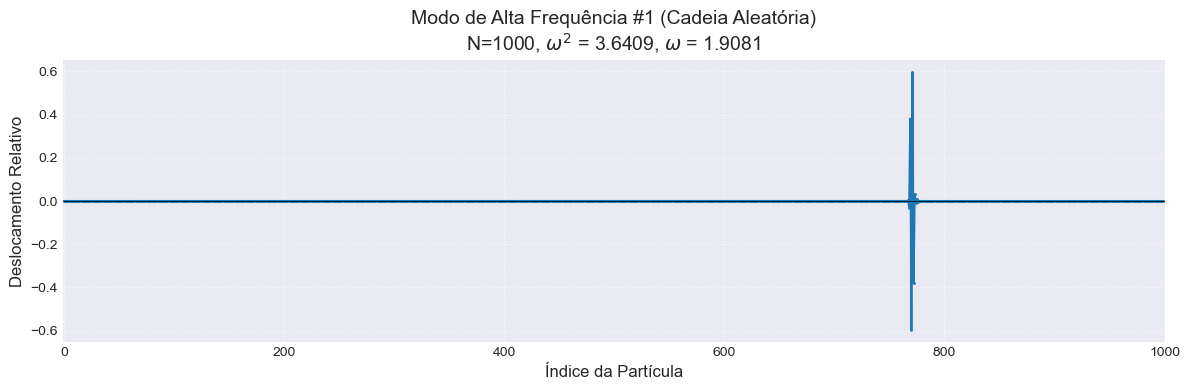

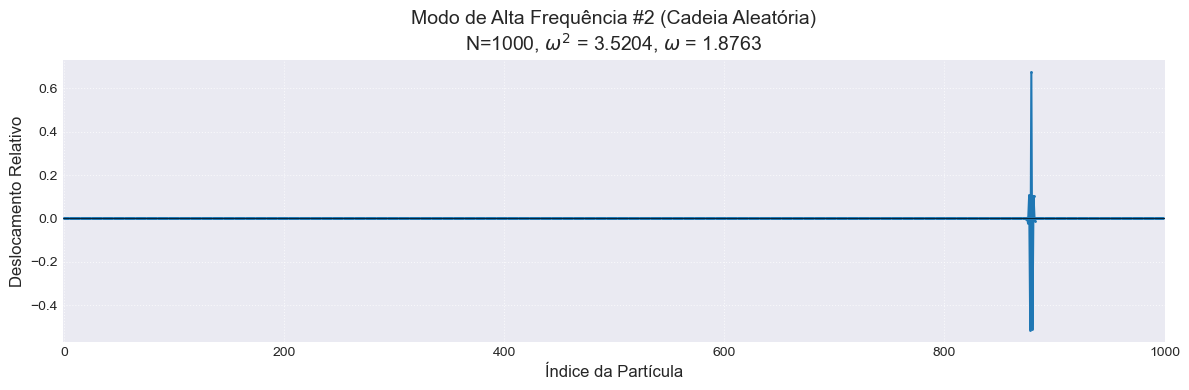

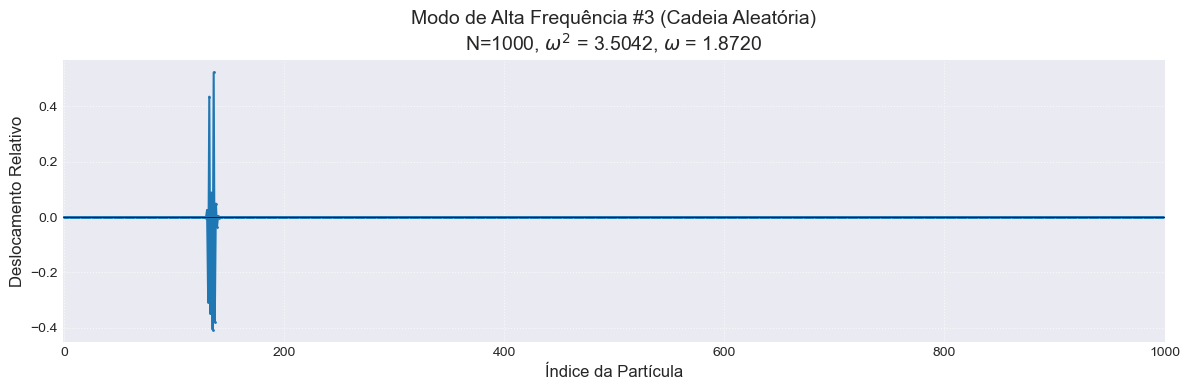

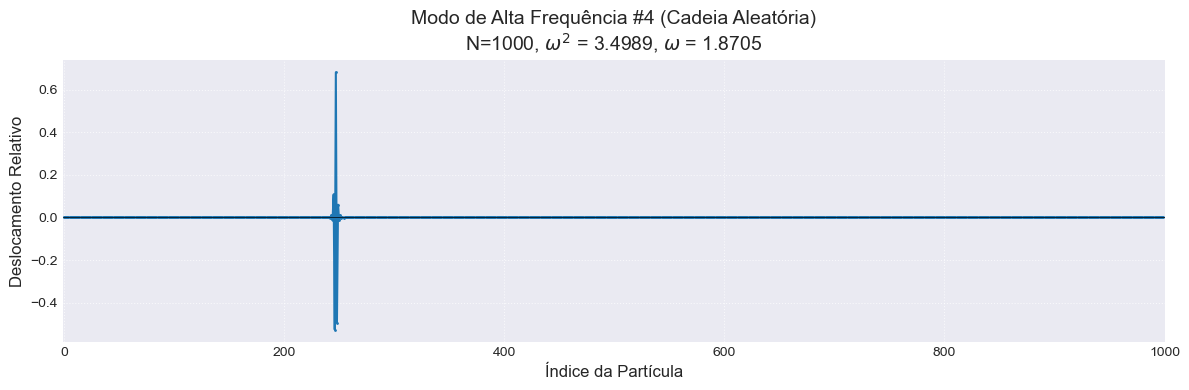

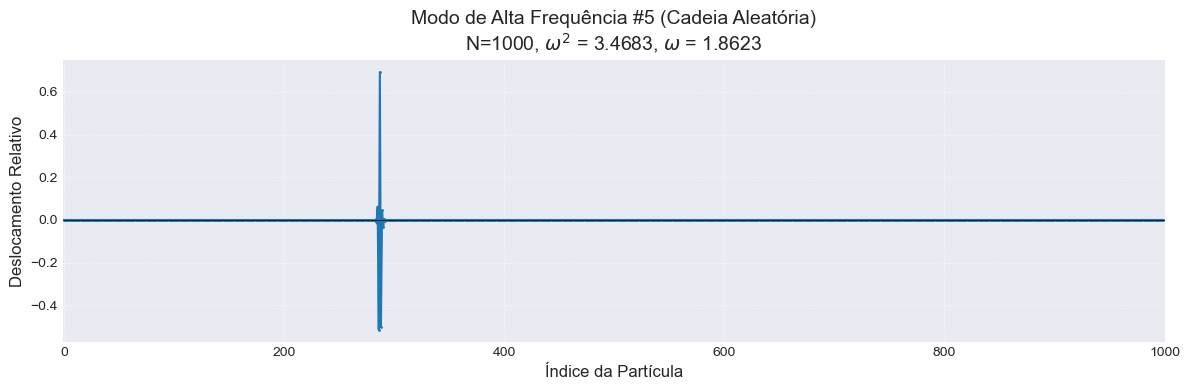

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                            Pode ser um único float (homogênea)
                                            ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- NOVA FUNÇÃO: Para plotar os deslocamentos ---
def plot_normal_mode(mode_vector, omega_squared, mode_rank, N, chain_type, mode_type):
    """
    Plota o deslocamento relativo dos átomos para um modo normal específico.

    Args:
        mode_vector (np.array): O autovetor (modo normal) a ser plotado.
        omega_squared (float): O autovalor (frequência ao quadrado) correspondente.
        mode_rank (int): A ordem do modo (1º, 2º, etc.) para o título.
        N (int): O número de partículas.
        chain_type (str): O tipo de cadeia (ex: 'Aleatória').
        mode_type (str): O tipo de modo (ex: 'Baixa Frequência', 'Alta Frequência').
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(12, 4))
    
    # Plota os deslocamentos usando marcadores e uma linha para conectar
    plt.plot(range(N), mode_vector, '-o', markersize=1, label='Deslocamento')
    
    # Adiciona uma linha horizontal em y=0 como referência
    plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    omega = np.sqrt(omega_squared) if omega_squared > 1e-9 else 0
    title = (f'Modo de {mode_type} #{mode_rank} (Cadeia {chain_type})\n'
             f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')
             
    plt.title(title, fontsize=14)
    plt.xlabel('Índice da Partícula', fontsize=12)
    plt.ylabel('Deslocamento Relativo', fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.xlim(-1, N) # Adiciona um pequeno espaço nas bordas do eixo x
    plt.tight_layout()
    plt.show()


# --- Parâmetros Definidos pelo Usuário ---
# N foi reduzido para uma visualização clara dos modos de deslocamento.
# Com 10.000 partículas, os padrões de onda seriam muito densos para serem vistos.
N_particles = 1000 
k_spring = 1

# --- Escolha o tipo de cadeia para analisar ---
# Cadeia Aleatória
chain_type = "Aleatória"
m_base = 1
np.random.seed(42) # Para reprodutibilidade
mass_value_for_chain = np.random.randint(1, 5, N_particles) * m_base

print(f"Analisando deslocamentos para uma cadeia '{chain_type}' com N={N_particles} partículas.")
print(f"Massas (primeiras 20): {mass_value_for_chain[:20]}...\n")
# -----------------------------------------------------------

# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# --- MODIFICAÇÃO: Obter autovalores E autovetores ---
# A função `eig` retorna os autovalores e os autovetores correspondentes.
# Os autovetores são as colunas da matriz `autovetores`.
autovalores, autovetores = eig(B_matrix)

frequencias_quadrado = autovalores
modos_normais = autovetores

# --- NOVO: Ordenar frequências e modos ---
# `np.argsort` retorna os índices que ordenariam o array de frequências.
sorted_indices = np.argsort(frequencias_quadrado)

# Usa os índices ordenados para reorganizar tanto as frequências quanto os modos normais.
# Isso garante que cada frequência ainda corresponda ao seu modo correto.
sorted_frequencias_quadrado = frequencias_quadrado[sorted_indices]
# As colunas dos autovetores são reordenadas para corresponder às frequências ordenadas.
sorted_modos_normais = modos_normais[:, sorted_indices]

# --- Apresentação dos Gráficos de Deslocamento ---

# 1. Plota os 5 modos de MENOR frequência
print("--- Plotando os 5 modos de menor frequência (baixa energia) ---")
for i in range(5):
    # O modo i-ésimo menor corresponde à i-ésima coluna dos vetores ordenados
    mode_vector = sorted_modos_normais[:, i]
    omega_sq = sorted_frequencias_quadrado[i]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Baixa Frequência")

# 2. Plota os 5 modos de MAIOR frequência
print("\n--- Plotando os 5 modos de maior frequência (alta energia) ---")
for i in range(5):
    # O i-ésimo modo maior está no final do array ordenado.
    # Usamos indexação negativa: -1 para o último, -2 para o penúltimo, etc.
    mode_index_from_end = - (i + 1)
    mode_vector = sorted_modos_normais[:, mode_index_from_end]
    omega_sq = sorted_frequencias_quadrado[mode_index_from_end]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Alta Frequência")

<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_15608\3018246396.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_15608\3018246396.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')


Analisando deslocamentos para uma cadeia 'Aleatória' com N=10000 partículas.
Massas (primeiras 20): [3 4 1 3 3 4 1 1 3 2 3 3 3 3 4 1 4 4 4 3]...

--- Plotando os 5 modos de menor frequência (baixa energia) ---


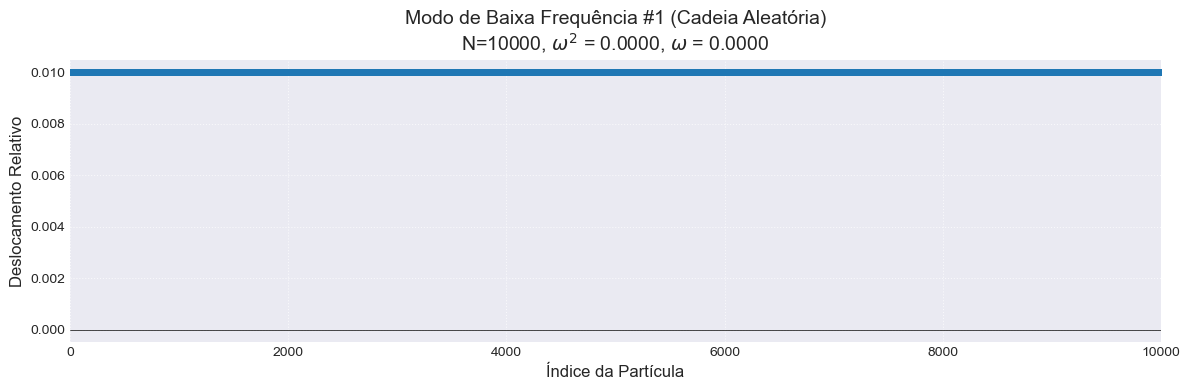

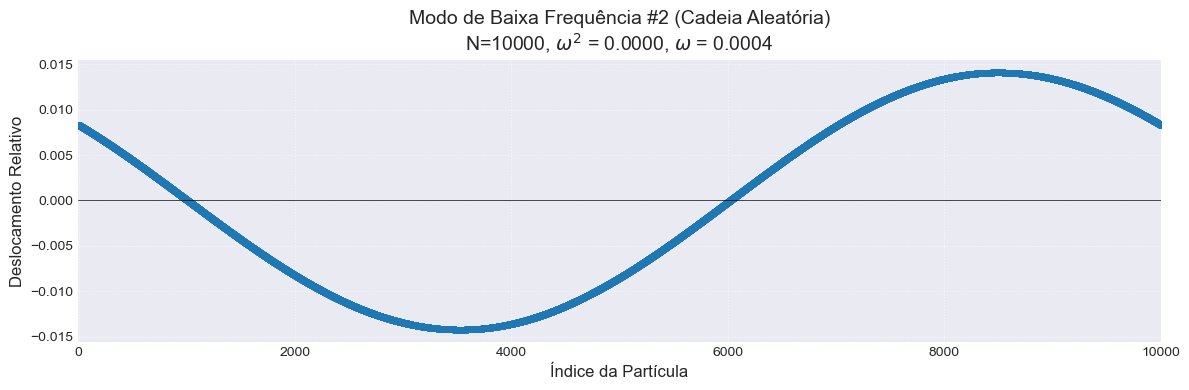

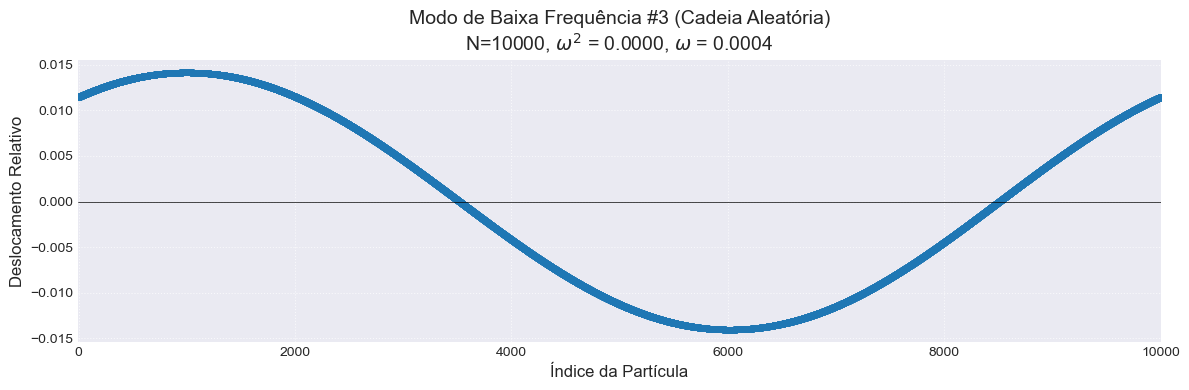

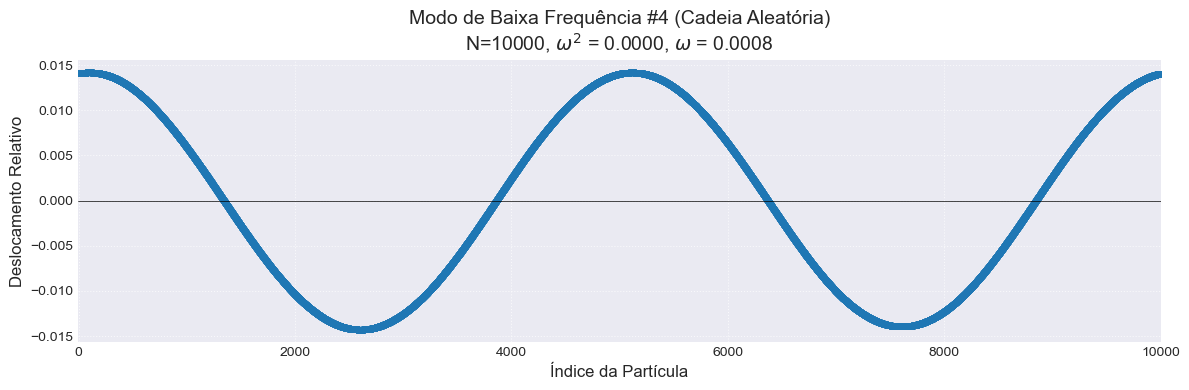

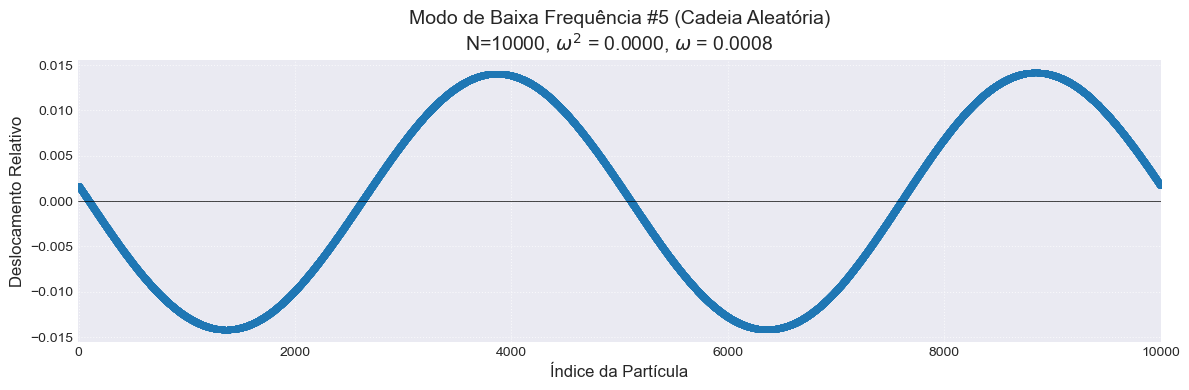


--- Plotando os 5 modos de maior frequência (alta energia) ---


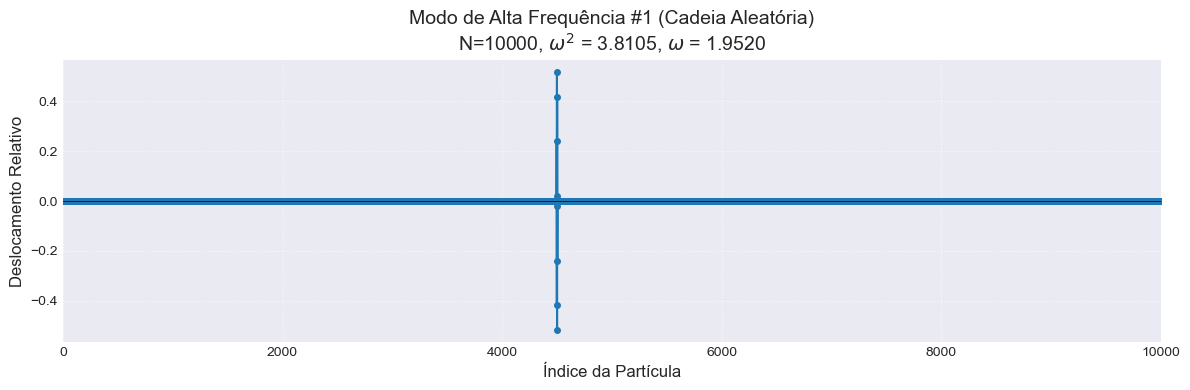

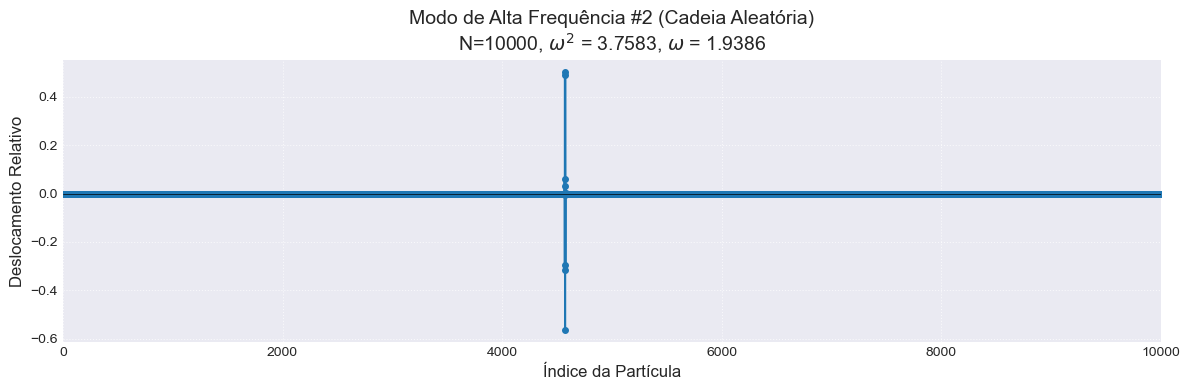

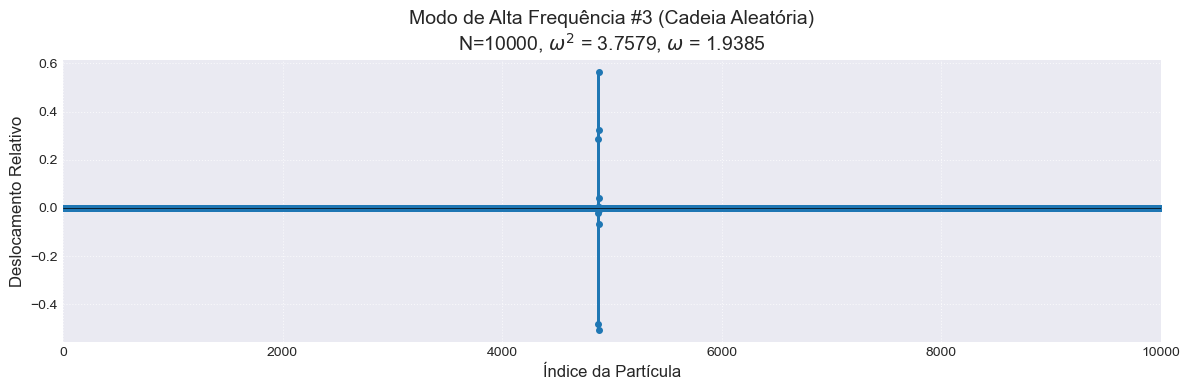

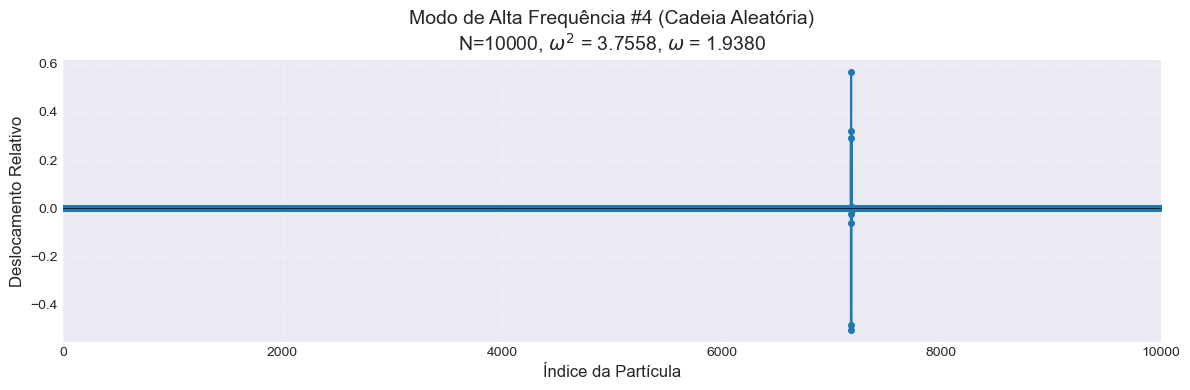

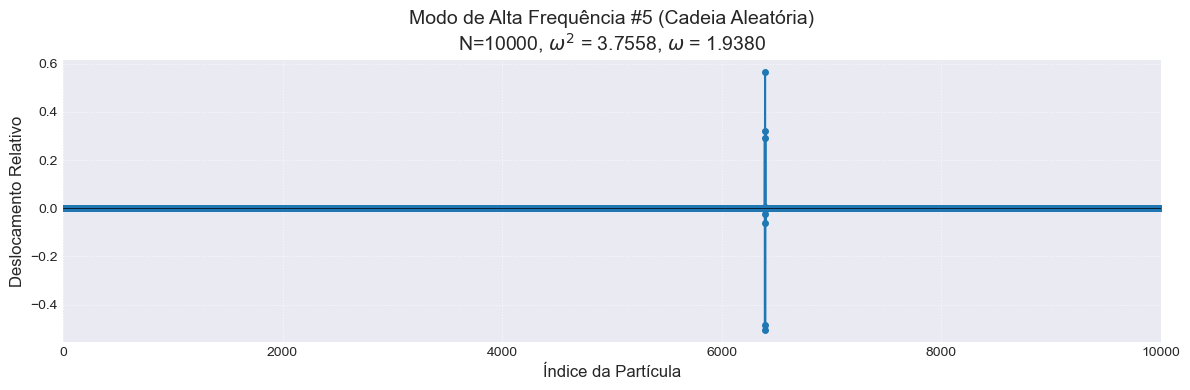

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                            Pode ser um único float (homogênea)
                                            ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- NOVA FUNÇÃO: Para plotar os deslocamentos ---
def plot_normal_mode(mode_vector, omega_squared, mode_rank, N, chain_type, mode_type):
    """
    Plota o deslocamento relativo dos átomos para um modo normal específico.

    Args:
        mode_vector (np.array): O autovetor (modo normal) a ser plotado.
        omega_squared (float): O autovalor (frequência ao quadrado) correspondente.
        mode_rank (int): A ordem do modo (1º, 2º, etc.) para o título.
        N (int): O número de partículas.
        chain_type (str): O tipo de cadeia (ex: 'Aleatória').
        mode_type (str): O tipo de modo (ex: 'Baixa Frequência', 'Alta Frequência').
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(12, 4))
    
    # Plota os deslocamentos usando marcadores e uma linha para conectar
    plt.plot(range(N), mode_vector, '-o', markersize=4, label='Deslocamento')
    
    # Adiciona uma linha horizontal em y=0 como referência
    plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    omega = np.sqrt(omega_squared) if omega_squared > 1e-9 else 0
    title = (f'Modo de {mode_type} #{mode_rank} (Cadeia {chain_type})\n'
             f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')
             
    plt.title(title, fontsize=14)
    plt.xlabel('Índice da Partícula', fontsize=12)
    plt.ylabel('Deslocamento Relativo', fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.xlim(-1, N) # Adiciona um pequeno espaço nas bordas do eixo x
    plt.tight_layout()
    plt.show()


# --- Parâmetros Definidos pelo Usuário ---
# N foi reduzido para uma visualização clara dos modos de deslocamento.
# Com 10.000 partículas, os padrões de onda seriam muito densos para serem vistos.
N_particles = 10000 
k_spring = 1

# --- Escolha o tipo de cadeia para analisar ---
# Cadeia Aleatória
chain_type = "Aleatória"
m_base = 1
np.random.seed(42) # Para reprodutibilidade
mass_value_for_chain = np.random.randint(1, 5, N_particles) * m_base

print(f"Analisando deslocamentos para uma cadeia '{chain_type}' com N={N_particles} partículas.")
print(f"Massas (primeiras 20): {mass_value_for_chain[:20]}...\n")
# -----------------------------------------------------------

# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# --- MODIFICAÇÃO: Obter autovalores E autovetores ---
# A função `eig` retorna os autovalores e os autovetores correspondentes.
# Os autovetores são as colunas da matriz `autovetores`.
autovalores, autovetores = eig(B_matrix)

frequencias_quadrado = autovalores
modos_normais = autovetores

# --- NOVO: Ordenar frequências e modos ---
# `np.argsort` retorna os índices que ordenariam o array de frequências.
sorted_indices = np.argsort(frequencias_quadrado)

# Usa os índices ordenados para reorganizar tanto as frequências quanto os modos normais.
# Isso garante que cada frequência ainda corresponda ao seu modo correto.
sorted_frequencias_quadrado = frequencias_quadrado[sorted_indices]
# As colunas dos autovetores são reordenadas para corresponder às frequências ordenadas.
sorted_modos_normais = modos_normais[:, sorted_indices]

# --- Apresentação dos Gráficos de Deslocamento ---

# 1. Plota os 5 modos de MENOR frequência
print("--- Plotando os 5 modos de menor frequência (baixa energia) ---")
for i in range(5):
    # O modo i-ésimo menor corresponde à i-ésima coluna dos vetores ordenados
    mode_vector = sorted_modos_normais[:, i]
    omega_sq = sorted_frequencias_quadrado[i]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Baixa Frequência")

# 2. Plota os 5 modos de MAIOR frequência
print("\n--- Plotando os 5 modos de maior frequência (alta energia) ---")
for i in range(5):
    # O i-ésimo modo maior está no final do array ordenado.
    # Usamos indexação negativa: -1 para o último, -2 para o penúltimo, etc.
    mode_index_from_end = - (i + 1)
    mode_vector = sorted_modos_normais[:, mode_index_from_end]
    omega_sq = sorted_frequencias_quadrado[mode_index_from_end]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Alta Frequência")

### Análise

Obseve que o comportamento em baixas energias é ondulatório, enquanto o comportamento de altas energias é indivídual. Ao analizarmos, dizemos que há uma oscilação no entorno do "modo normal" de uma única partícula, o que induz a ideia da anarmofia destrói o comportamento ondulatório da cadeia. No ponto de vista da análise de Fourier, o gráfico do espaço recíproco deve ser uma onda que oscila com a frequência fundamental do átomo, ou seja, descreve o seu movimento em função do tempo.

<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\2933257250.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\2933257250.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')


Analisando deslocamentos para uma cadeia 'Homogenea' com N=100 partículas.
Massas (primeiras 20): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]...

--- Plotando os 5 modos de menor frequência (baixa energia) ---


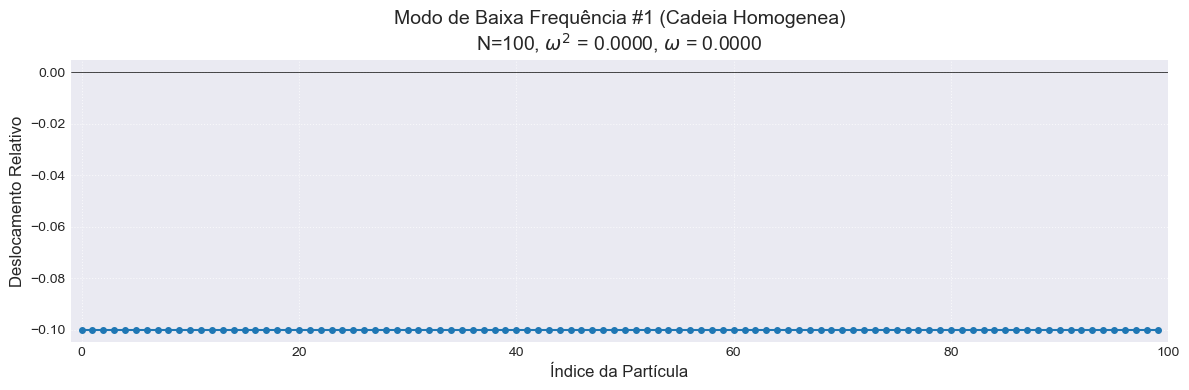

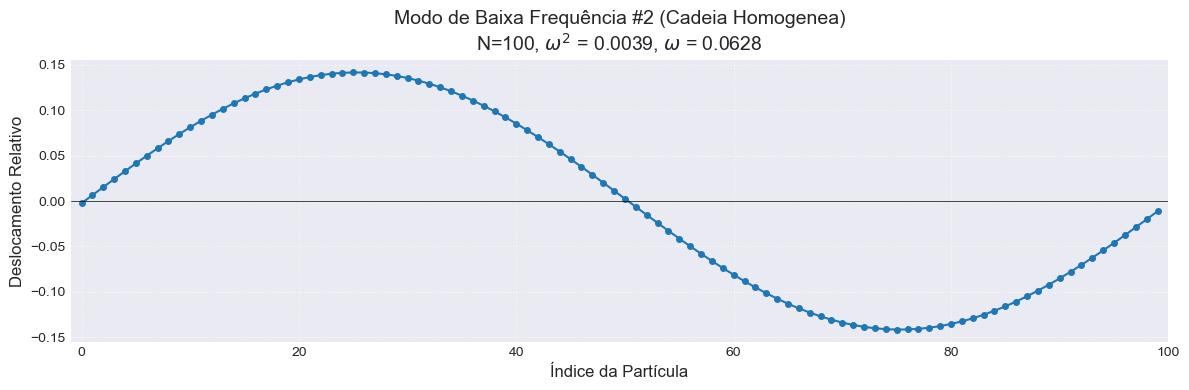

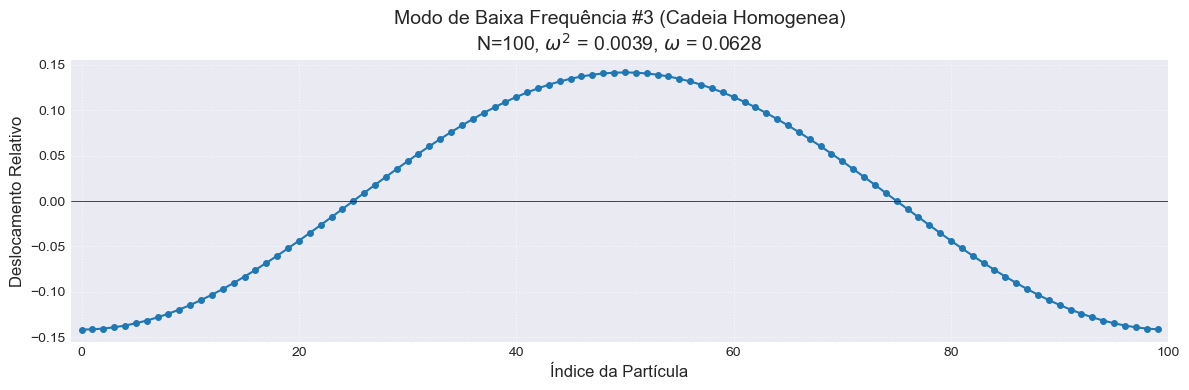

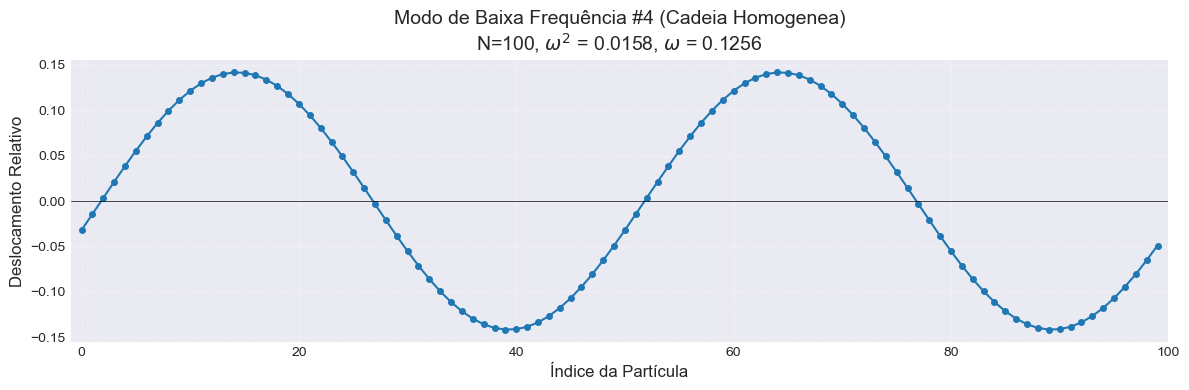

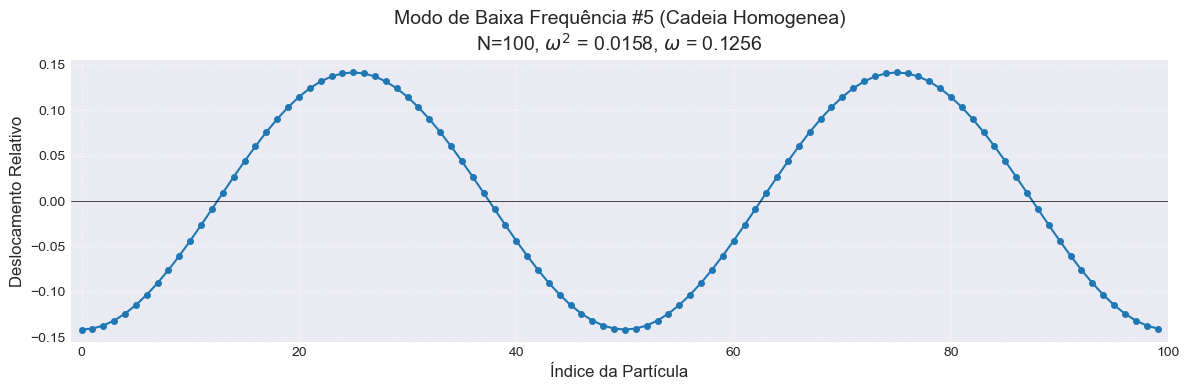


--- Plotando os 5 modos de maior frequência (alta energia) ---


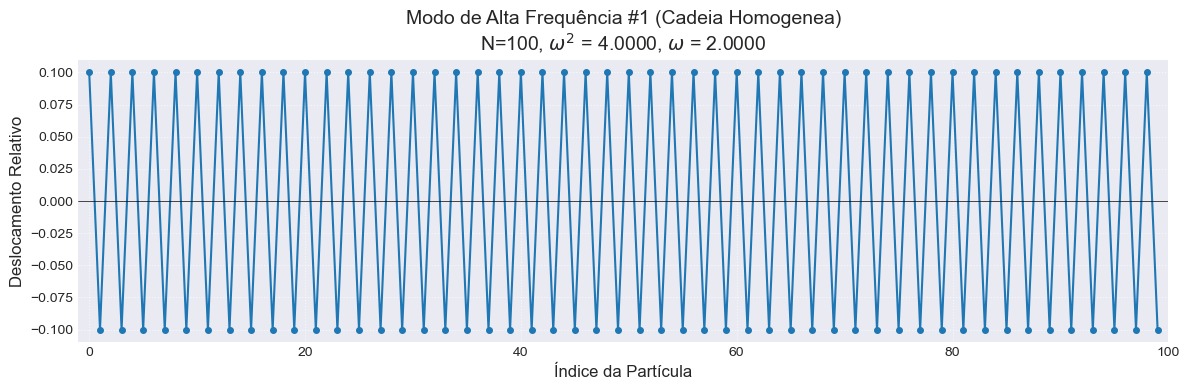

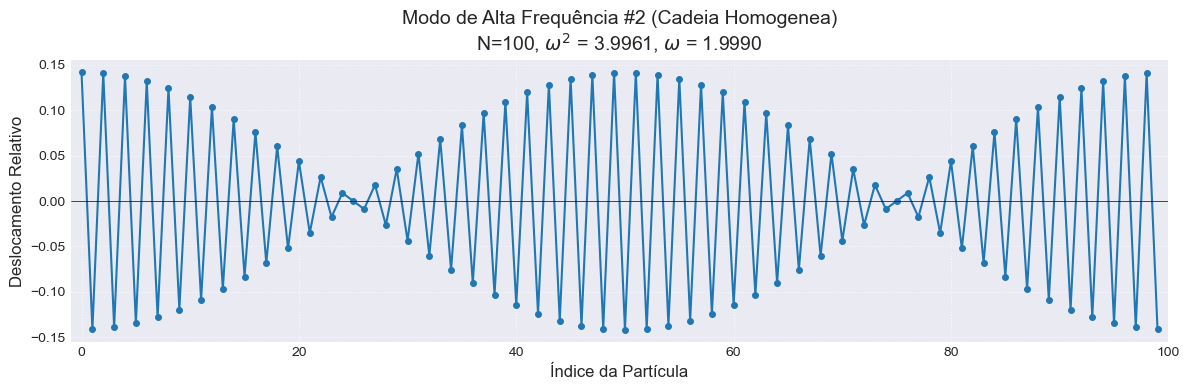

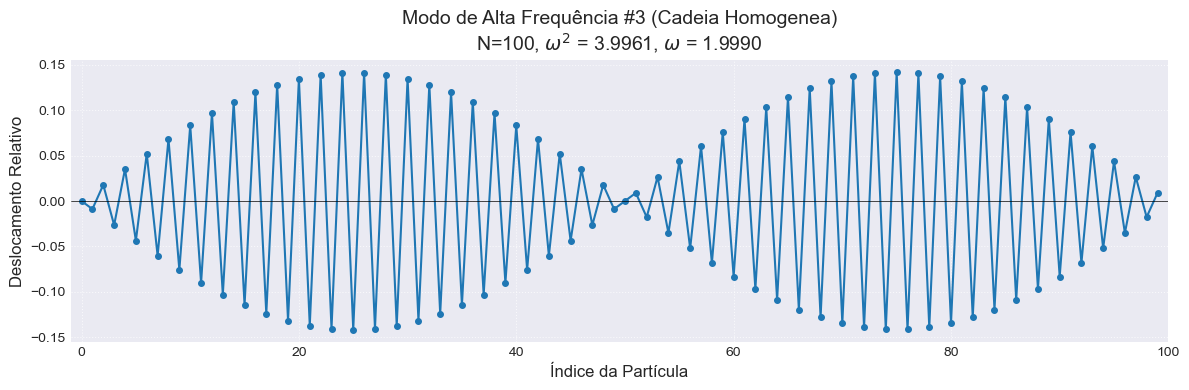

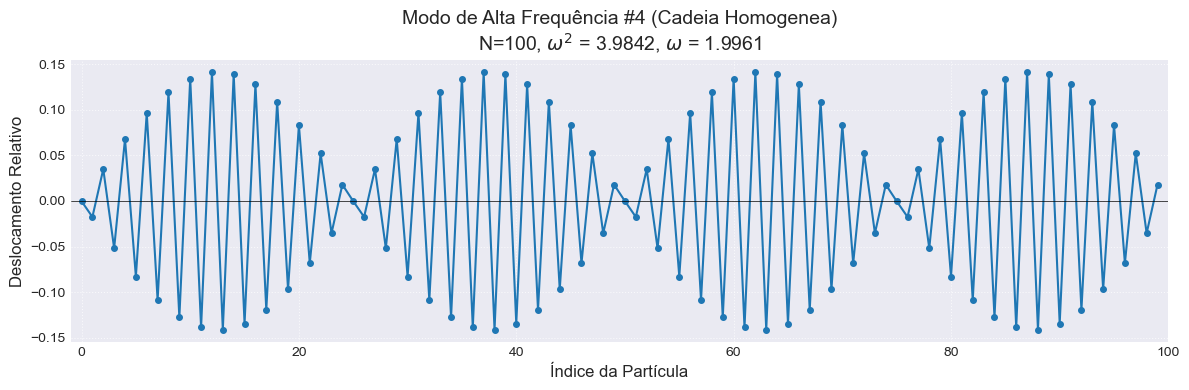

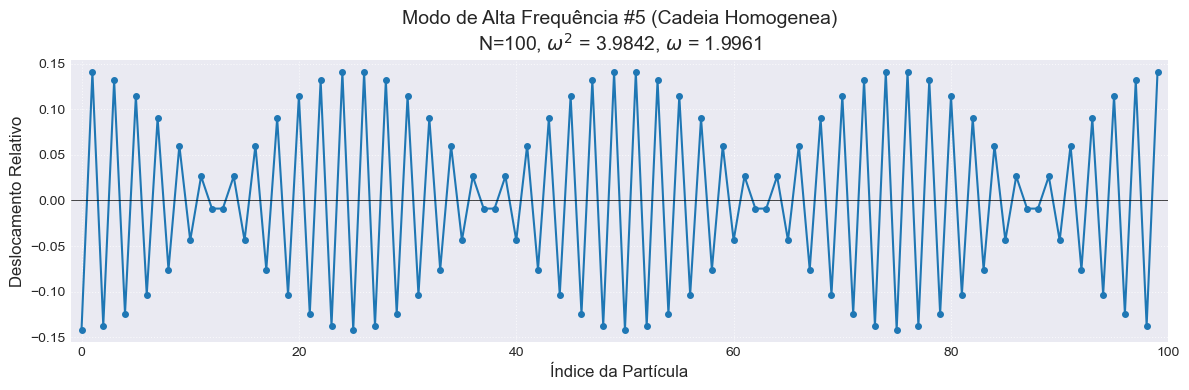

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                            Pode ser um único float (homogênea)
                                            ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- NOVA FUNÇÃO: Para plotar os deslocamentos ---
def plot_normal_mode(mode_vector, omega_squared, mode_rank, N, chain_type, mode_type):
    """
    Plota o deslocamento relativo dos átomos para um modo normal específico.

    Args:
        mode_vector (np.array): O autovetor (modo normal) a ser plotado.
        omega_squared (float): O autovalor (frequência ao quadrado) correspondente.
        mode_rank (int): A ordem do modo (1º, 2º, etc.) para o título.
        N (int): O número de partículas.
        chain_type (str): O tipo de cadeia (ex: 'Aleatória').
        mode_type (str): O tipo de modo (ex: 'Baixa Frequência', 'Alta Frequência').
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(12, 4))
    
    # Plota os deslocamentos usando marcadores e uma linha para conectar
    plt.plot(range(N), mode_vector, '-o', markersize=4, label='Deslocamento')
    
    # Adiciona uma linha horizontal em y=0 como referência
    plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    omega = np.sqrt(omega_squared) if omega_squared > 1e-9 else 0
    title = (f'Modo de {mode_type} #{mode_rank} (Cadeia {chain_type})\n'
             f'N={N}, $\omega^2$ = {omega_squared:.4f}, $\omega$ = {omega:.4f}')
             
    plt.title(title, fontsize=14)
    plt.xlabel('Índice da Partícula', fontsize=12)
    plt.ylabel('Deslocamento Relativo', fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.xlim(-1, N) # Adiciona um pequeno espaço nas bordas do eixo x
    plt.tight_layout()
    plt.show()


# --- Parâmetros Definidos pelo Usuário ---
# N foi reduzido para uma visualização clara dos modos de deslocamento.
# Com 10.000 partículas, os padrões de onda seriam muito densos para serem vistos.
N_particles = 100 
k_spring = 1

# --- Escolha o tipo de cadeia para analisar ---
chain_type = "Homogenea"
m_base = 1
mass_value_for_chain = np.full(N_particles, m_base)

print(f"Analisando deslocamentos para uma cadeia '{chain_type}' com N={N_particles} partículas.")
print(f"Massas (primeiras 20): {mass_value_for_chain[:20]}...\n")
# -----------------------------------------------------------

# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# --- MODIFICAÇÃO: Obter autovalores E autovetores ---
# A função `eig` retorna os autovalores e os autovetores correspondentes.
# Os autovetores são as colunas da matriz `autovetores`.
autovalores, autovetores = eig(B_matrix)

frequencias_quadrado = autovalores
modos_normais = autovetores

# --- NOVO: Ordenar frequências e modos ---
# `np.argsort` retorna os índices que ordenariam o array de frequências.
sorted_indices = np.argsort(frequencias_quadrado)

# Usa os índices ordenados para reorganizar tanto as frequências quanto os modos normais.
# Isso garante que cada frequência ainda corresponda ao seu modo correto.
sorted_frequencias_quadrado = frequencias_quadrado[sorted_indices]
# As colunas dos autovetores são reordenadas para corresponder às frequências ordenadas.
sorted_modos_normais = modos_normais[:, sorted_indices]

# --- Apresentação dos Gráficos de Deslocamento ---

# 1. Plota os 5 modos de MENOR frequência
print("--- Plotando os 5 modos de menor frequência (baixa energia) ---")
for i in range(5):
    # O modo i-ésimo menor corresponde à i-ésima coluna dos vetores ordenados
    mode_vector = sorted_modos_normais[:, i]
    omega_sq = sorted_frequencias_quadrado[i]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Baixa Frequência")

# 2. Plota os 5 modos de MAIOR frequência
print("\n--- Plotando os 5 modos de maior frequência (alta energia) ---")
for i in range(5):
    # O i-ésimo modo maior está no final do array ordenado.
    # Usamos indexação negativa: -1 para o último, -2 para o penúltimo, etc.
    mode_index_from_end = - (i + 1)
    mode_vector = sorted_modos_normais[:, mode_index_from_end]
    omega_sq = sorted_frequencias_quadrado[mode_index_from_end]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Alta Frequência")

<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\1086380252.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.5f}, $\omega$ = {omega:.4f}')
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\1086380252.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.5f}, $\omega$ = {omega:.4f}')


Analisando deslocamentos para uma cadeia 'Homogenea' com N=1000 partículas.
Massas (primeiras 20): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]...

--- Plotando os 5 modos de menor frequência (baixa energia) ---


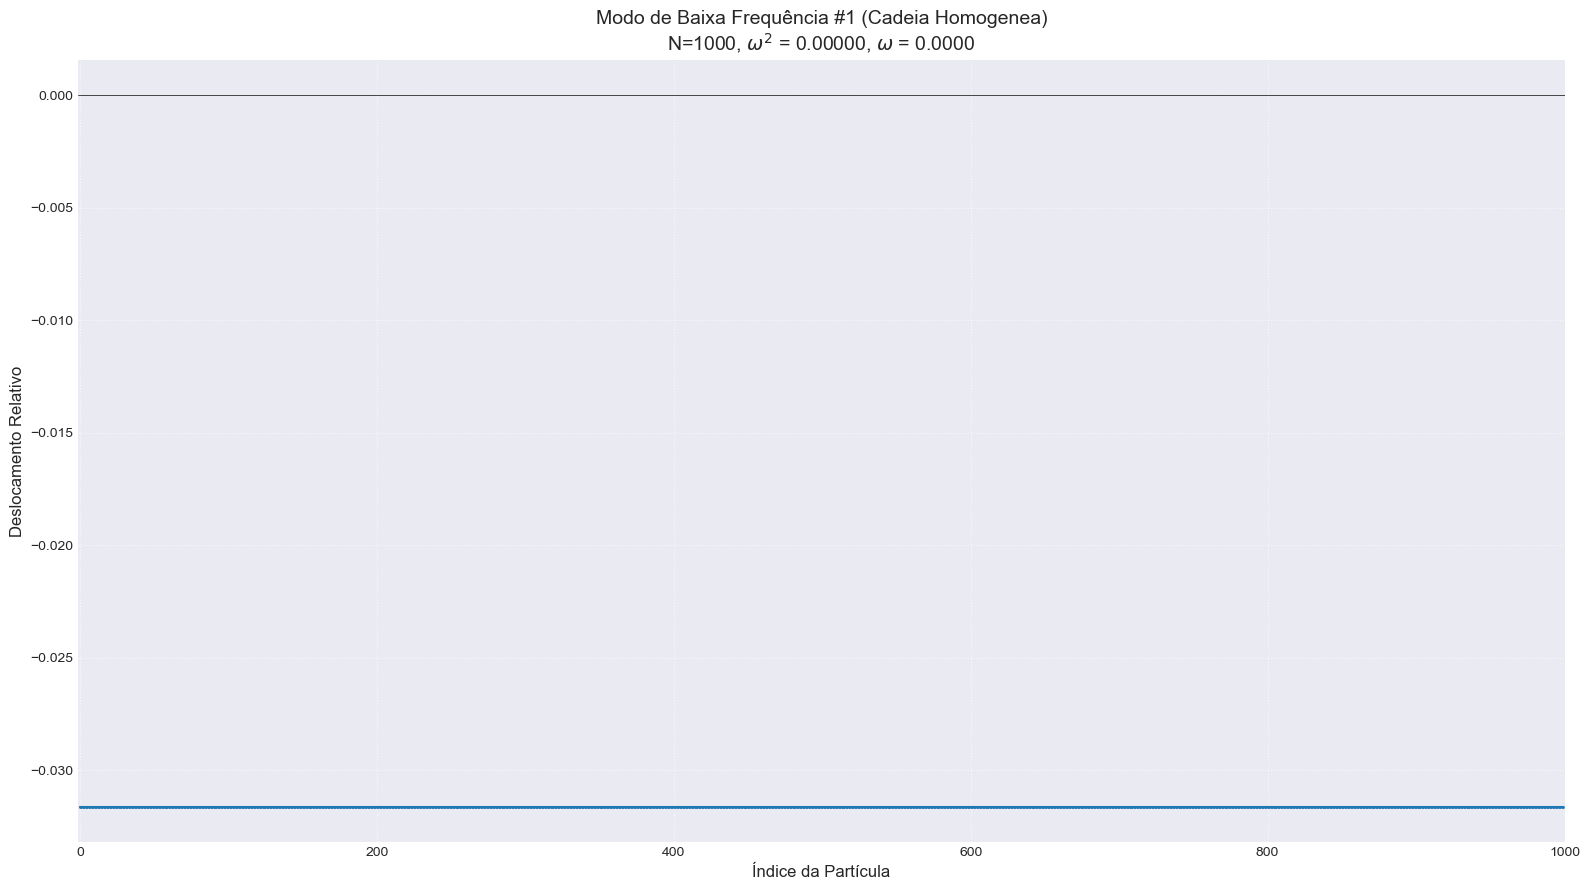

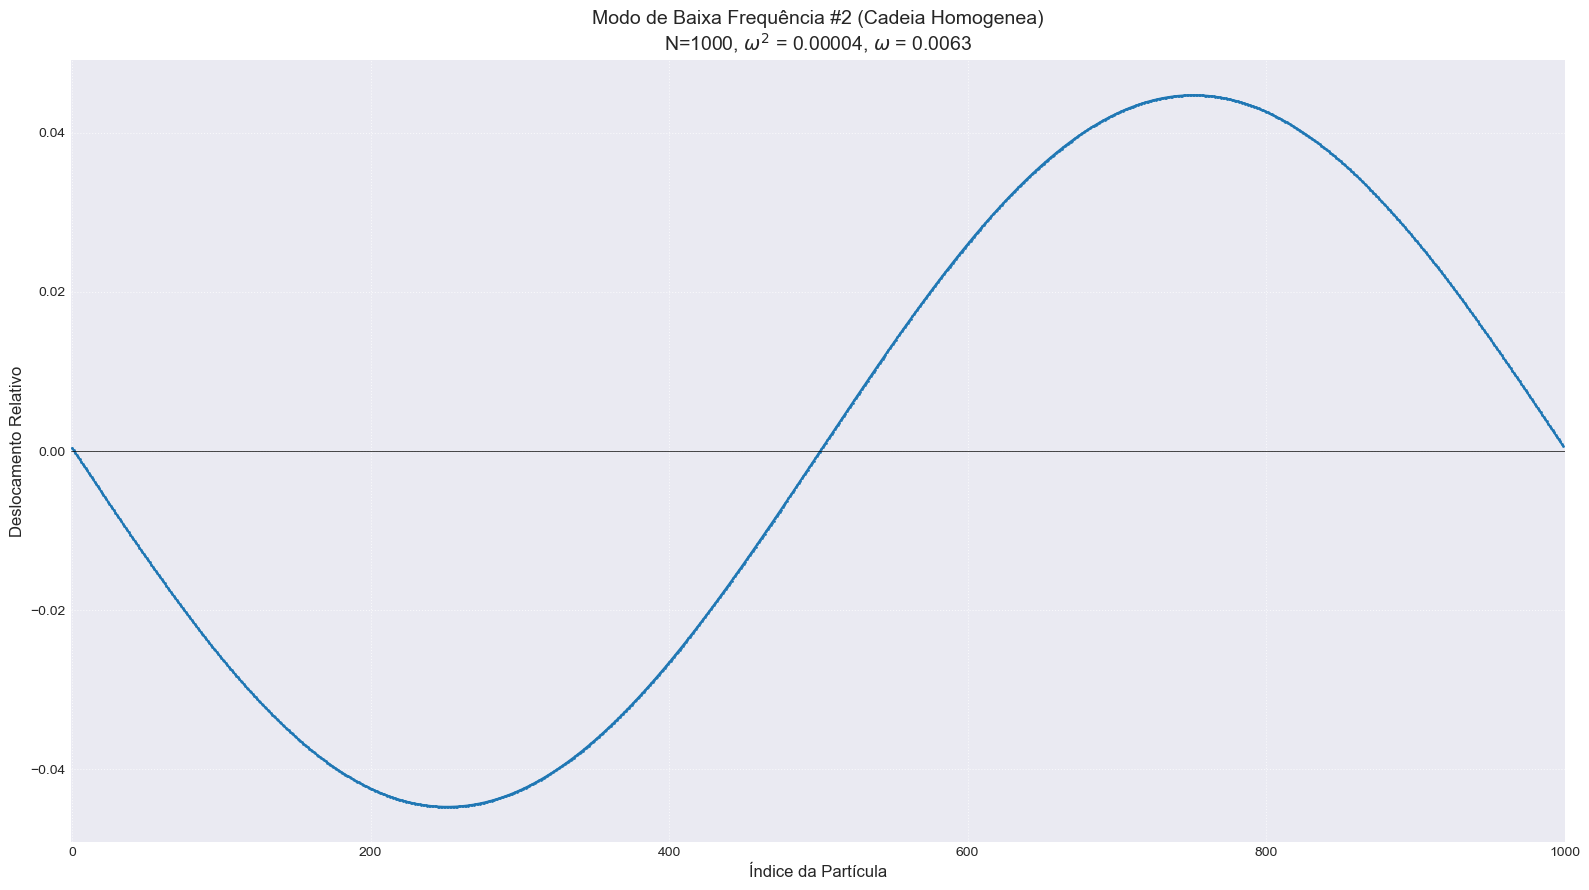

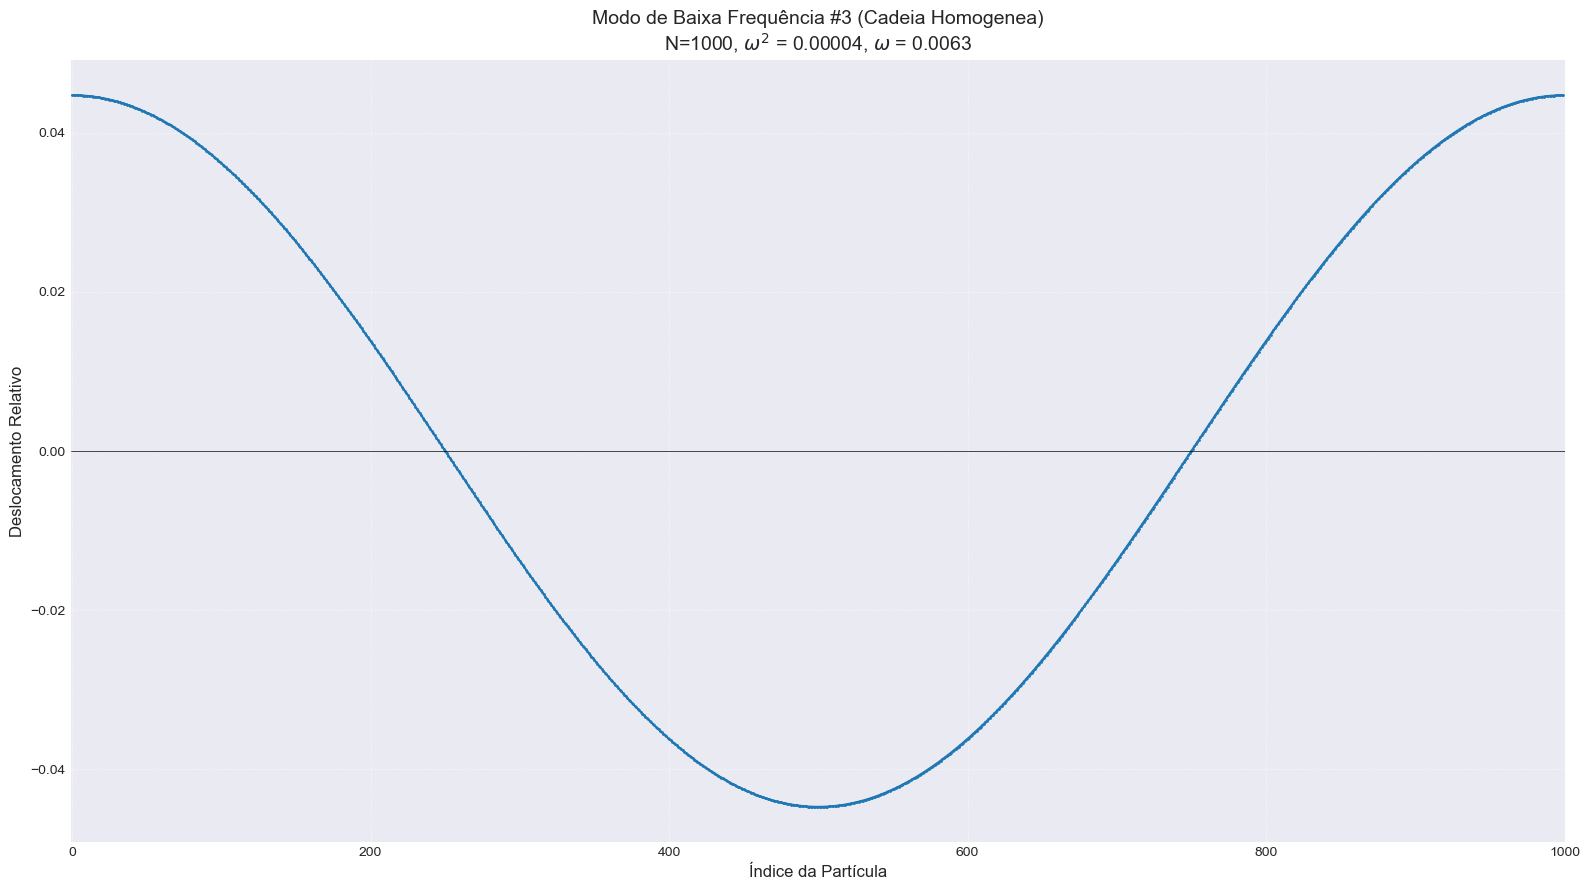

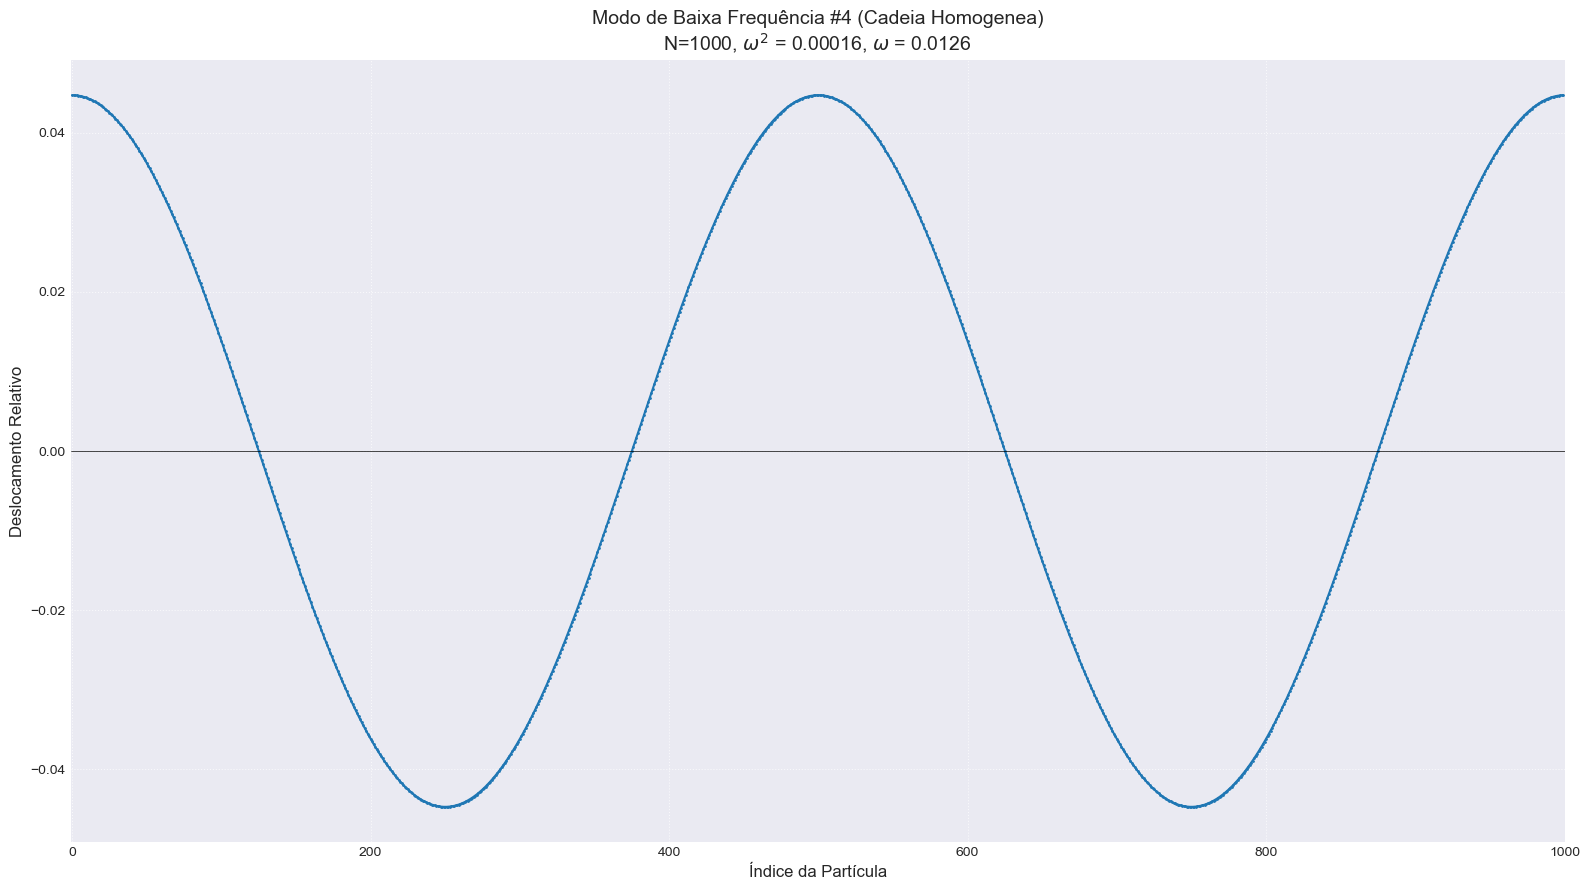

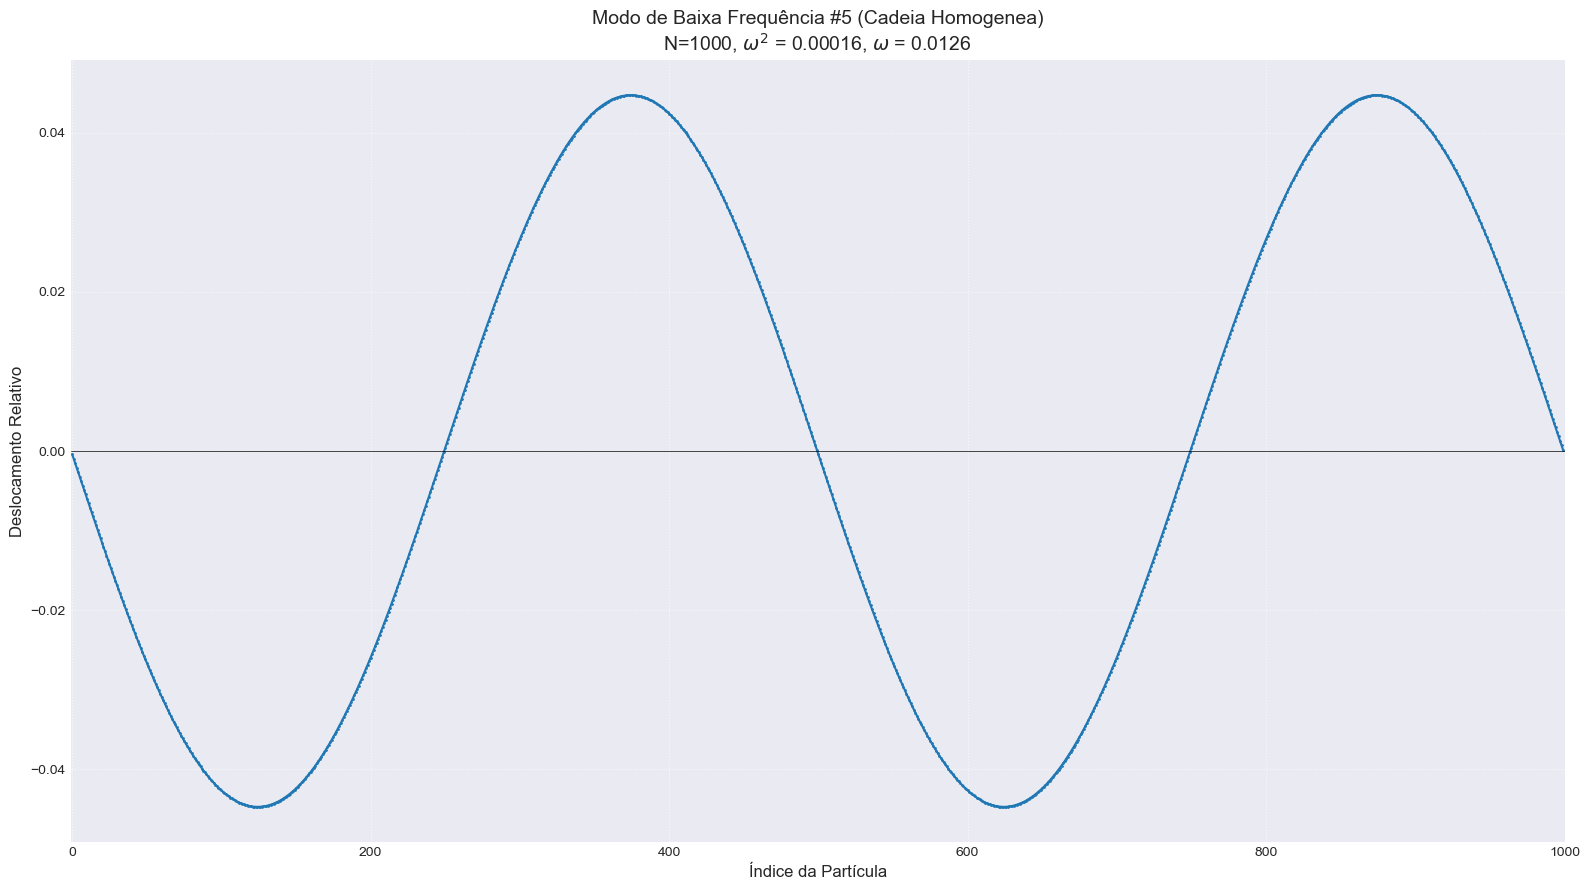


--- Plotando os 5 modos de maior frequência (alta energia) ---


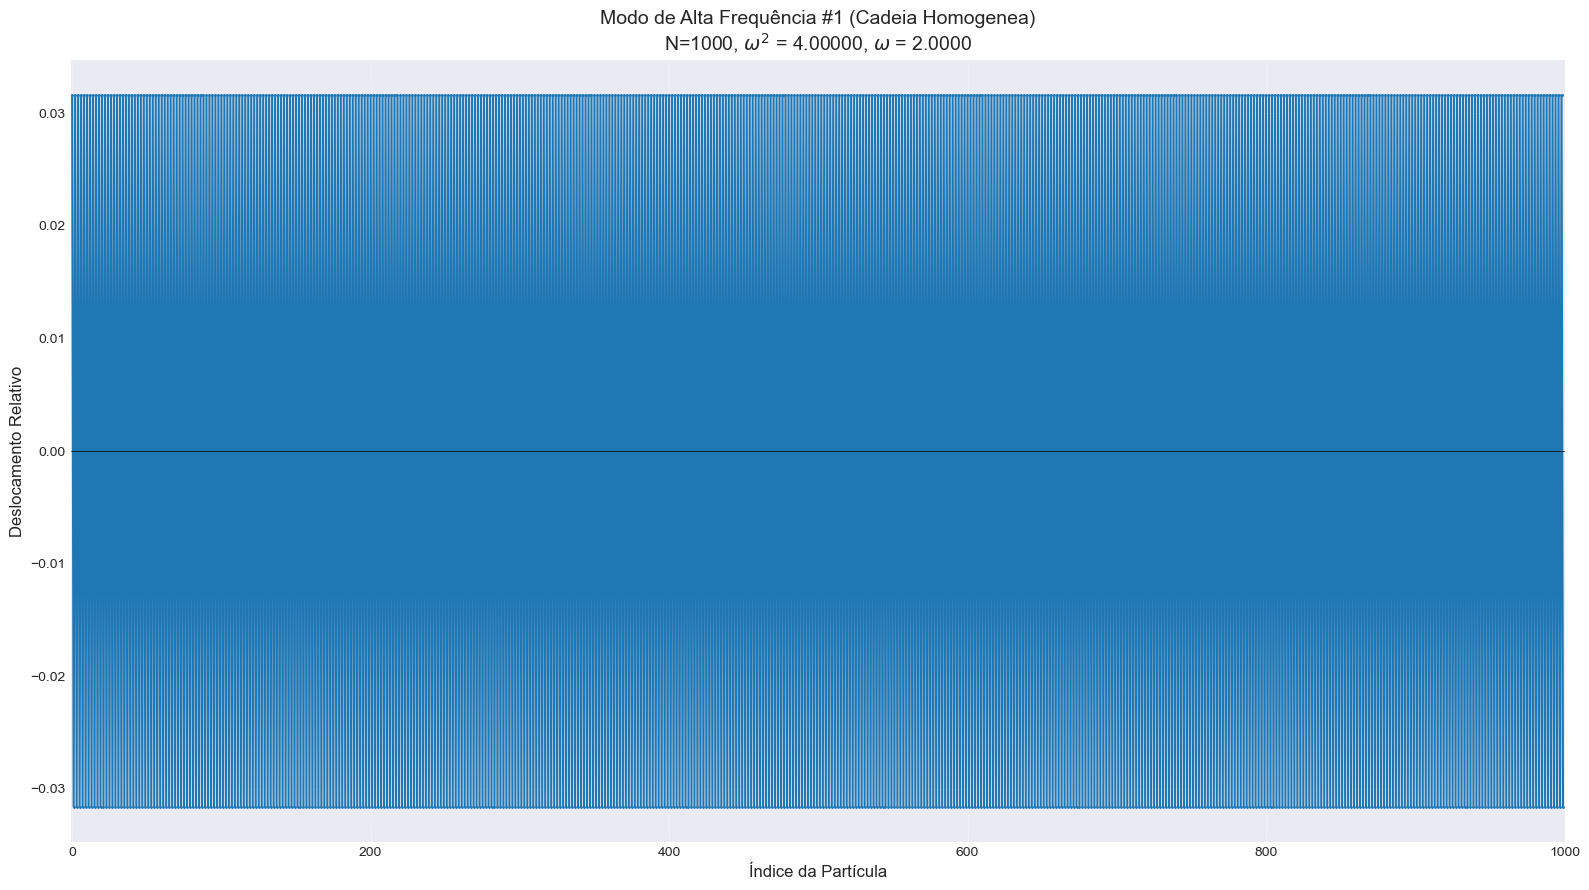

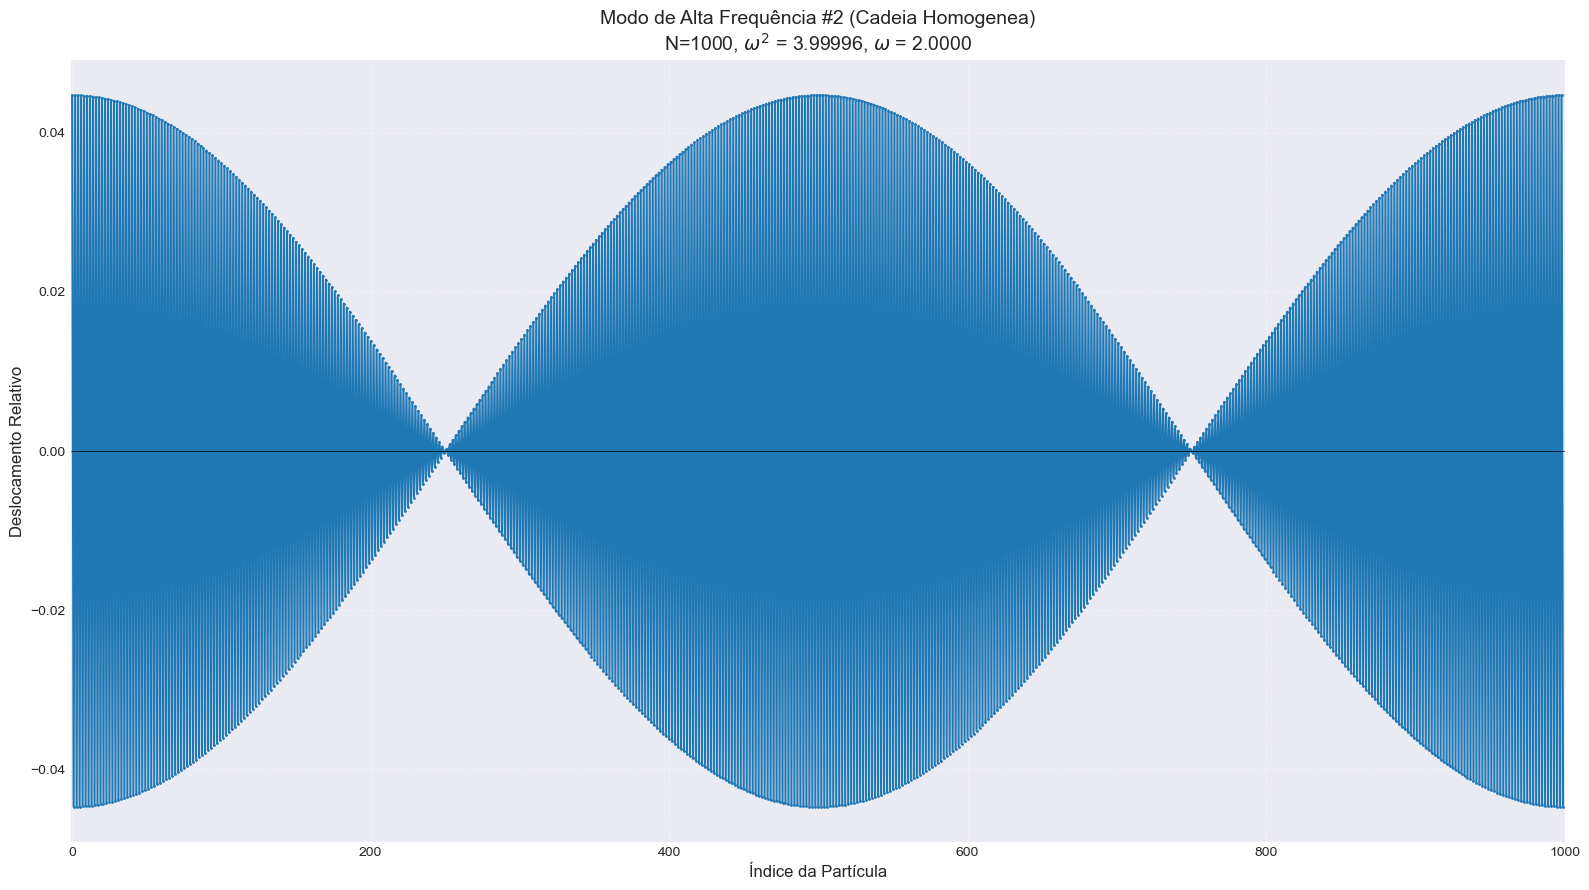

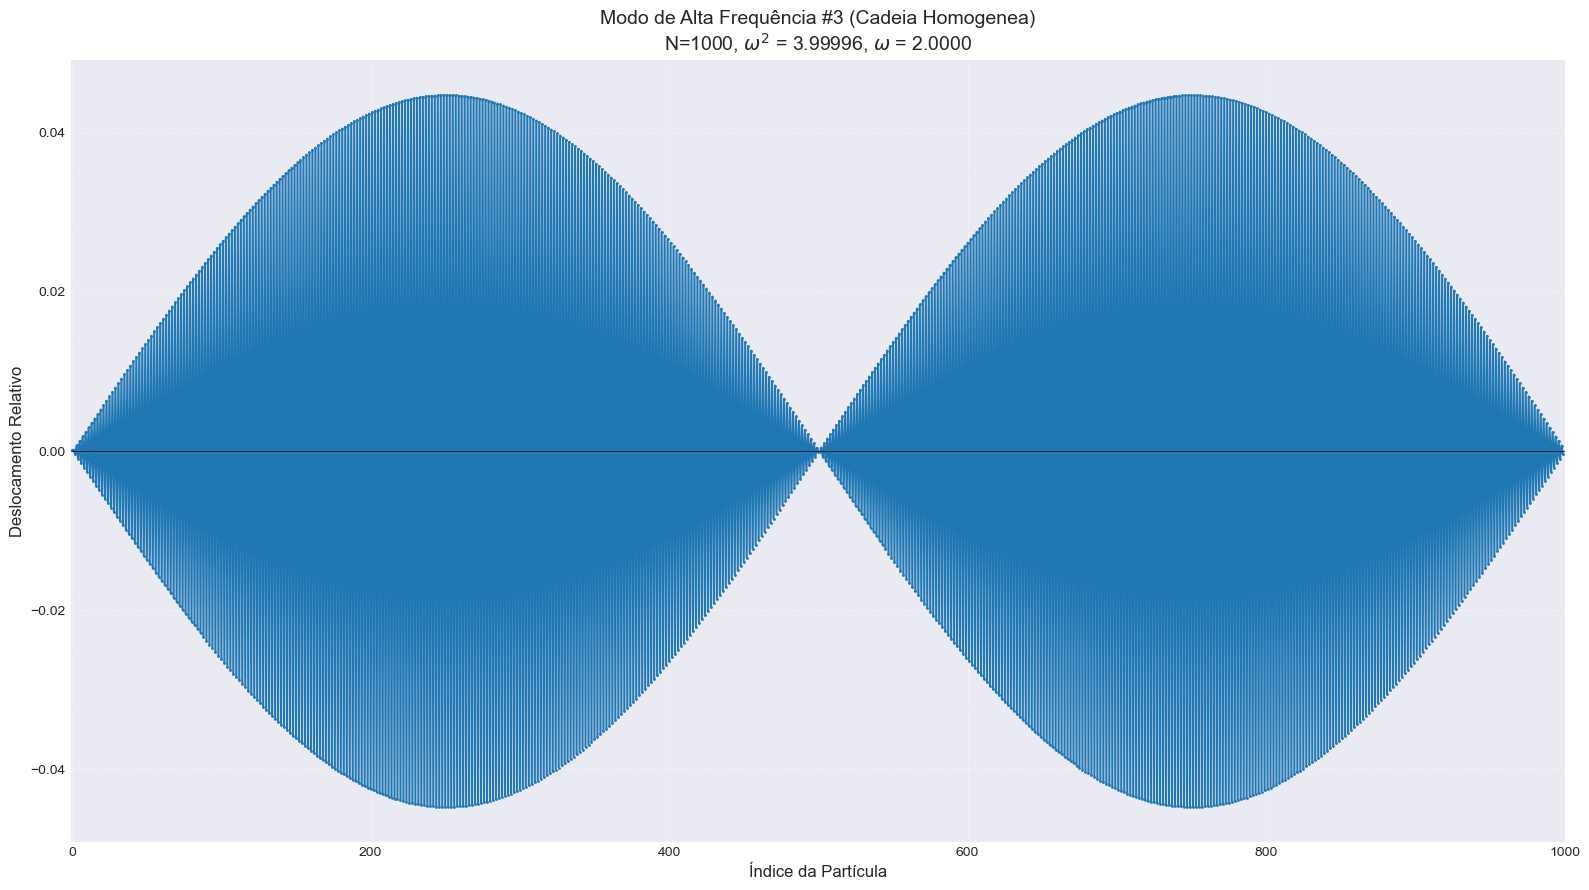

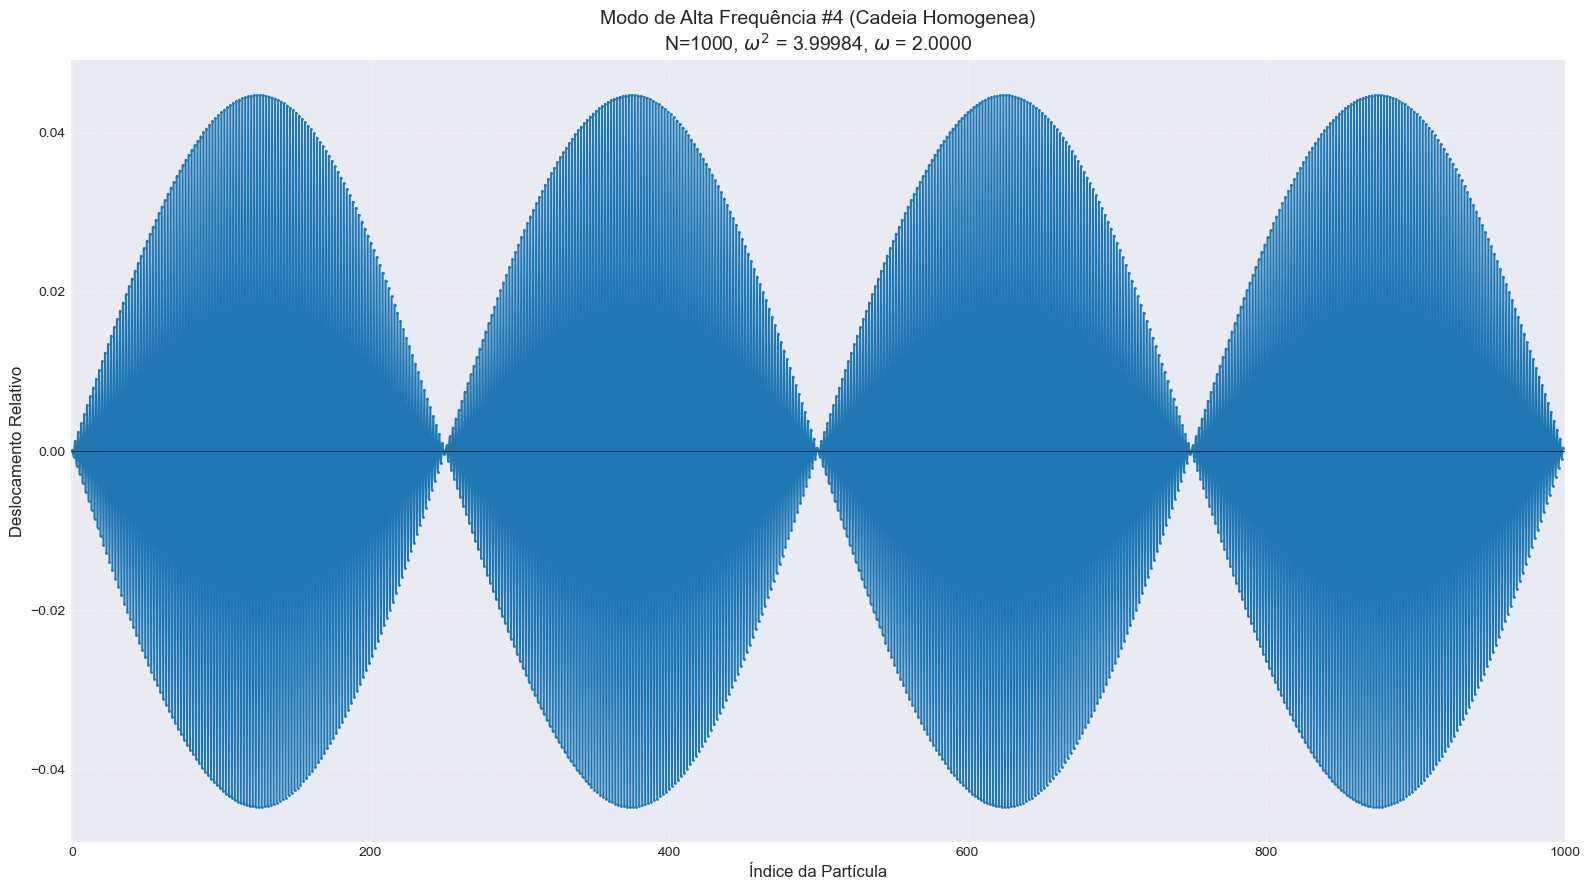

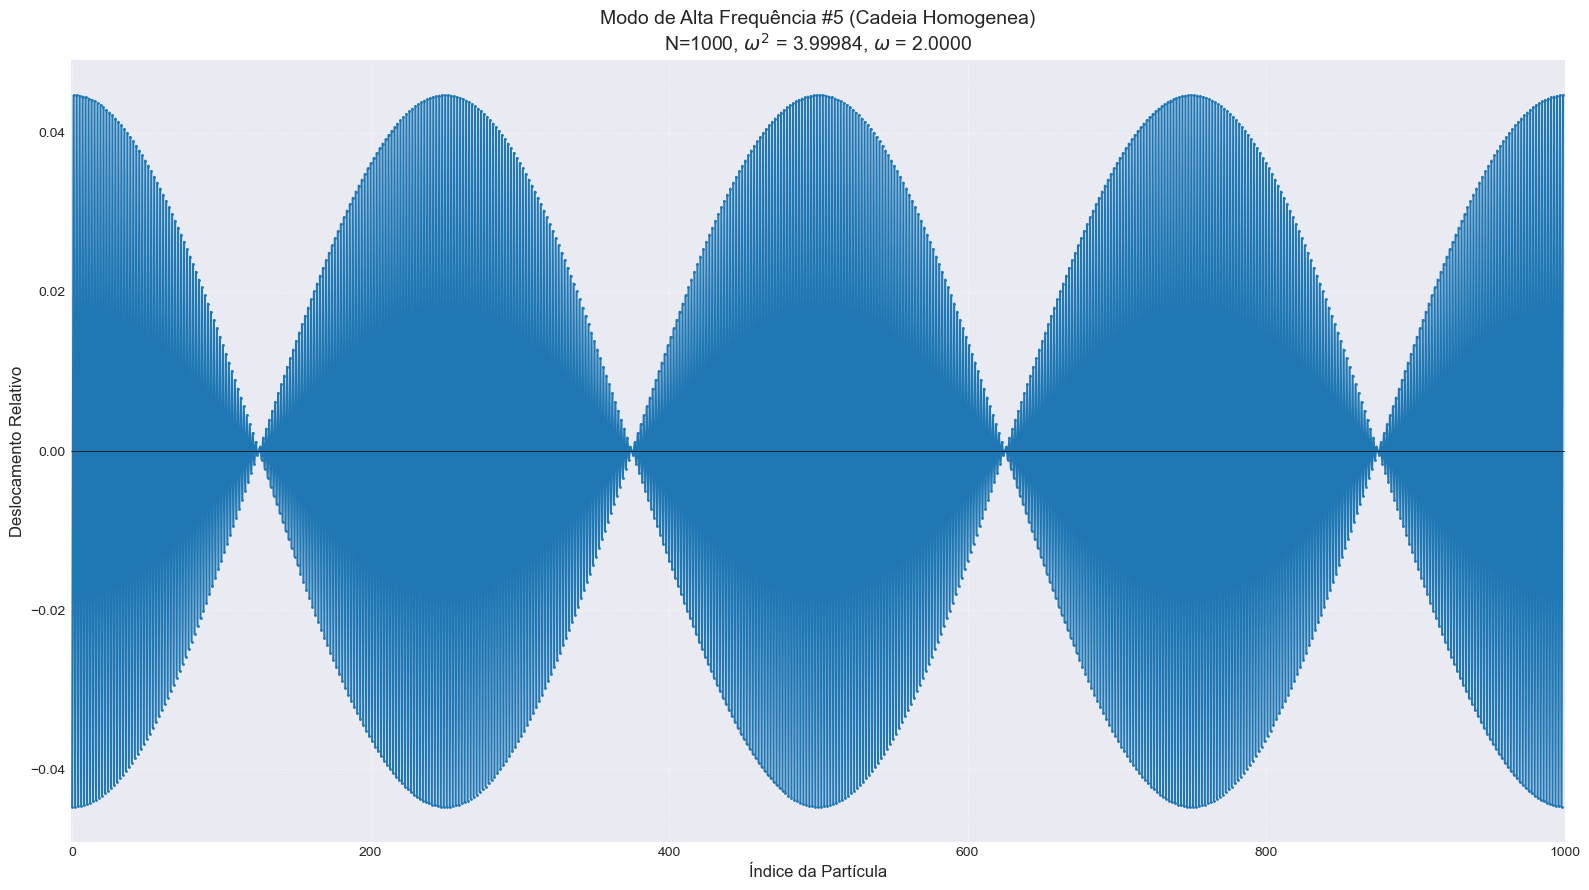

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                            Pode ser um único float (homogênea)
                                            ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- NOVA FUNÇÃO: Para plotar os deslocamentos ---
def plot_normal_mode(mode_vector, omega_squared, mode_rank, N, chain_type, mode_type):
    """
    Plota o deslocamento relativo dos átomos para um modo normal específico.

    Args:
        mode_vector (np.array): O autovetor (modo normal) a ser plotado.
        omega_squared (float): O autovalor (frequência ao quadrado) correspondente.
        mode_rank (int): A ordem do modo (1º, 2º, etc.) para o título.
        N (int): O número de partículas.
        chain_type (str): O tipo de cadeia (ex: 'Aleatória').
        mode_type (str): O tipo de modo (ex: 'Baixa Frequência', 'Alta Frequência').
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(16, 9))
    
    # Plota os deslocamentos usando marcadores e uma linha para conectar
    plt.plot(range(N), mode_vector, '-o', markersize=1, label='Deslocamento')
    
    # Adiciona uma linha horizontal em y=0 como referência
    plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    omega = np.sqrt(omega_squared) if omega_squared > 1e-9 else 0
    title = (f'Modo de {mode_type} #{mode_rank} (Cadeia {chain_type})\n'
             f'N={N}, $\omega^2$ = {omega_squared:.5f}, $\omega$ = {omega:.4f}')
             
    plt.title(title, fontsize=14)
    plt.xlabel('Índice da Partícula', fontsize=12)
    plt.ylabel('Deslocamento Relativo', fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.xlim(-1, N) # Adiciona um pequeno espaço nas bordas do eixo x
    plt.tight_layout()
    plt.show()


# --- Parâmetros Definidos pelo Usuário ---
# N foi reduzido para uma visualização clara dos modos de deslocamento.
# Com 10.000 partículas, os padrões de onda seriam muito densos para serem vistos.
N_particles = 1000 
k_spring = 1

# --- Escolha o tipo de cadeia para analisar ---
chain_type = "Homogenea"
m_base = 1
mass_value_for_chain = np.full(N_particles, m_base)

print(f"Analisando deslocamentos para uma cadeia '{chain_type}' com N={N_particles} partículas.")
print(f"Massas (primeiras 20): {mass_value_for_chain[:20]}...\n")
# -----------------------------------------------------------

# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# --- MODIFICAÇÃO: Obter autovalores E autovetores ---
# A função `eig` retorna os autovalores e os autovetores correspondentes.
# Os autovetores são as colunas da matriz `autovetores`.
autovalores, autovetores = eig(B_matrix)

frequencias_quadrado = autovalores
modos_normais = autovetores

# --- NOVO: Ordenar frequências e modos ---
# `np.argsort` retorna os índices que ordenariam o array de frequências.
sorted_indices = np.argsort(frequencias_quadrado)

# Usa os índices ordenados para reorganizar tanto as frequências quanto os modos normais.
# Isso garante que cada frequência ainda corresponda ao seu modo correto.
sorted_frequencias_quadrado = frequencias_quadrado[sorted_indices]
# As colunas dos autovetores são reordenadas para corresponder às frequências ordenadas.
sorted_modos_normais = modos_normais[:, sorted_indices]

# --- Apresentação dos Gráficos de Deslocamento ---

# 1. Plota os 5 modos de MENOR frequência
print("--- Plotando os 5 modos de menor frequência (baixa energia) ---")
for i in range(5):
    # O modo i-ésimo menor corresponde à i-ésima coluna dos vetores ordenados
    mode_vector = sorted_modos_normais[:, i]
    omega_sq = sorted_frequencias_quadrado[i]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Baixa Frequência")

# 2. Plota os 5 modos de MAIOR frequência
print("\n--- Plotando os 5 modos de maior frequência (alta energia) ---")
for i in range(5):
    # O i-ésimo modo maior está no final do array ordenado.
    # Usamos indexação negativa: -1 para o último, -2 para o penúltimo, etc.
    mode_index_from_end = - (i + 1)
    mode_vector = sorted_modos_normais[:, mode_index_from_end]
    omega_sq = sorted_frequencias_quadrado[mode_index_from_end]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Alta Frequência")

<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\1513658421.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.5f}, $\omega$ = {omega:.4f}')
C:\Users\luiz.daniel\AppData\Local\Temp\ipykernel_6728\1513658421.py:66: SyntaxWarning: invalid escape sequence '\o'
  f'N={N}, $\omega^2$ = {omega_squared:.5f}, $\omega$ = {omega:.4f}')


Analisando deslocamentos para uma cadeia 'Homogenea' com N=10000 partículas.
Massas (primeiras 20): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]...

--- Plotando os 5 modos de menor frequência (baixa energia) ---


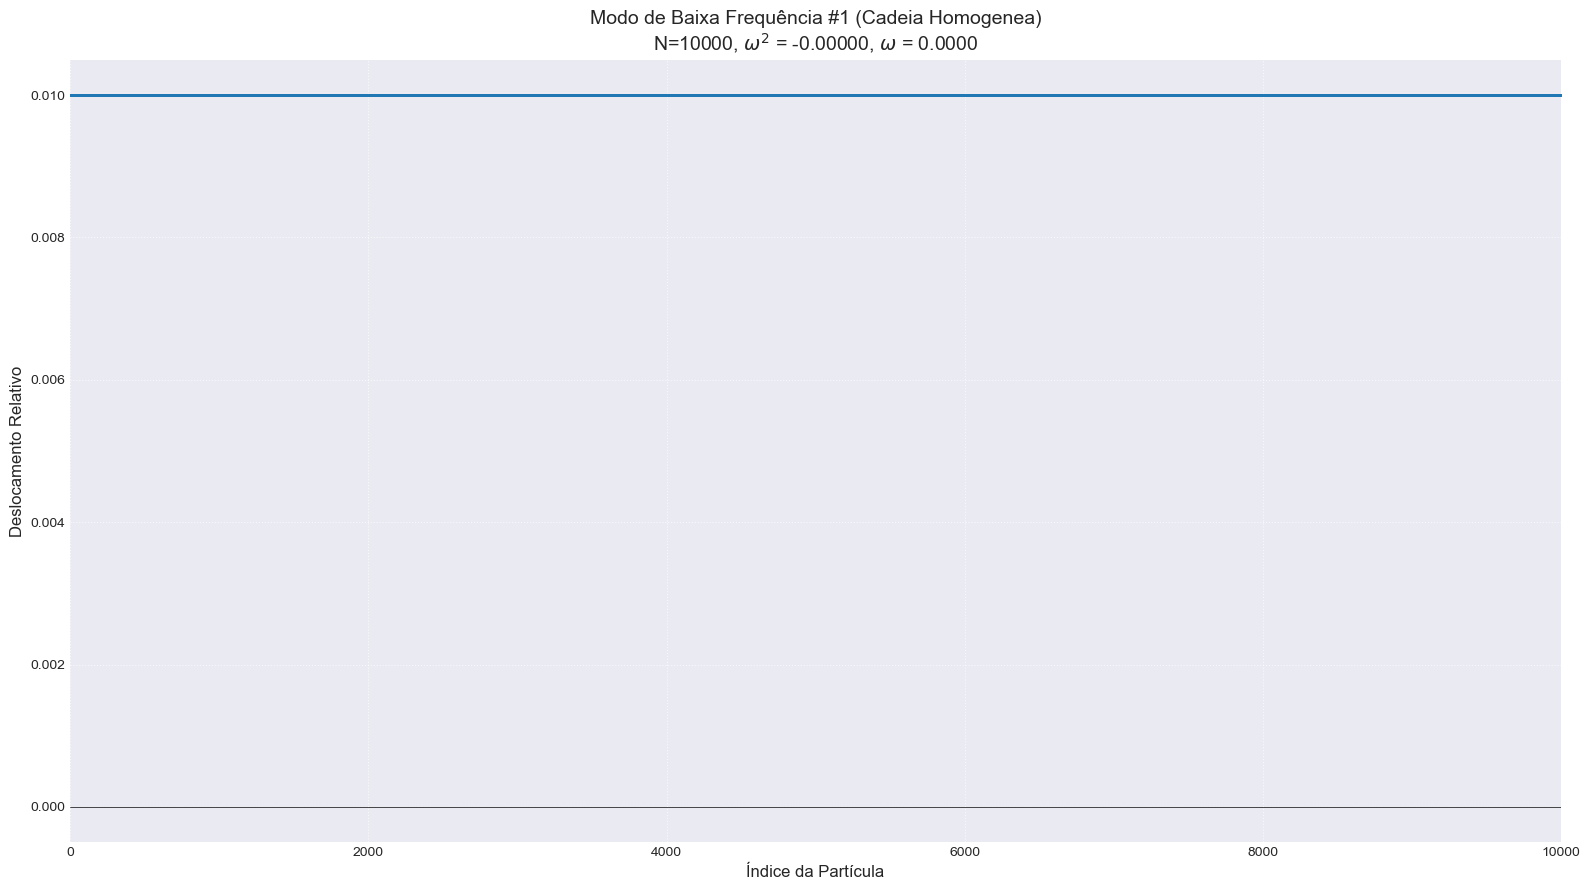

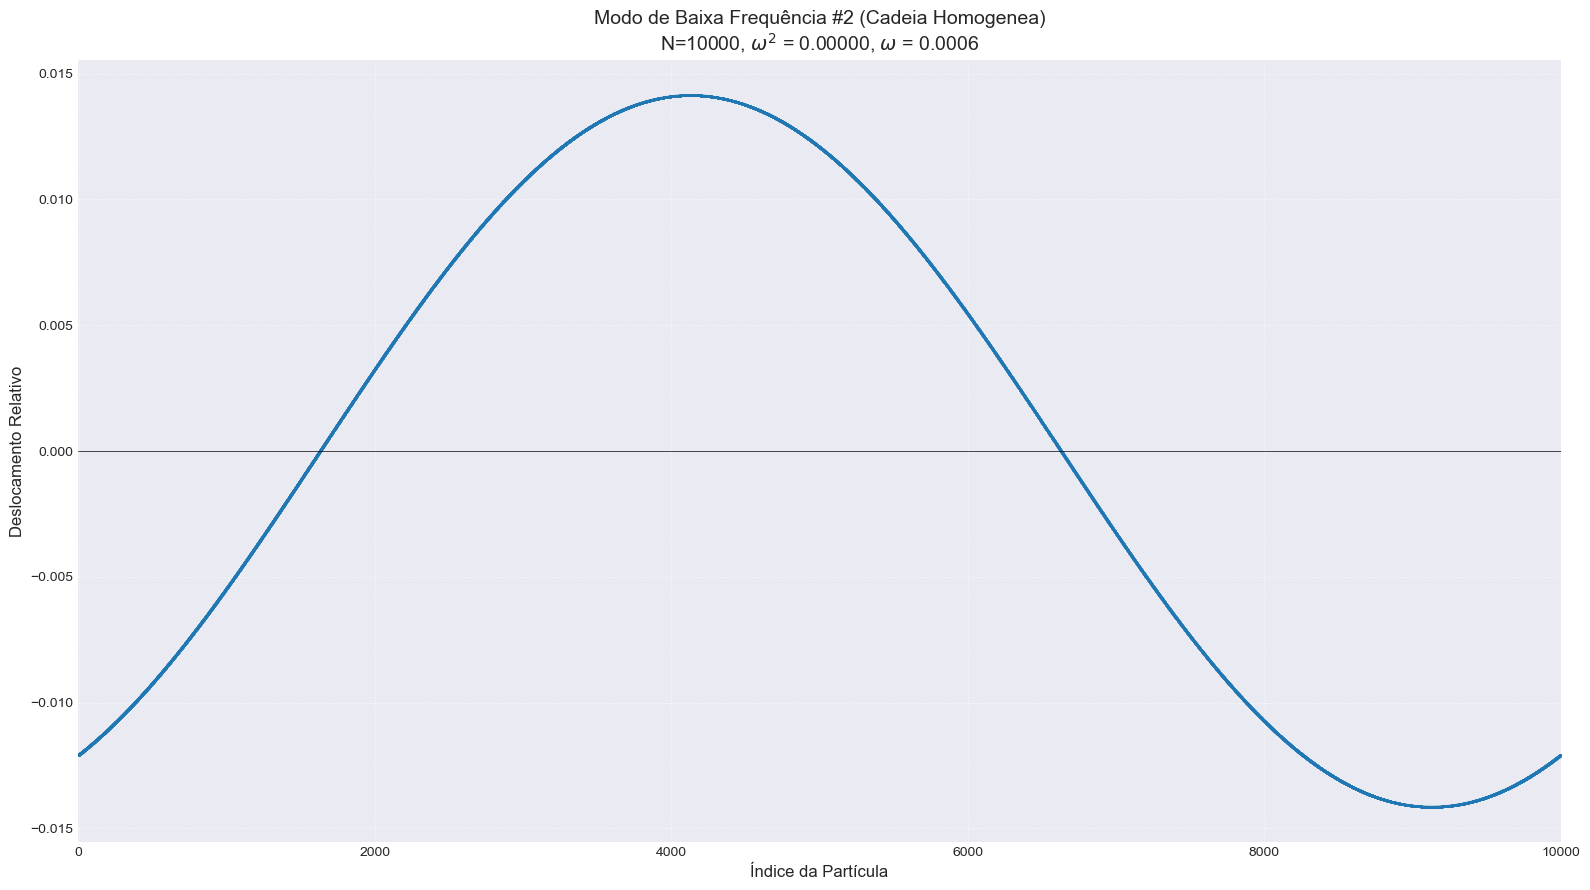

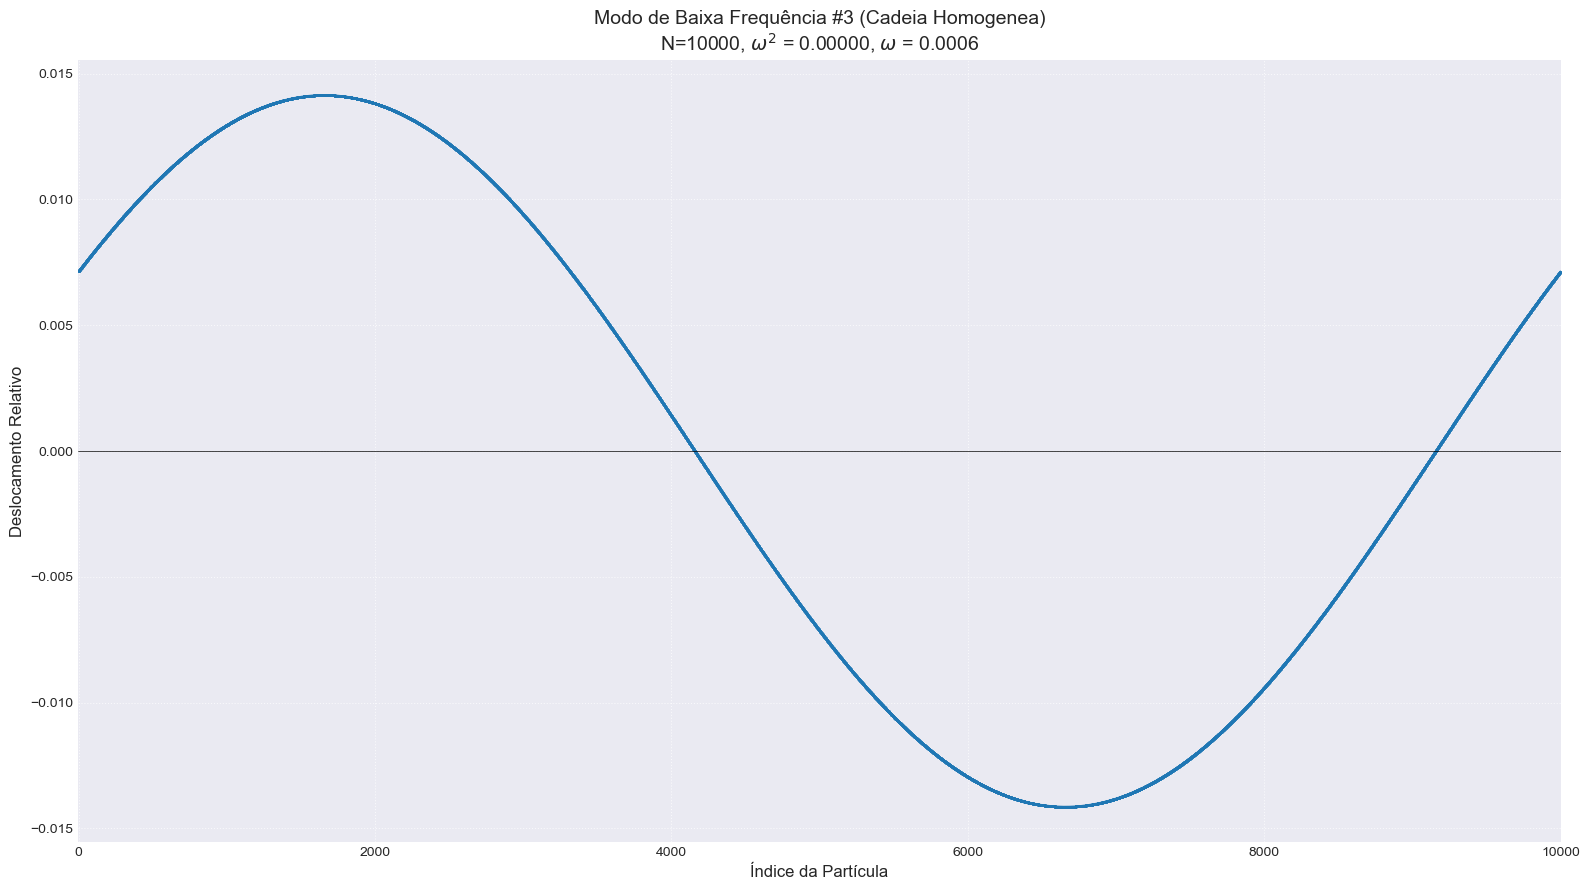

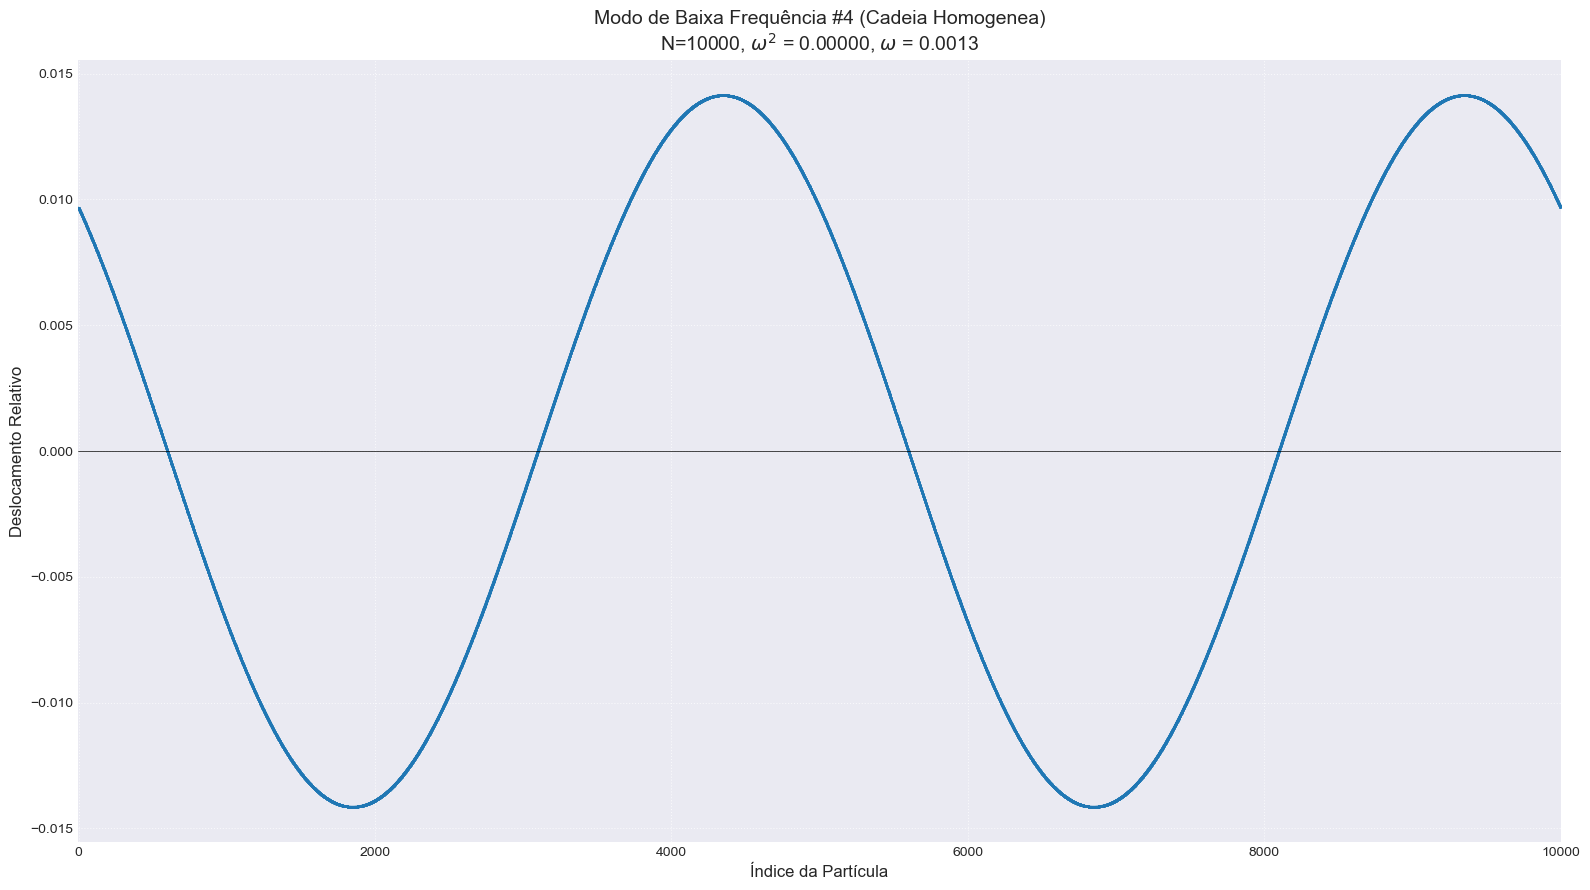

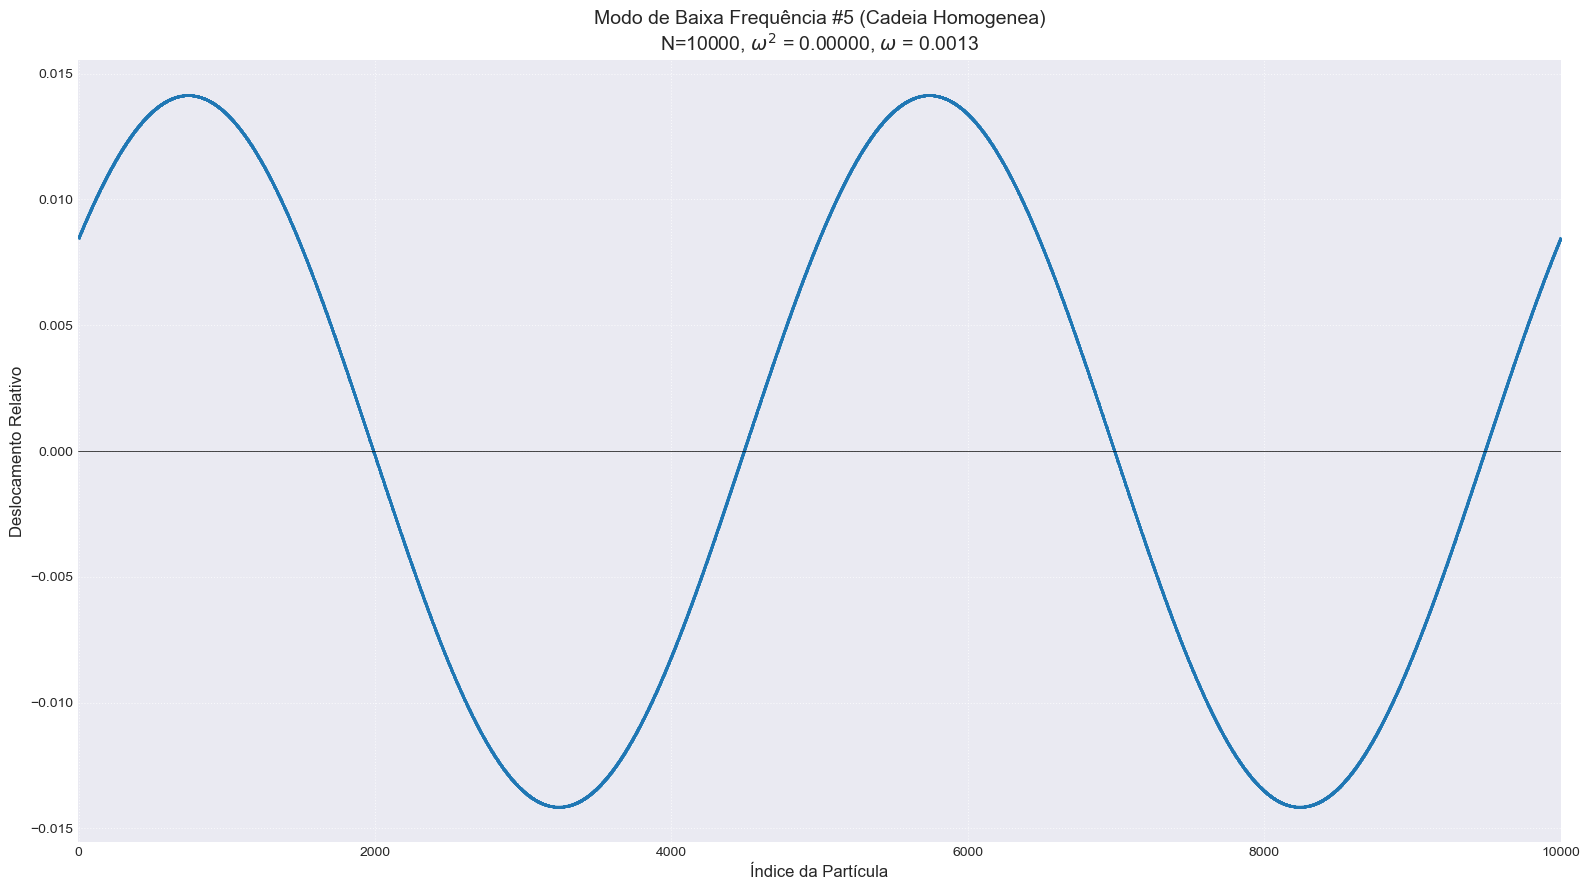


--- Plotando os 5 modos de maior frequência (alta energia) ---


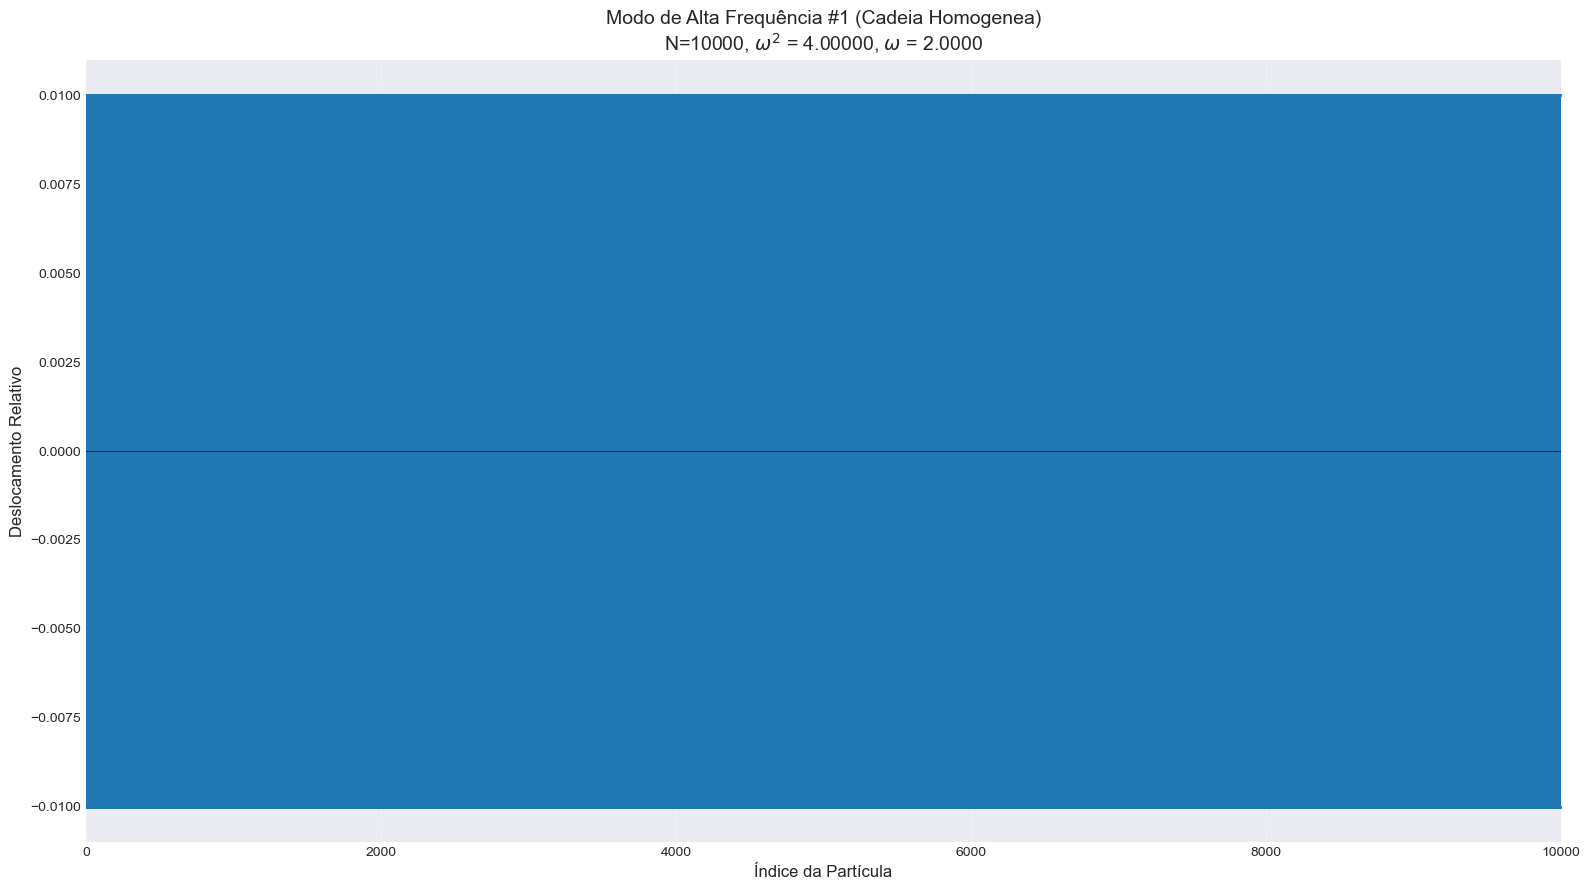

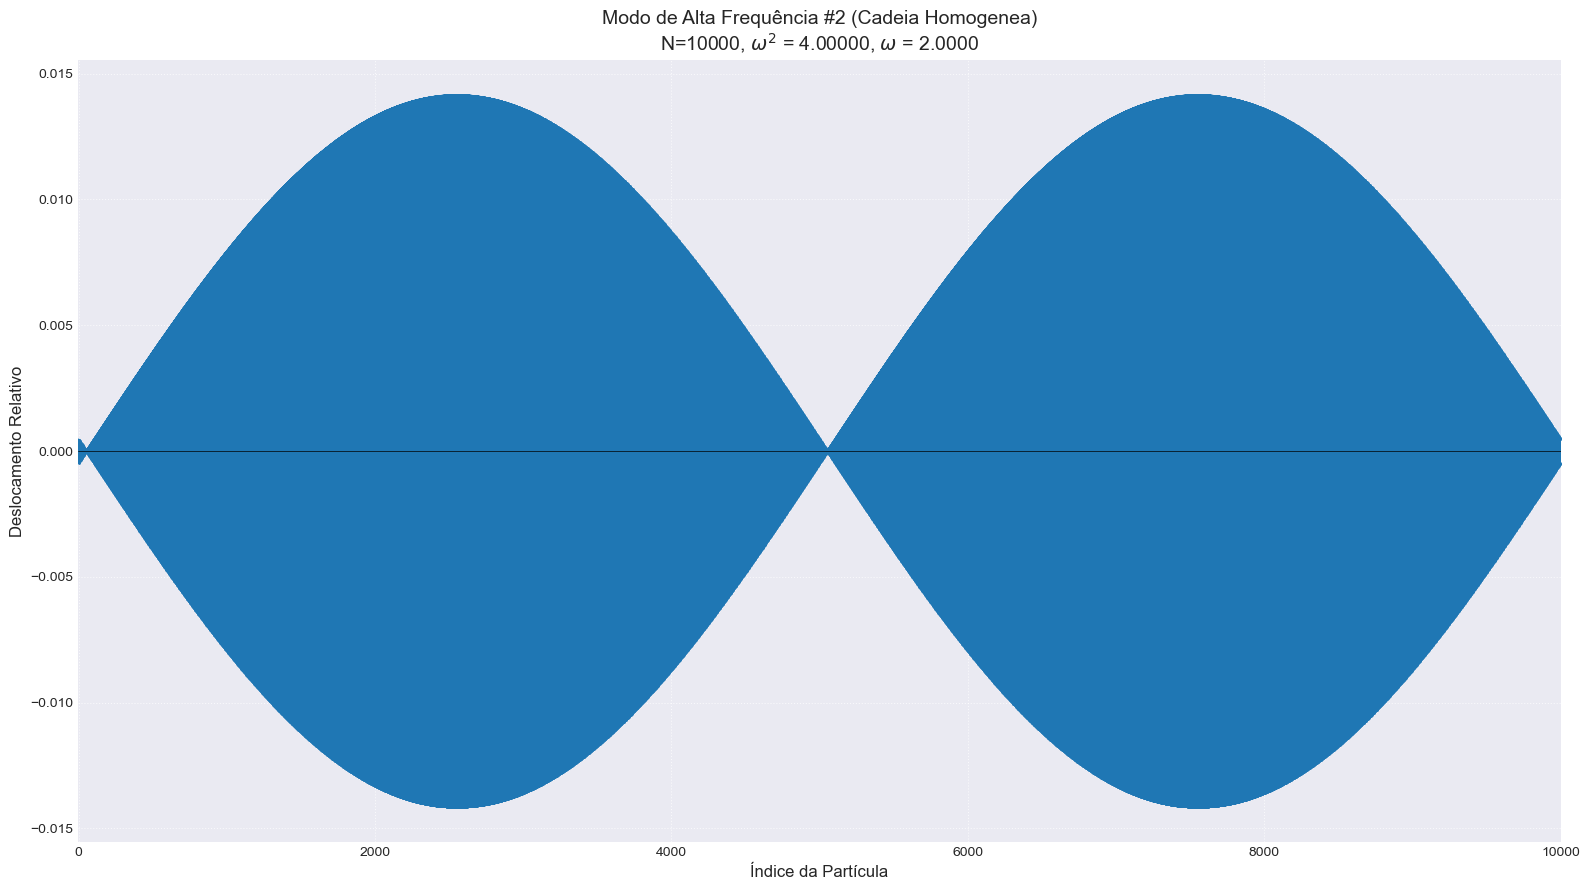

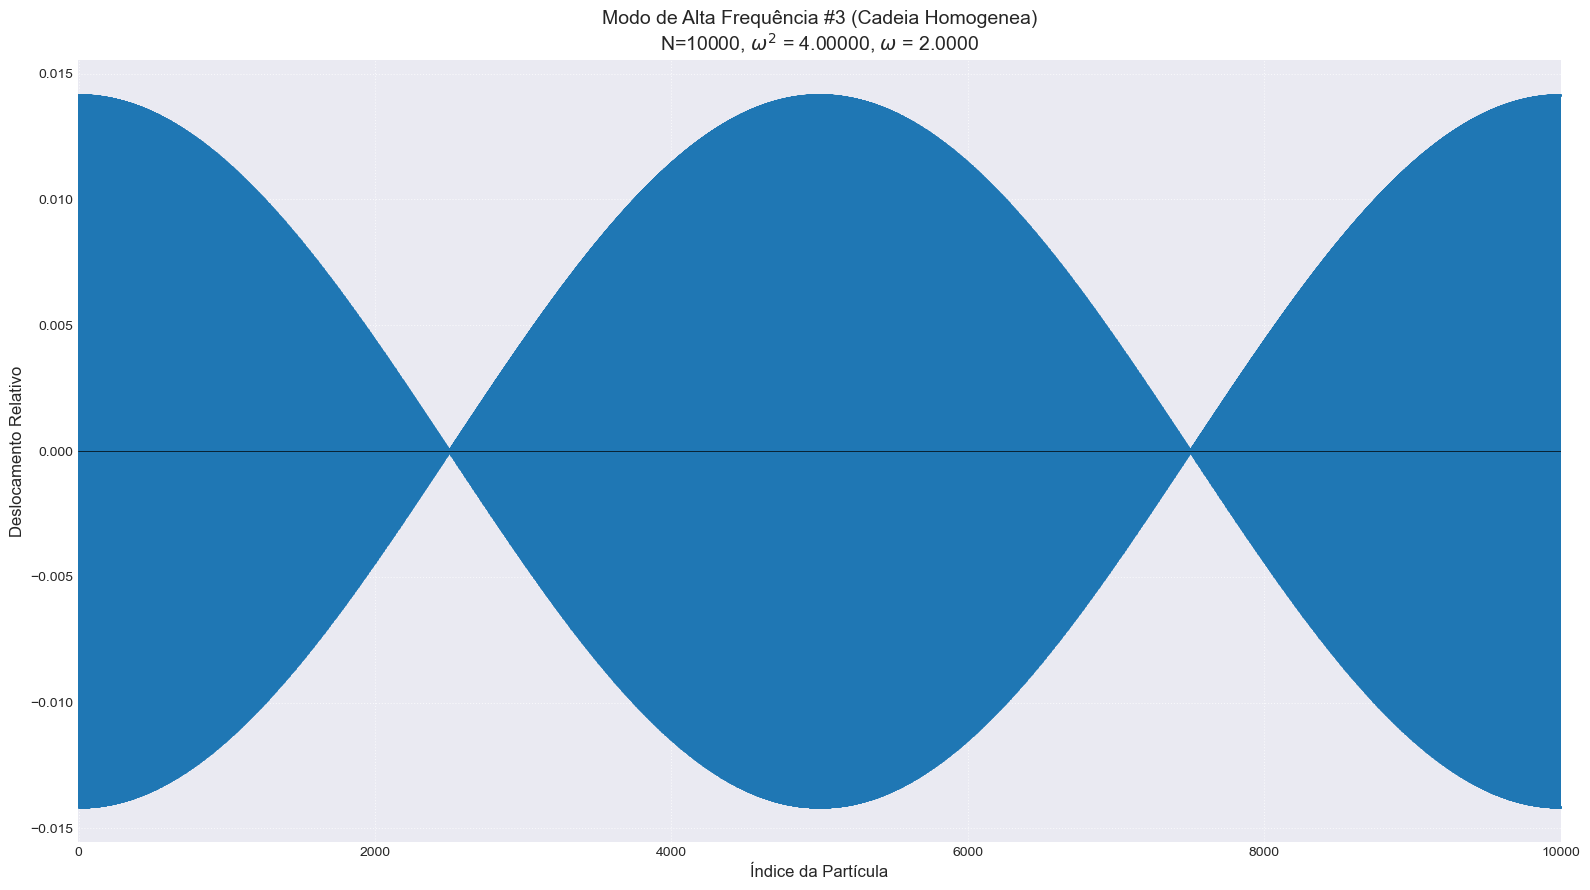

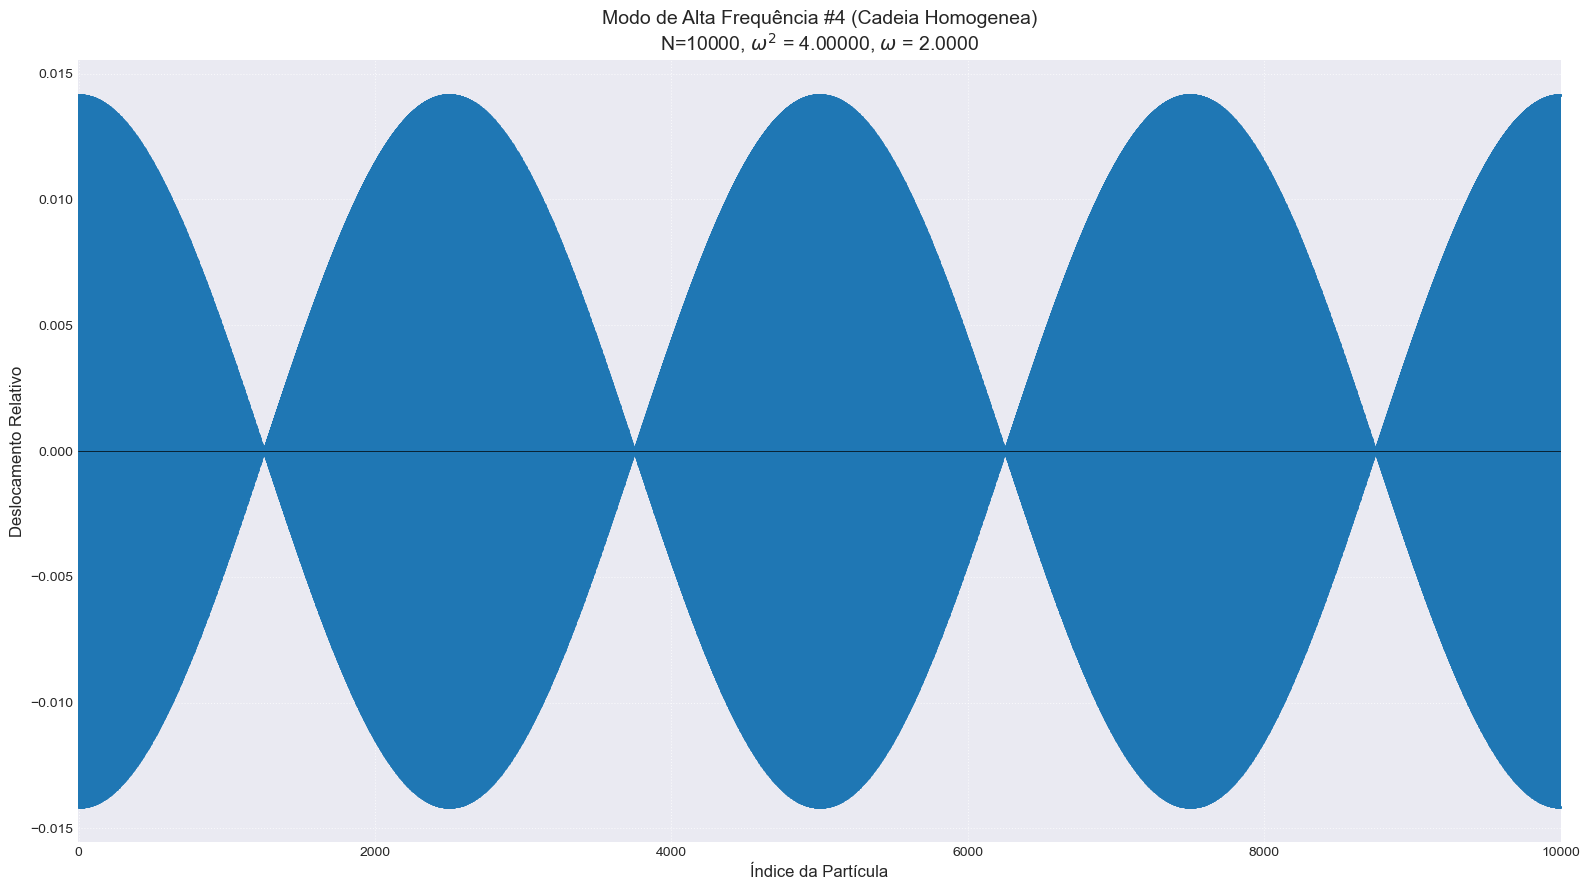

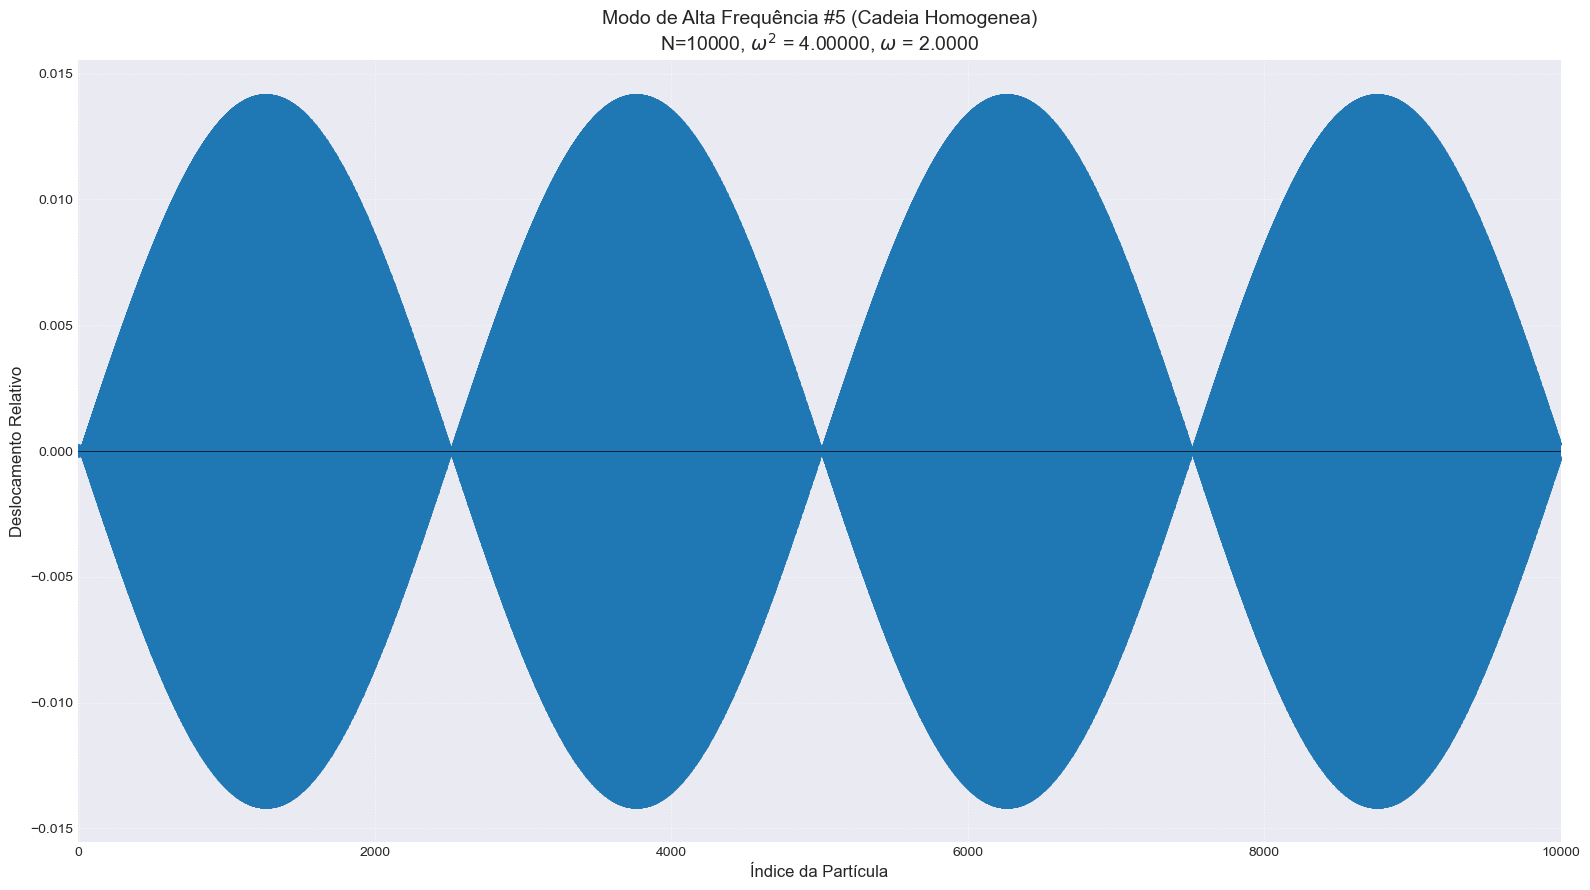

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

def create_dynamic_matrix_circular(N, m_values, k_val):
    """
    Cria a matriz dinâmica para N partículas em uma CADEIA CIRCULAR.

    Args:
        N (int): O número de partículas.
        m_values (float ou list/np.array): A massa de cada partícula.
                                            Pode ser um único float (homogênea)
                                            ou um array/lista de N floats (aleatória).
        k_val (float): A constante elástica da mola (assumida como uniforme para todas as molas).

    Returns:
        np.array: A matriz dinâmica N x N.
    """
    if N <= 0:
        raise ValueError("O número de partículas (N) deve ser um inteiro positivo.")

    if isinstance(m_values, (int, float)):
        masses = np.full(N, m_values)
    else:
        masses = np.array(m_values)
        if len(masses) != N:
            raise ValueError(f"O comprimento de m_values ({len(masses)}) deve ser igual a N_particles ({N}).")

    matrix = np.zeros((N, N))

    for i in range(N):
        current_mass = masses[i]
        matrix[i, i] = (2 * k_val) / current_mass

        next_particle_index = (i + 1) % N
        matrix[i, next_particle_index] = -k_val / current_mass

        prev_particle_index = (i - 1 + N) % N
        matrix[i, prev_particle_index] = -k_val / current_mass
    return matrix

# --- NOVA FUNÇÃO: Para plotar os deslocamentos ---
def plot_normal_mode(mode_vector, omega_squared, mode_rank, N, chain_type, mode_type):
    """
    Plota o deslocamento relativo dos átomos para um modo normal específico.

    Args:
        mode_vector (np.array): O autovetor (modo normal) a ser plotado.
        omega_squared (float): O autovalor (frequência ao quadrado) correspondente.
        mode_rank (int): A ordem do modo (1º, 2º, etc.) para o título.
        N (int): O número de partículas.
        chain_type (str): O tipo de cadeia (ex: 'Aleatória').
        mode_type (str): O tipo de modo (ex: 'Baixa Frequência', 'Alta Frequência').
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(16, 9))
    
    # Plota os deslocamentos usando marcadores e uma linha para conectar
    plt.plot(range(N), mode_vector, '-o', markersize=1, label='Deslocamento')
    
    # Adiciona uma linha horizontal em y=0 como referência
    plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    omega = np.sqrt(omega_squared) if omega_squared > 1e-9 else 0
    title = (f'Modo de {mode_type} #{mode_rank} (Cadeia {chain_type})\n'
             f'N={N}, $\omega^2$ = {omega_squared:.5f}, $\omega$ = {omega:.4f}')
             
    plt.title(title, fontsize=14)
    plt.xlabel('Índice da Partícula', fontsize=12)
    plt.ylabel('Deslocamento Relativo', fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.xlim(-1, N) # Adiciona um pequeno espaço nas bordas do eixo x
    plt.tight_layout()
    plt.show()


# --- Parâmetros Definidos pelo Usuário ---
# N foi reduzido para uma visualização clara dos modos de deslocamento.
# Com 10.000 partículas, os padrões de onda seriam muito densos para serem vistos.
N_particles = 10000 
k_spring = 1

# --- Escolha o tipo de cadeia para analisar ---
chain_type = "Homogenea"
m_base = 1
mass_value_for_chain = np.full(N_particles, m_base)

print(f"Analisando deslocamentos para uma cadeia '{chain_type}' com N={N_particles} partículas.")
print(f"Massas (primeiras 20): {mass_value_for_chain[:20]}...\n")
# -----------------------------------------------------------

# Cria a matriz dinâmica com base na escolha
B_matrix = create_dynamic_matrix_circular(N_particles, mass_value_for_chain, k_spring)

# --- MODIFICAÇÃO: Obter autovalores E autovetores ---
# A função `eig` retorna os autovalores e os autovetores correspondentes.
# Os autovetores são as colunas da matriz `autovetores`.
autovalores, autovetores = eig(B_matrix)

frequencias_quadrado = autovalores
modos_normais = autovetores

# --- NOVO: Ordenar frequências e modos ---
# `np.argsort` retorna os índices que ordenariam o array de frequências.
sorted_indices = np.argsort(frequencias_quadrado)

# Usa os índices ordenados para reorganizar tanto as frequências quanto os modos normais.
# Isso garante que cada frequência ainda corresponda ao seu modo correto.
sorted_frequencias_quadrado = frequencias_quadrado[sorted_indices]
# As colunas dos autovetores são reordenadas para corresponder às frequências ordenadas.
sorted_modos_normais = modos_normais[:, sorted_indices]

# --- Apresentação dos Gráficos de Deslocamento ---

# 1. Plota os 5 modos de MENOR frequência
print("--- Plotando os 5 modos de menor frequência (baixa energia) ---")
for i in range(5):
    # O modo i-ésimo menor corresponde à i-ésima coluna dos vetores ordenados
    mode_vector = sorted_modos_normais[:, i]
    omega_sq = sorted_frequencias_quadrado[i]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Baixa Frequência")

# 2. Plota os 5 modos de MAIOR frequência
print("\n--- Plotando os 5 modos de maior frequência (alta energia) ---")
for i in range(5):
    # O i-ésimo modo maior está no final do array ordenado.
    # Usamos indexação negativa: -1 para o último, -2 para o penúltimo, etc.
    mode_index_from_end = - (i + 1)
    mode_vector = sorted_modos_normais[:, mode_index_from_end]
    omega_sq = sorted_frequencias_quadrado[mode_index_from_end]
    plot_normal_mode(mode_vector, omega_sq, i + 1, N_particles, chain_type, "Alta Frequência")

Aqui é para observar o comportamento ondulatório da cadeia homogenea.

# Conclusão

Tendo em vista os resultados apresentados no pode-se compreender que a aleatorização das massas impõe uma antisimetria nos resultados, tais antisimetrias criam situações de altas frequências (porém menores que o modo homogeneo), ainda assim, observa-se que boa parte das partículas ficam parada e no entorno de uma das partículas há uma perturbação de grande salto. Logo, entende-se na dinâmica assimétrica das maiores frequências que o comportamento dos átomos será localizado, enão a cadeia não se comporta bem como uma "onda", mas como uma sequência de corpos isolados. Em baixas energias o comportamento da cadeia é de onda semelhante a uma cadeia homogenea, o que é esperado, pois o sistema homogeneo deve admitir energias mais baixas.